In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
plt.rcParams["font.size"] = 12

Loading subfiles:   0%|          | 0/192 [00:00<?, ?subfiles/s]

Loading subfiles:  99%|█████████▉| 190/192 [00:03<00:00, 52.34subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__3/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
shape: (1, 91)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─

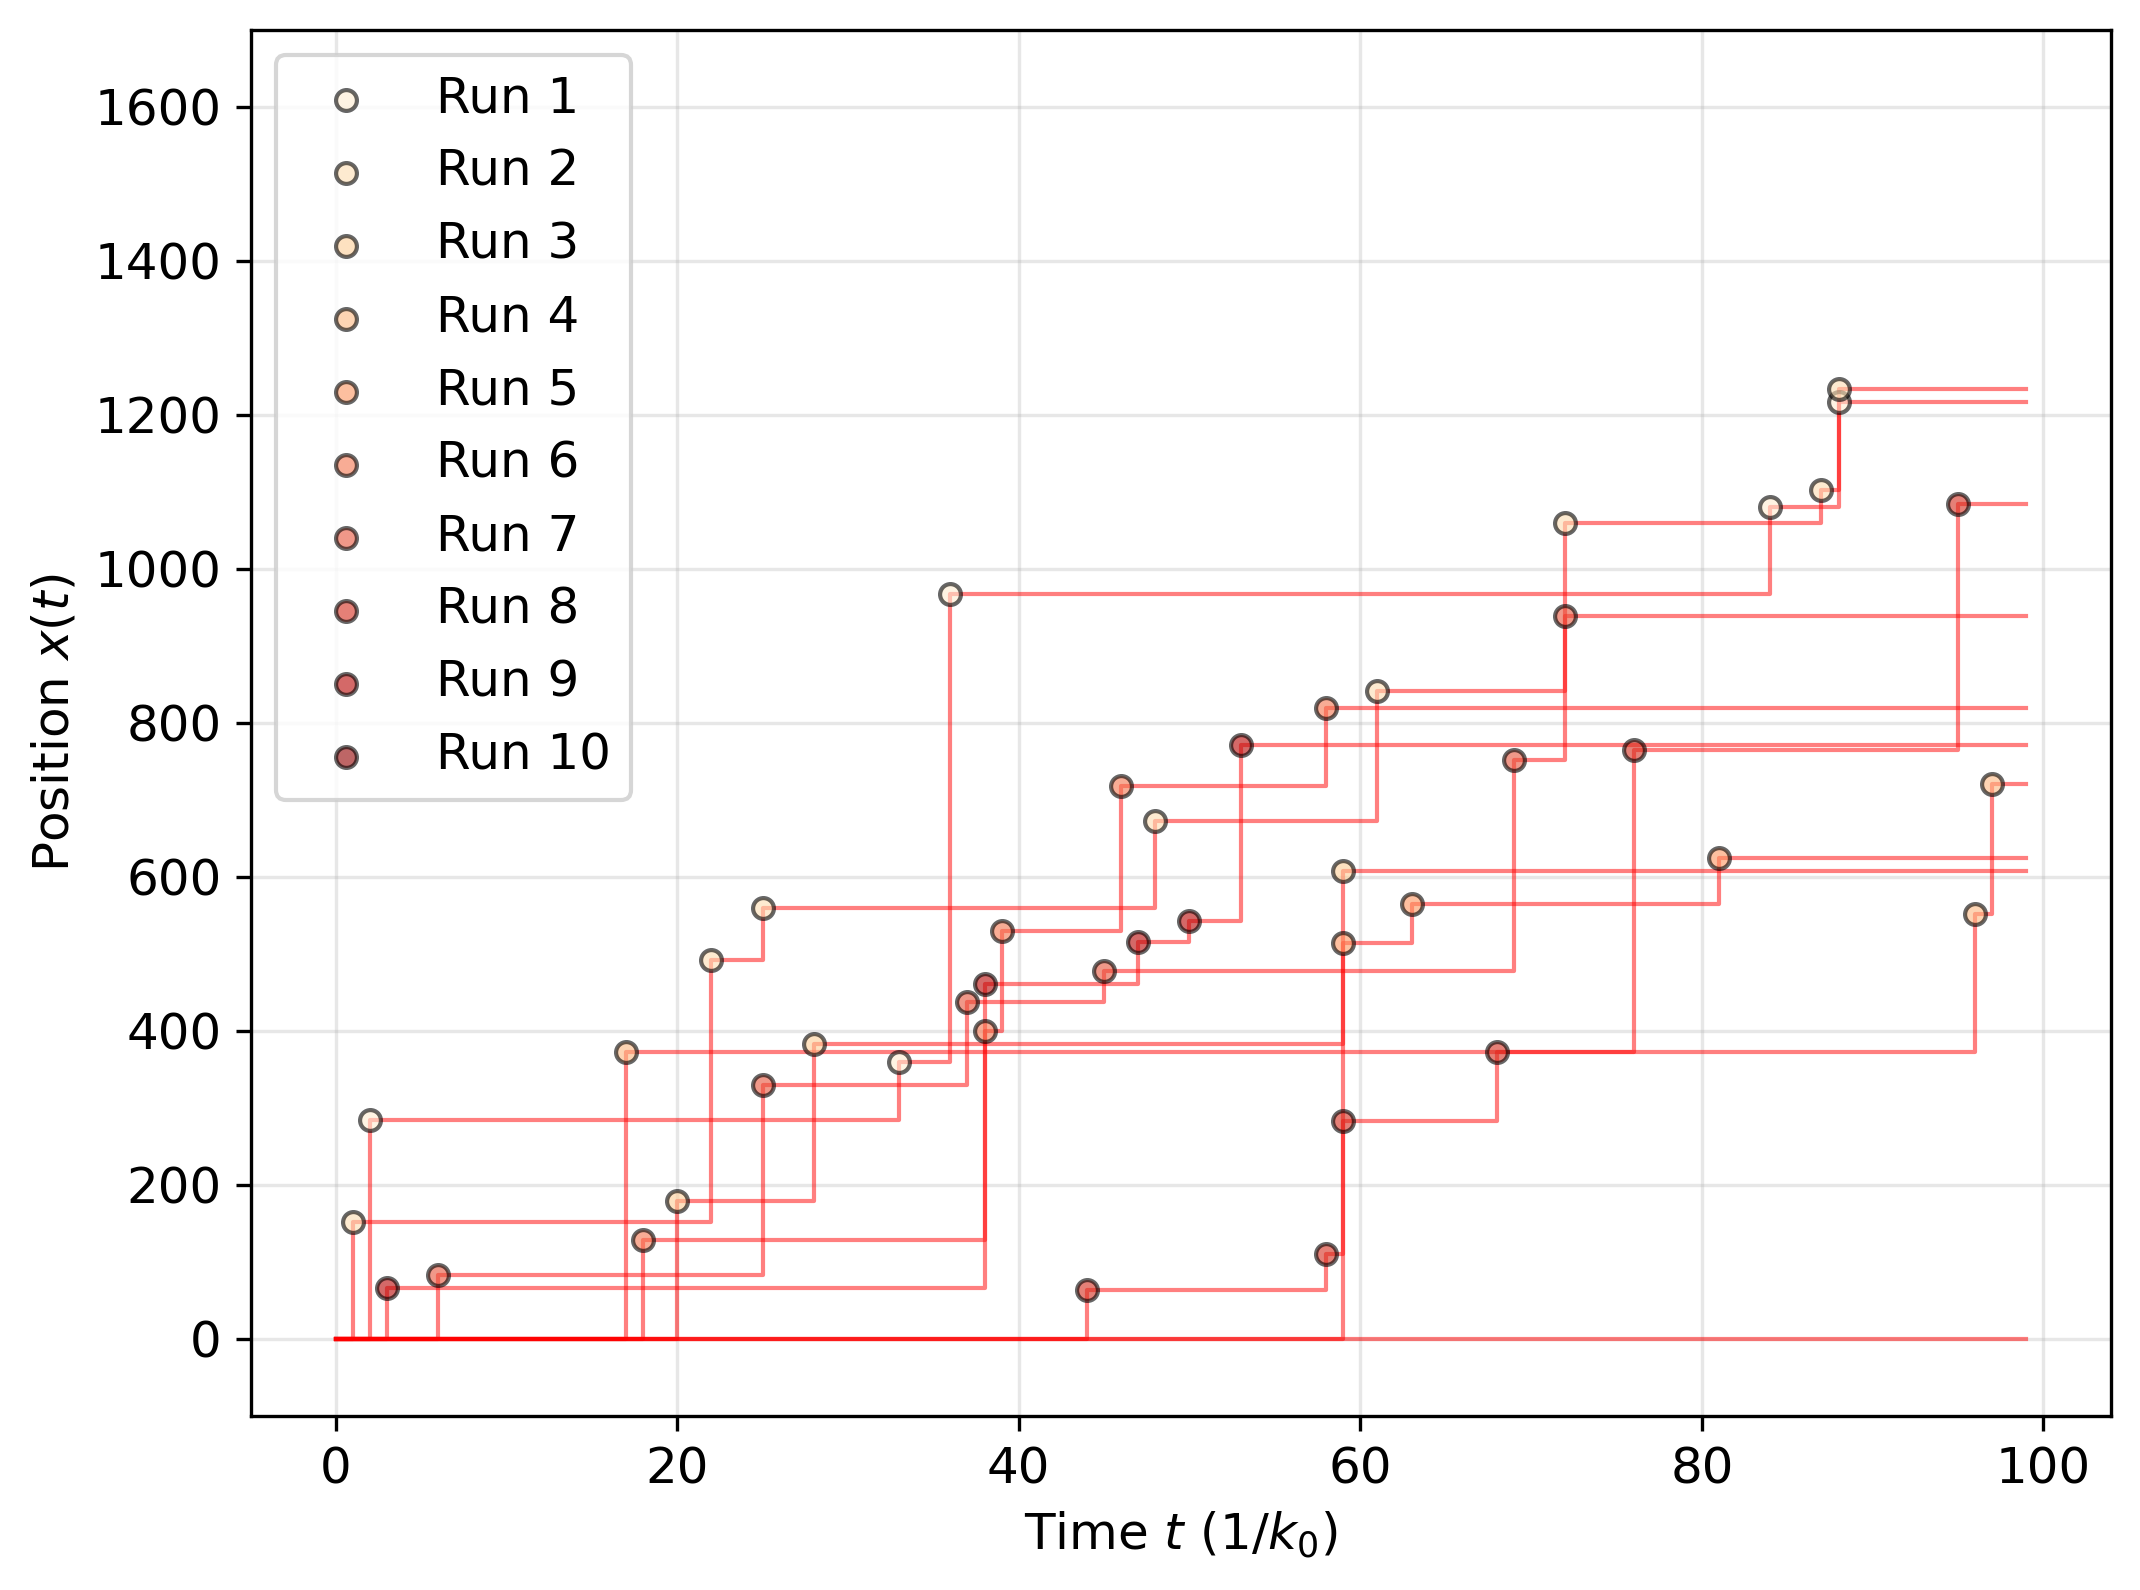

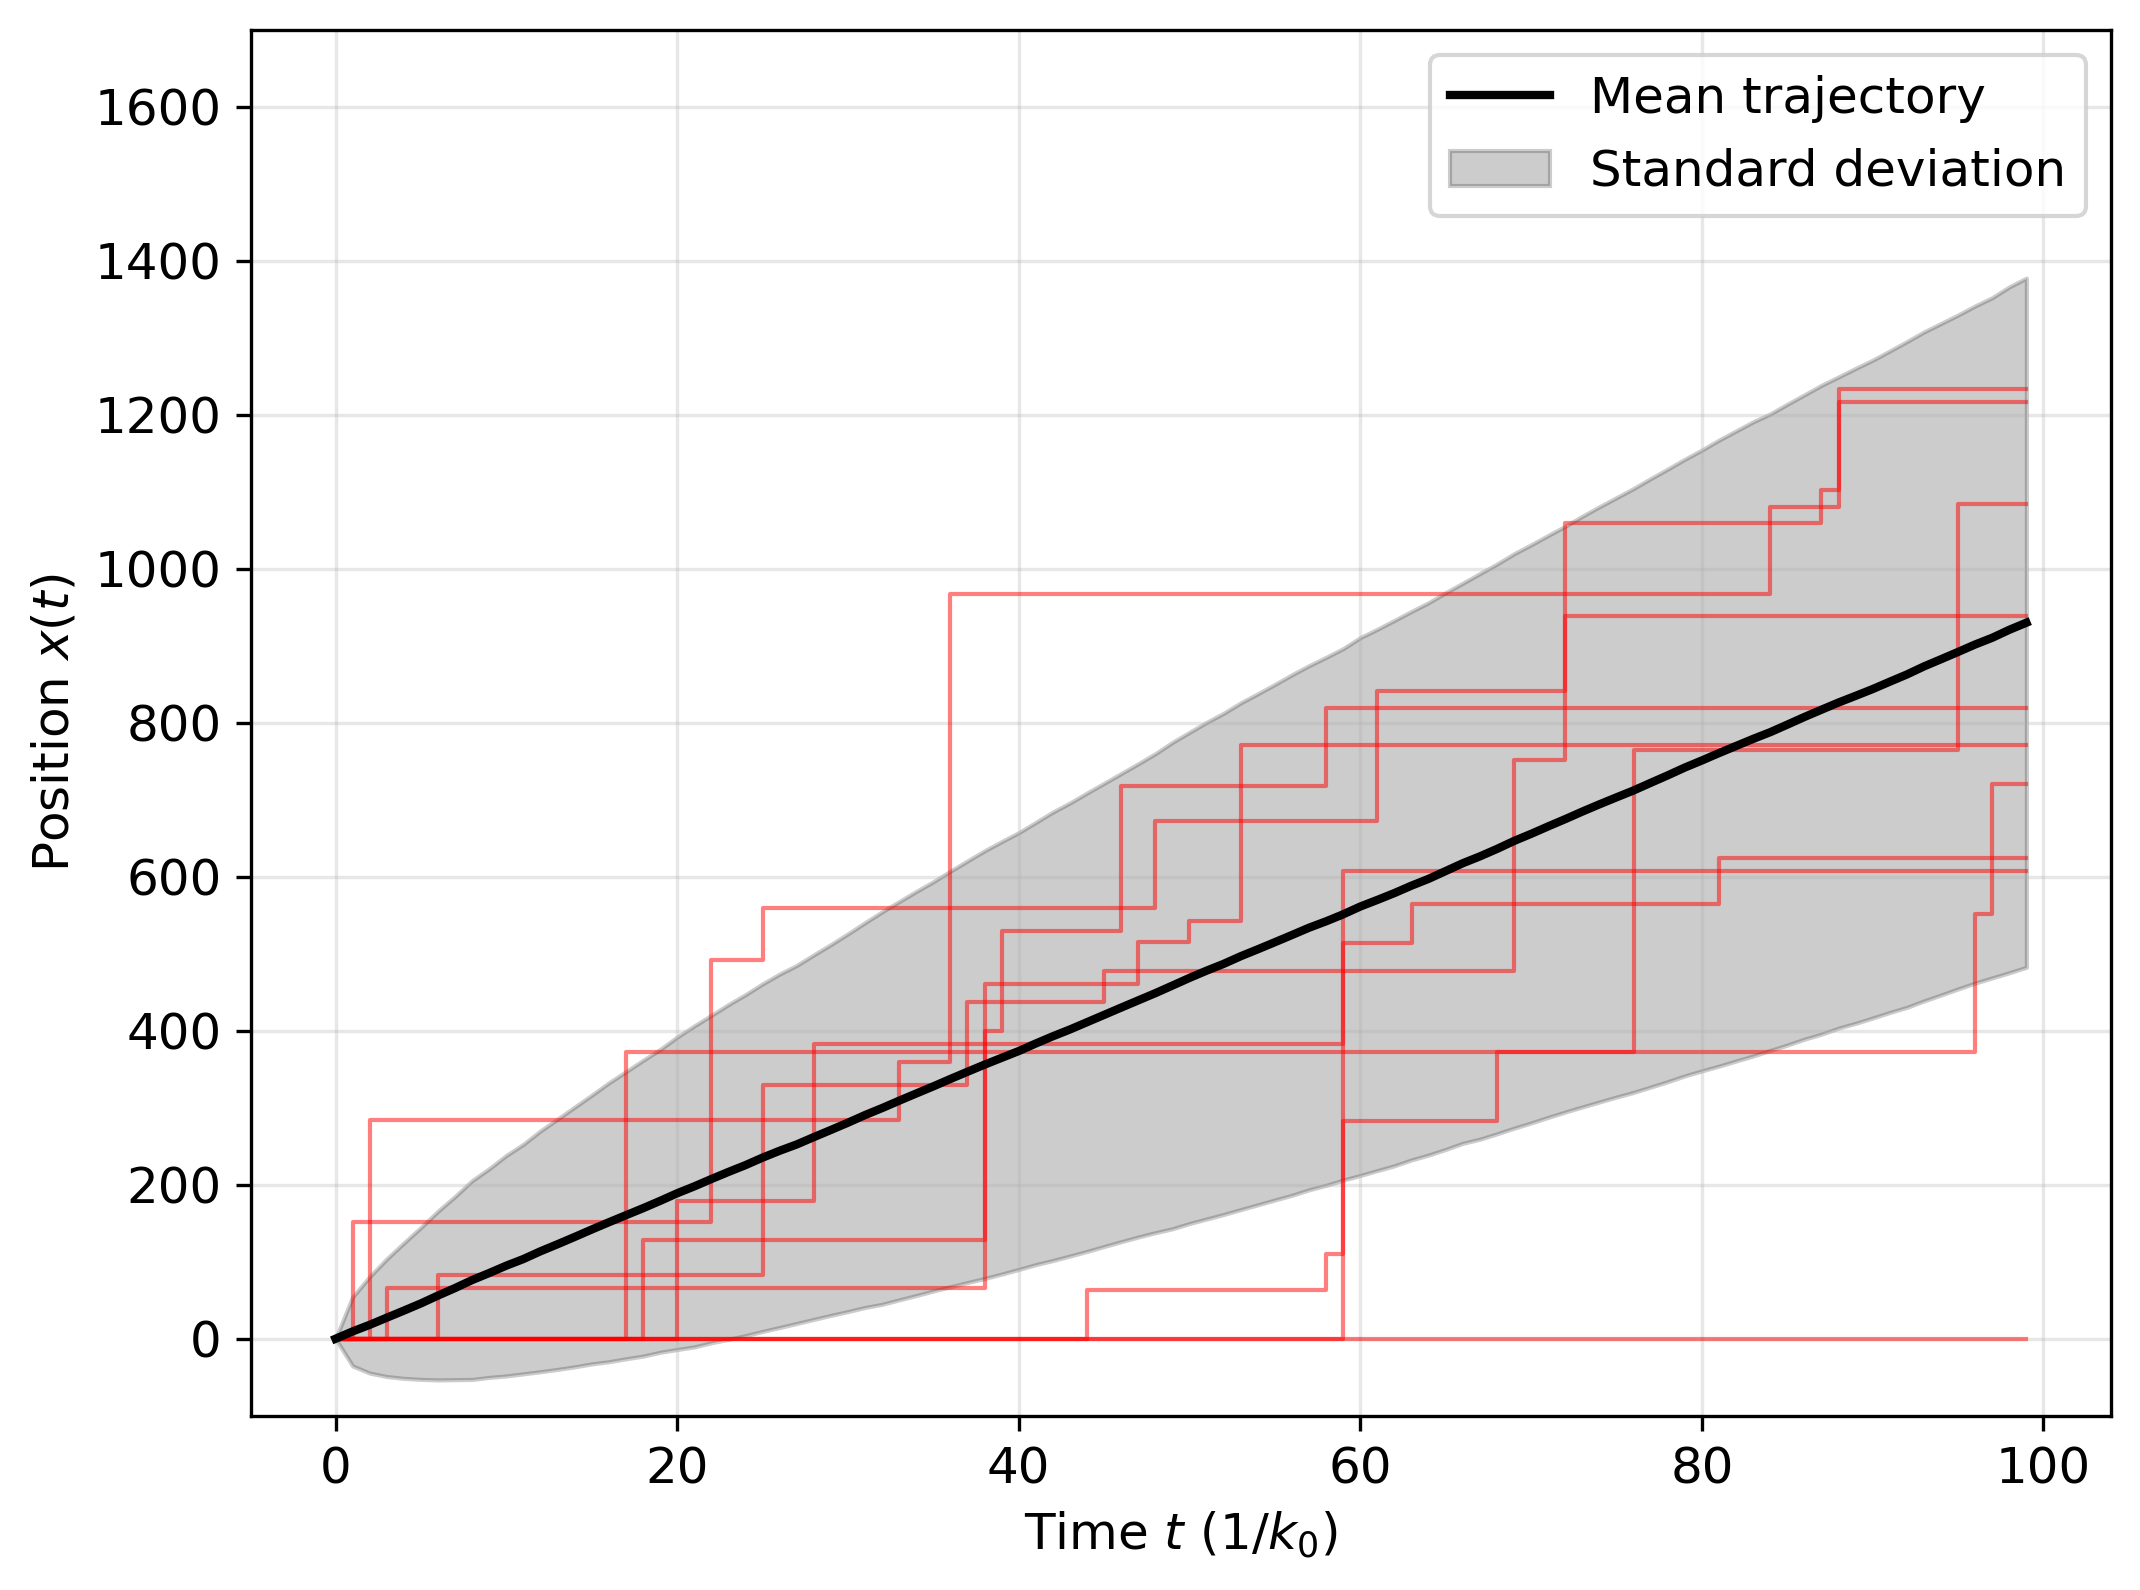

In [2]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",

    "land": "homogen",
    "s": 150,
    "l": 10,
    "bpmin": 0,

    "mu": 150,
    "theta": 100,

    "nt": 10_000,
}

df = find_parquet_and_load(**params)
print(df)


results = df["results"][0].to_numpy()
times = df["times"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
results_std = df["results_std"][0].to_numpy()

colors = plt.cm.OrRd(np.linspace(0.10, 0.95, 10))

plt.figure(figsize=(8, 6), dpi=300)

for i, color in enumerate(colors):

    trajectory = results[i]

    # # Trajectoire en escalier
    # plt.step(
    #     times,
    #     trajectory,
    #     where="post",
    #     color=color,
    #     alpha=0.6,
    #     linewidth=2,
    #     label=f"Run {i+1}"
    # )

    plt.step(
        times,
        trajectory,
        where="post",
        color="red",
        alpha=0.5,
        linewidth=1,
        # label=f"Run {i+1}"
    )

    jumps = np.where(np.diff(trajectory) != 0)[0] + 1

    plt.scatter(
        times[jumps],
        trajectory[jumps],
        color=color,
        edgecolor="black",
        s=25,
        zorder=3,
        alpha=0.6,
        label=f"Run {i+1}"
    )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1700)
plt.grid(True, alpha=0.30)
plt.legend()
plt.show()


plt.figure(figsize=(8, 6), dpi=300)


for i, color in enumerate(colors):

    trajectory = results[i]

    # # Trajectoire en escalier
    # plt.step(
    #     times,
    #     trajectory,
    #     where="post",
    #     color=color,
    #     alpha=0.6,
    #     linewidth=2,
    #     label=f"Run {i+1}"
    # )

    plt.step(
        times,
        trajectory,
        where="post",
        color="red",
        alpha=0.5,
        linewidth=1,
        # label=f"Run {i+1}"
    )

plt.plot(
    times,
    results_mean,
    color="black",
    linewidth=2,
    label="Mean trajectory"
)
# plt.errorbar(
#     times,
#     results_mean,
#     yerr=results_std,
#     color="black",
#     linewidth=2,
#     capsize=3,
#     label="Mean trajectory"
# )
plt.fill_between(
    times,
    results_mean - results_std,
    results_mean + results_std,
    color="black",
    alpha=0.2,
    label="Standard deviation"
)
plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1700)
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

/tmp/ipykernel_138058/2228377018.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e4])


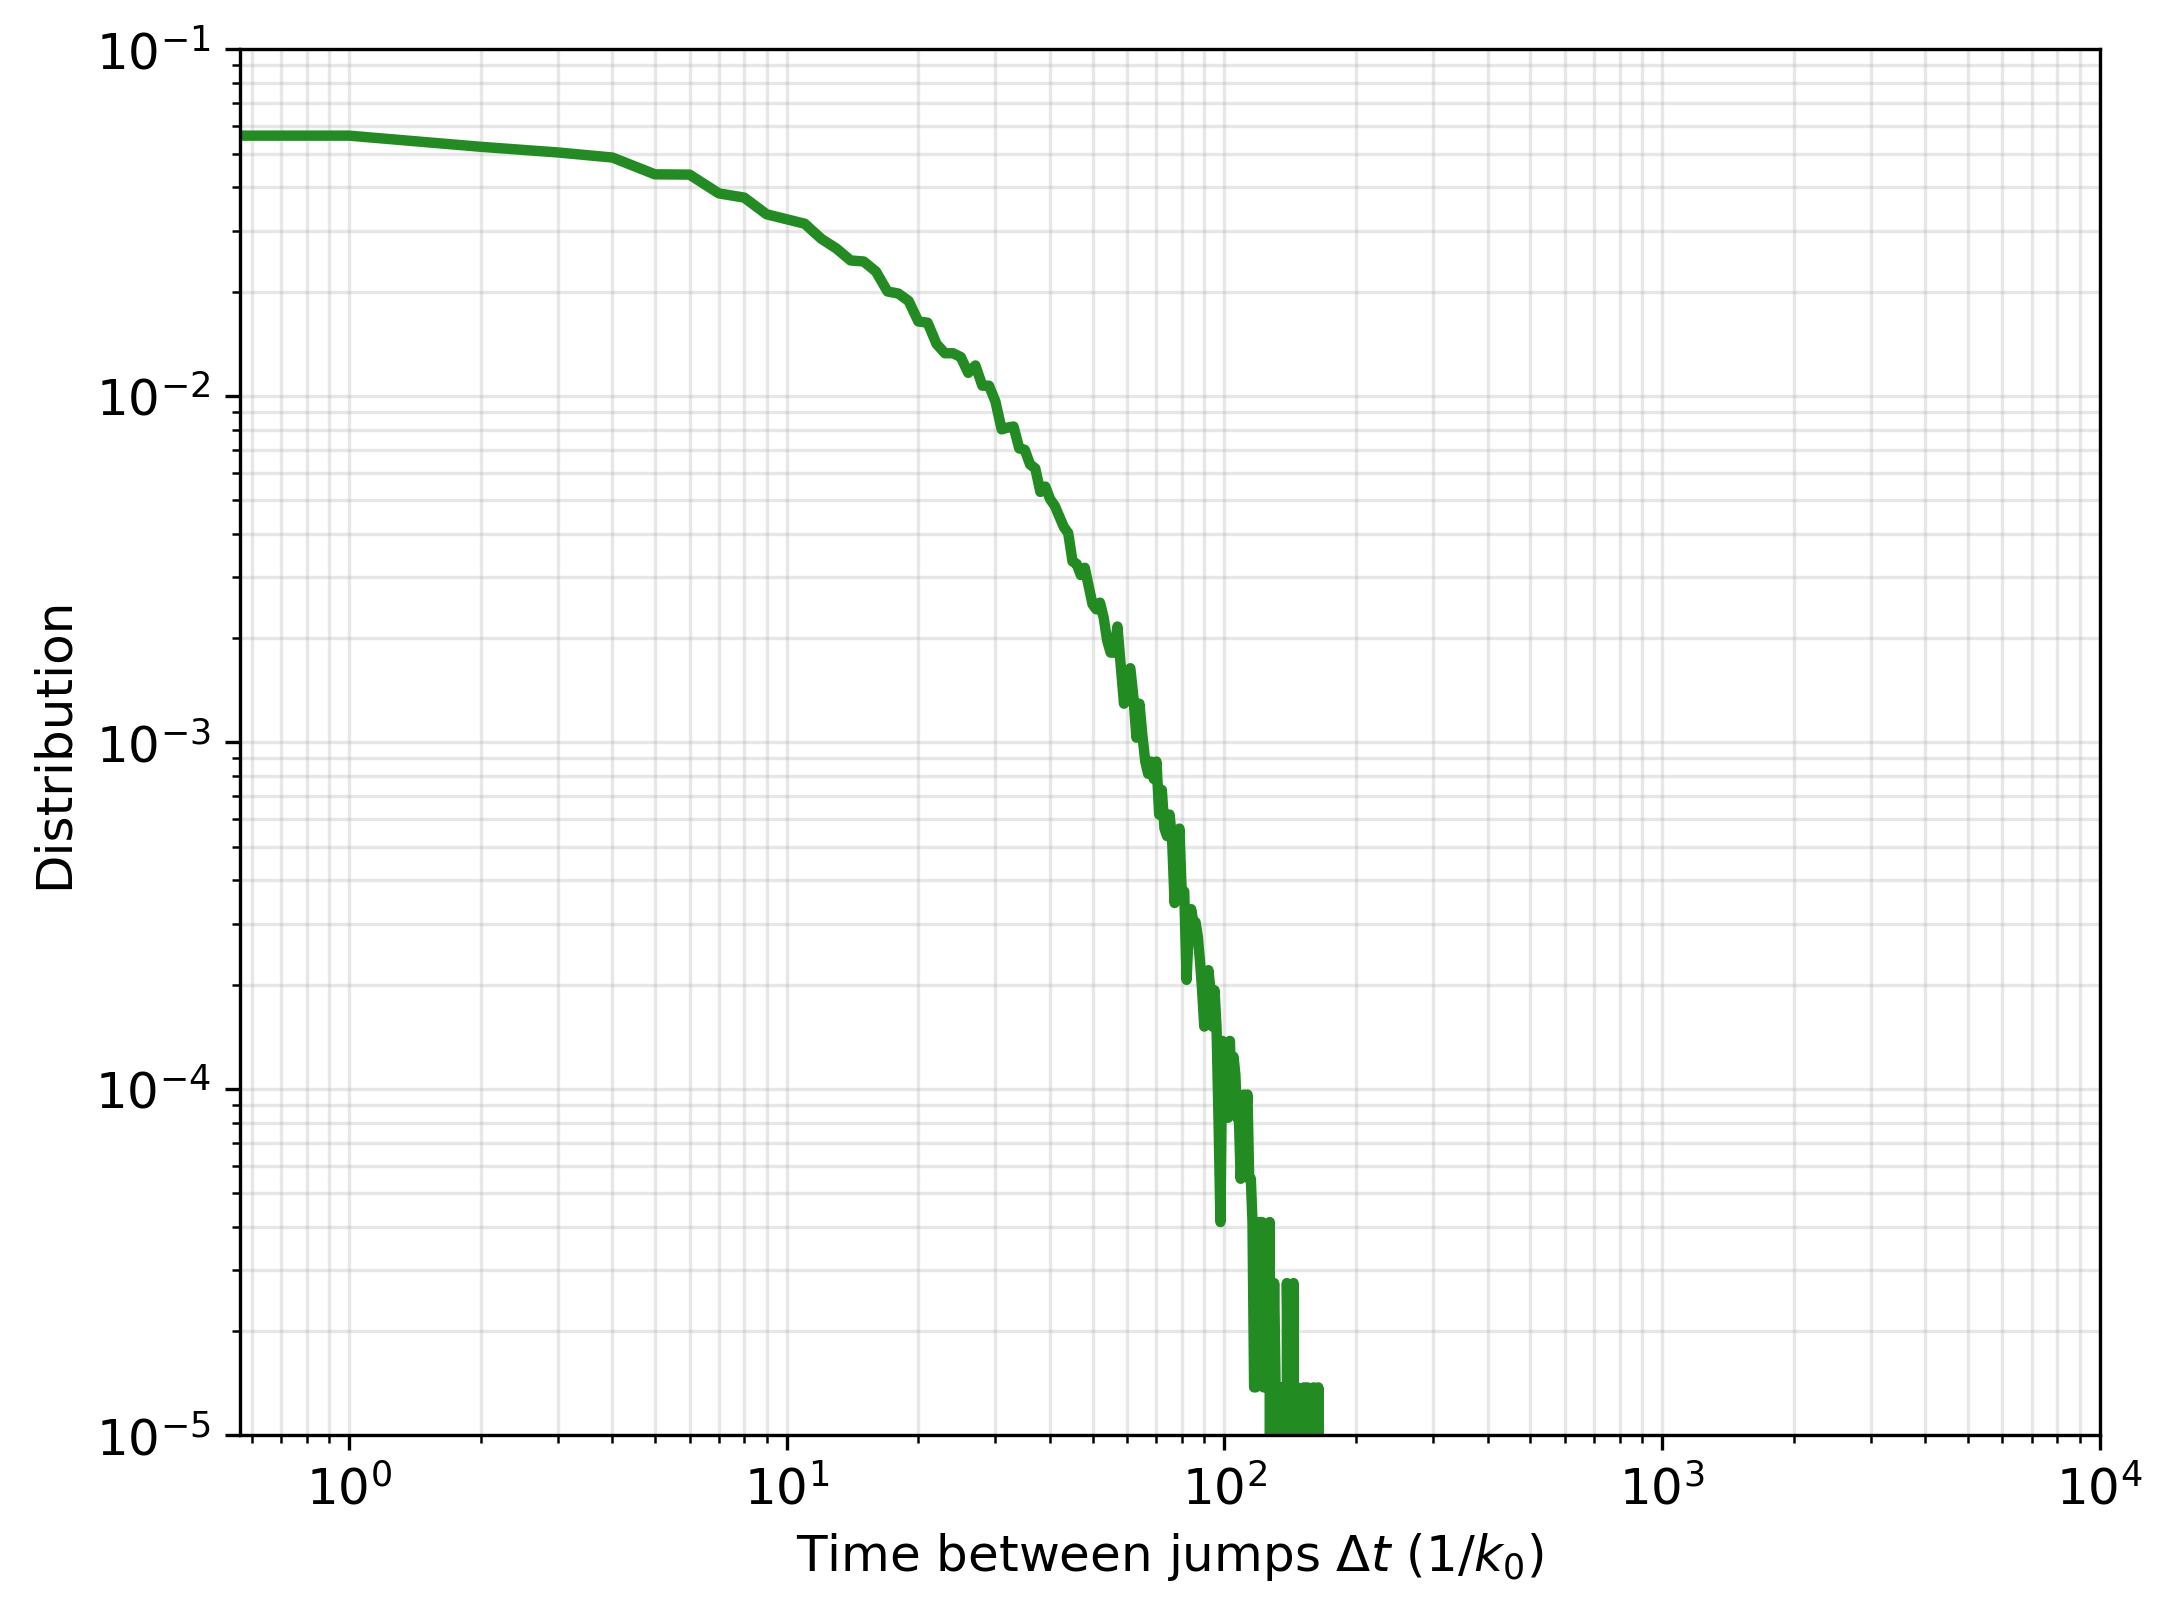

In [3]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()

plt.figure(figsize=(8, 6), dpi=300)

# --- Time between jumps ---
plt.plot(
    tbj_points,
    tbj_distrib,
    color="forestgreen",
    linewidth=2.5,
)
plt.xscale("log")
plt.yscale("log")
plt.xlim([0, 1e4])
plt.ylim([1e-5, 1e-1])
plt.xlabel(r"Time between jumps $\Delta t$ (1/$k_0$)")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.show()


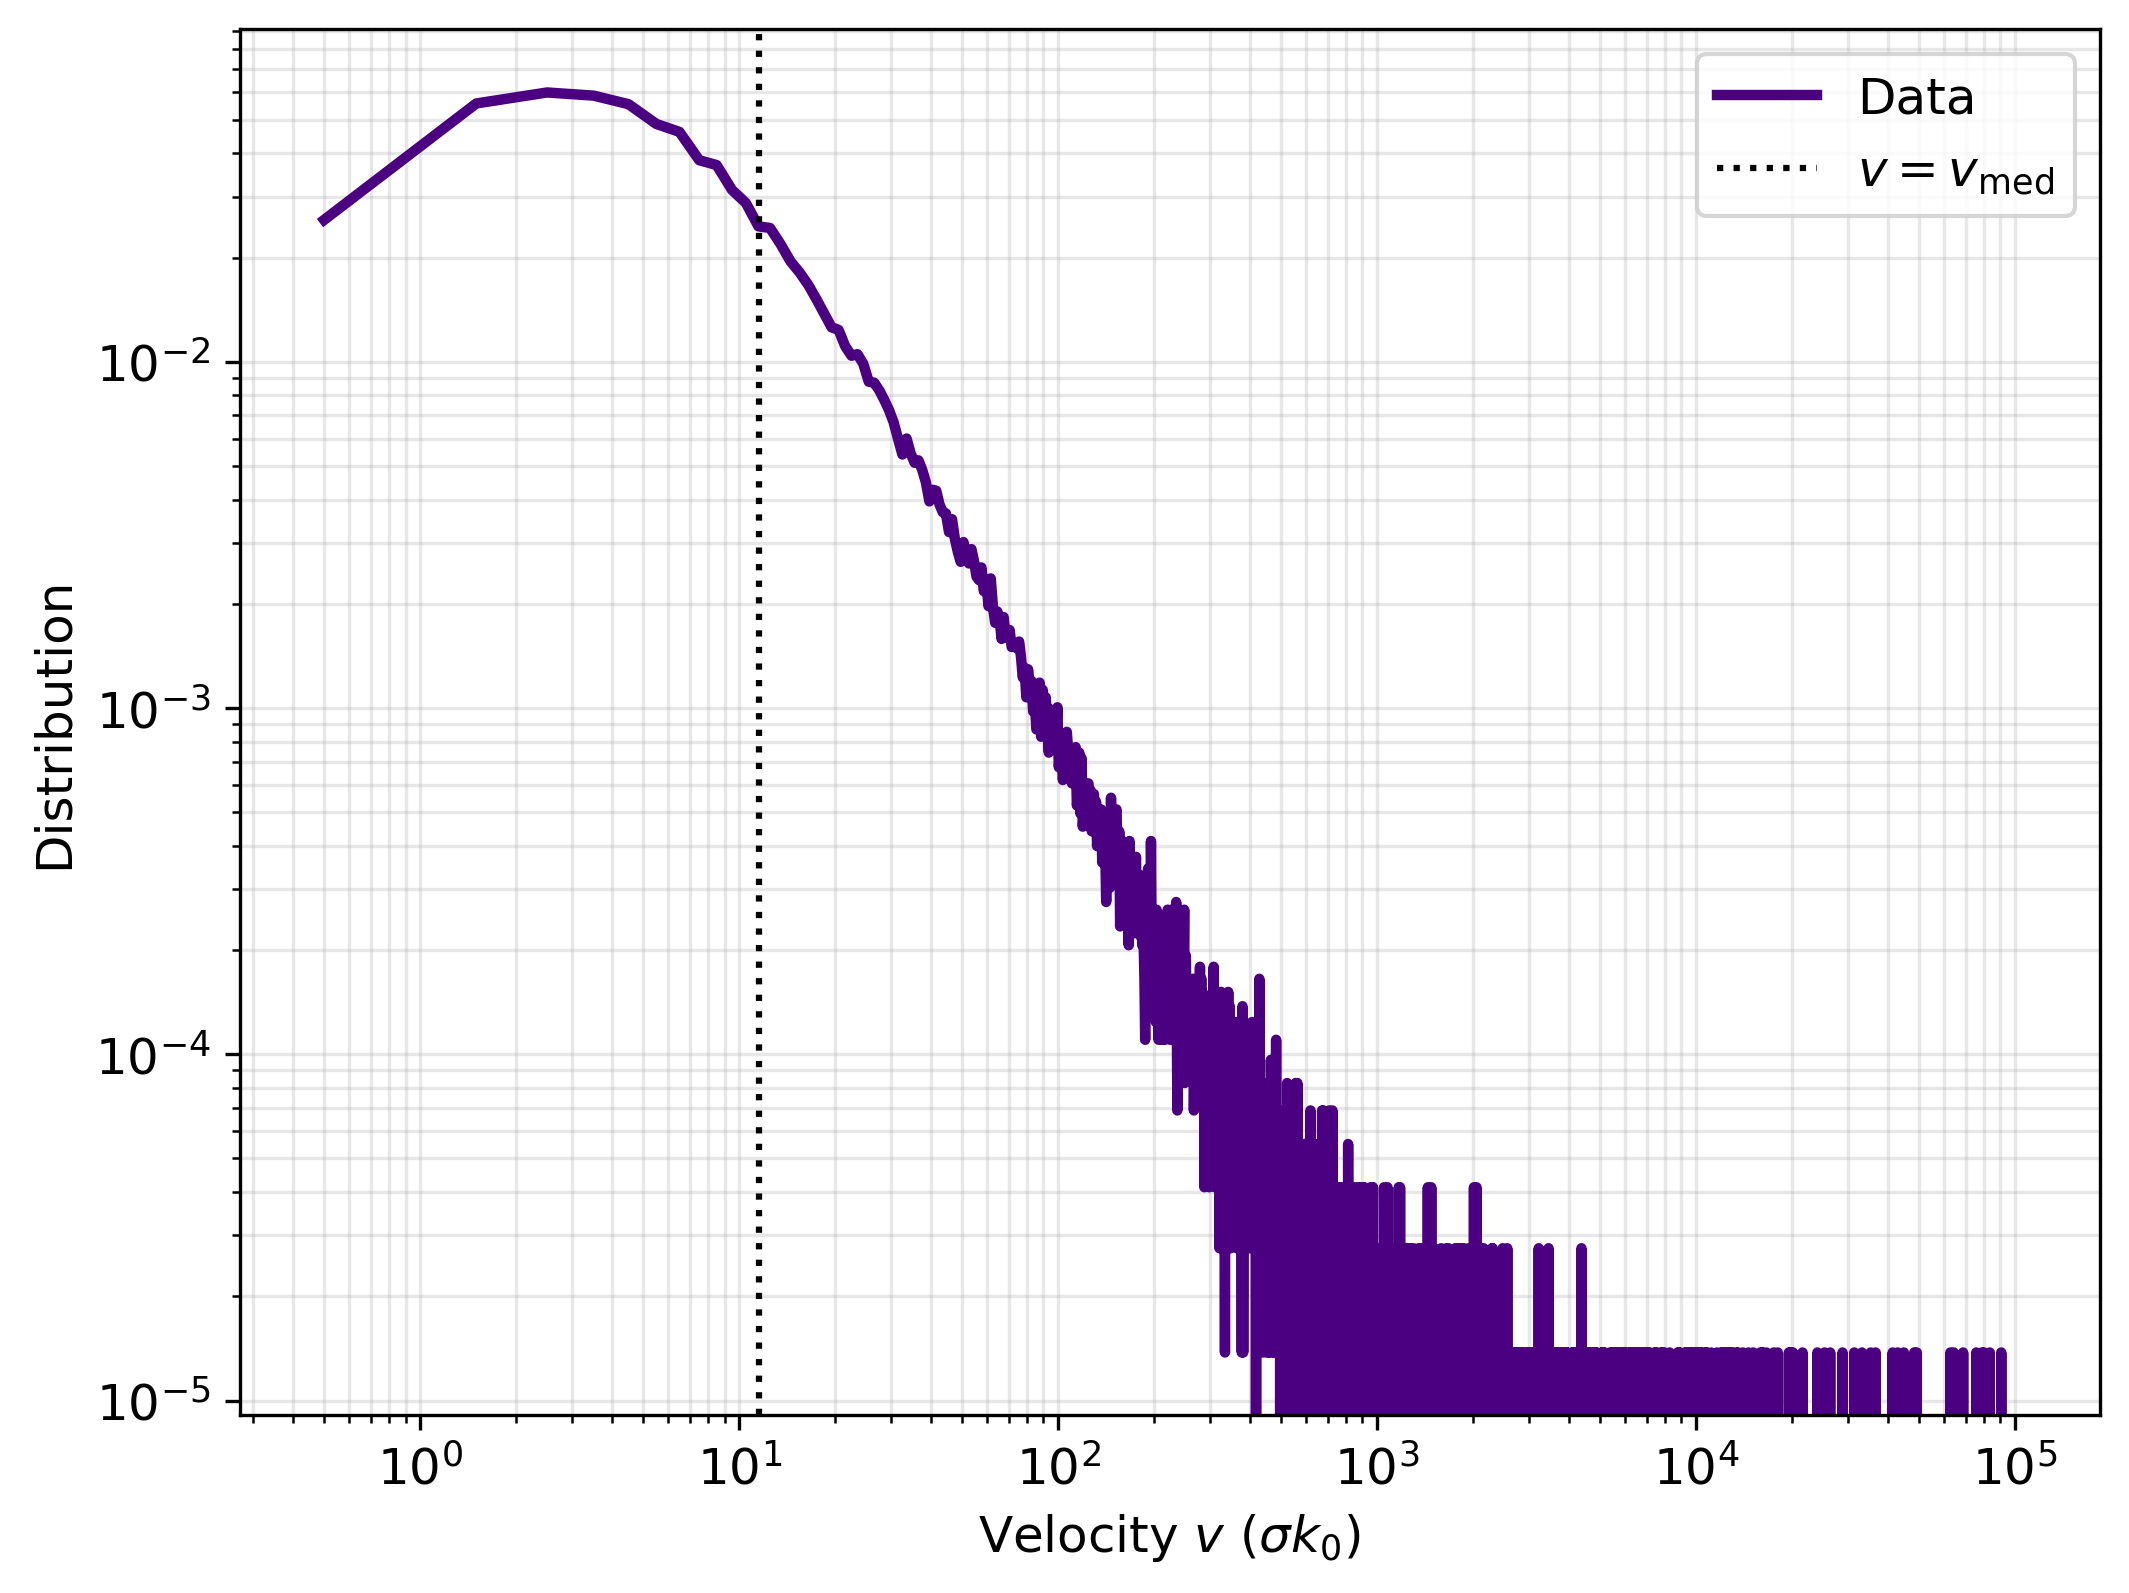

In [4]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()
vi_med = df["vi_med"][0]

plt.figure(figsize=(8, 6), dpi=300)

# --- Velocity ---
plt.plot(
    vi_points,
    vi_distrib,
    color="indigo",
    linewidth=2.5,
    label="Data"
)

plt.axvline(x=vi_med, color="black", linestyle=":", linewidth=1.5, label=r"$v = v_{\text{med}}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Velocity $v$ ($\sigma k_0$)")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.legend()
plt.show()

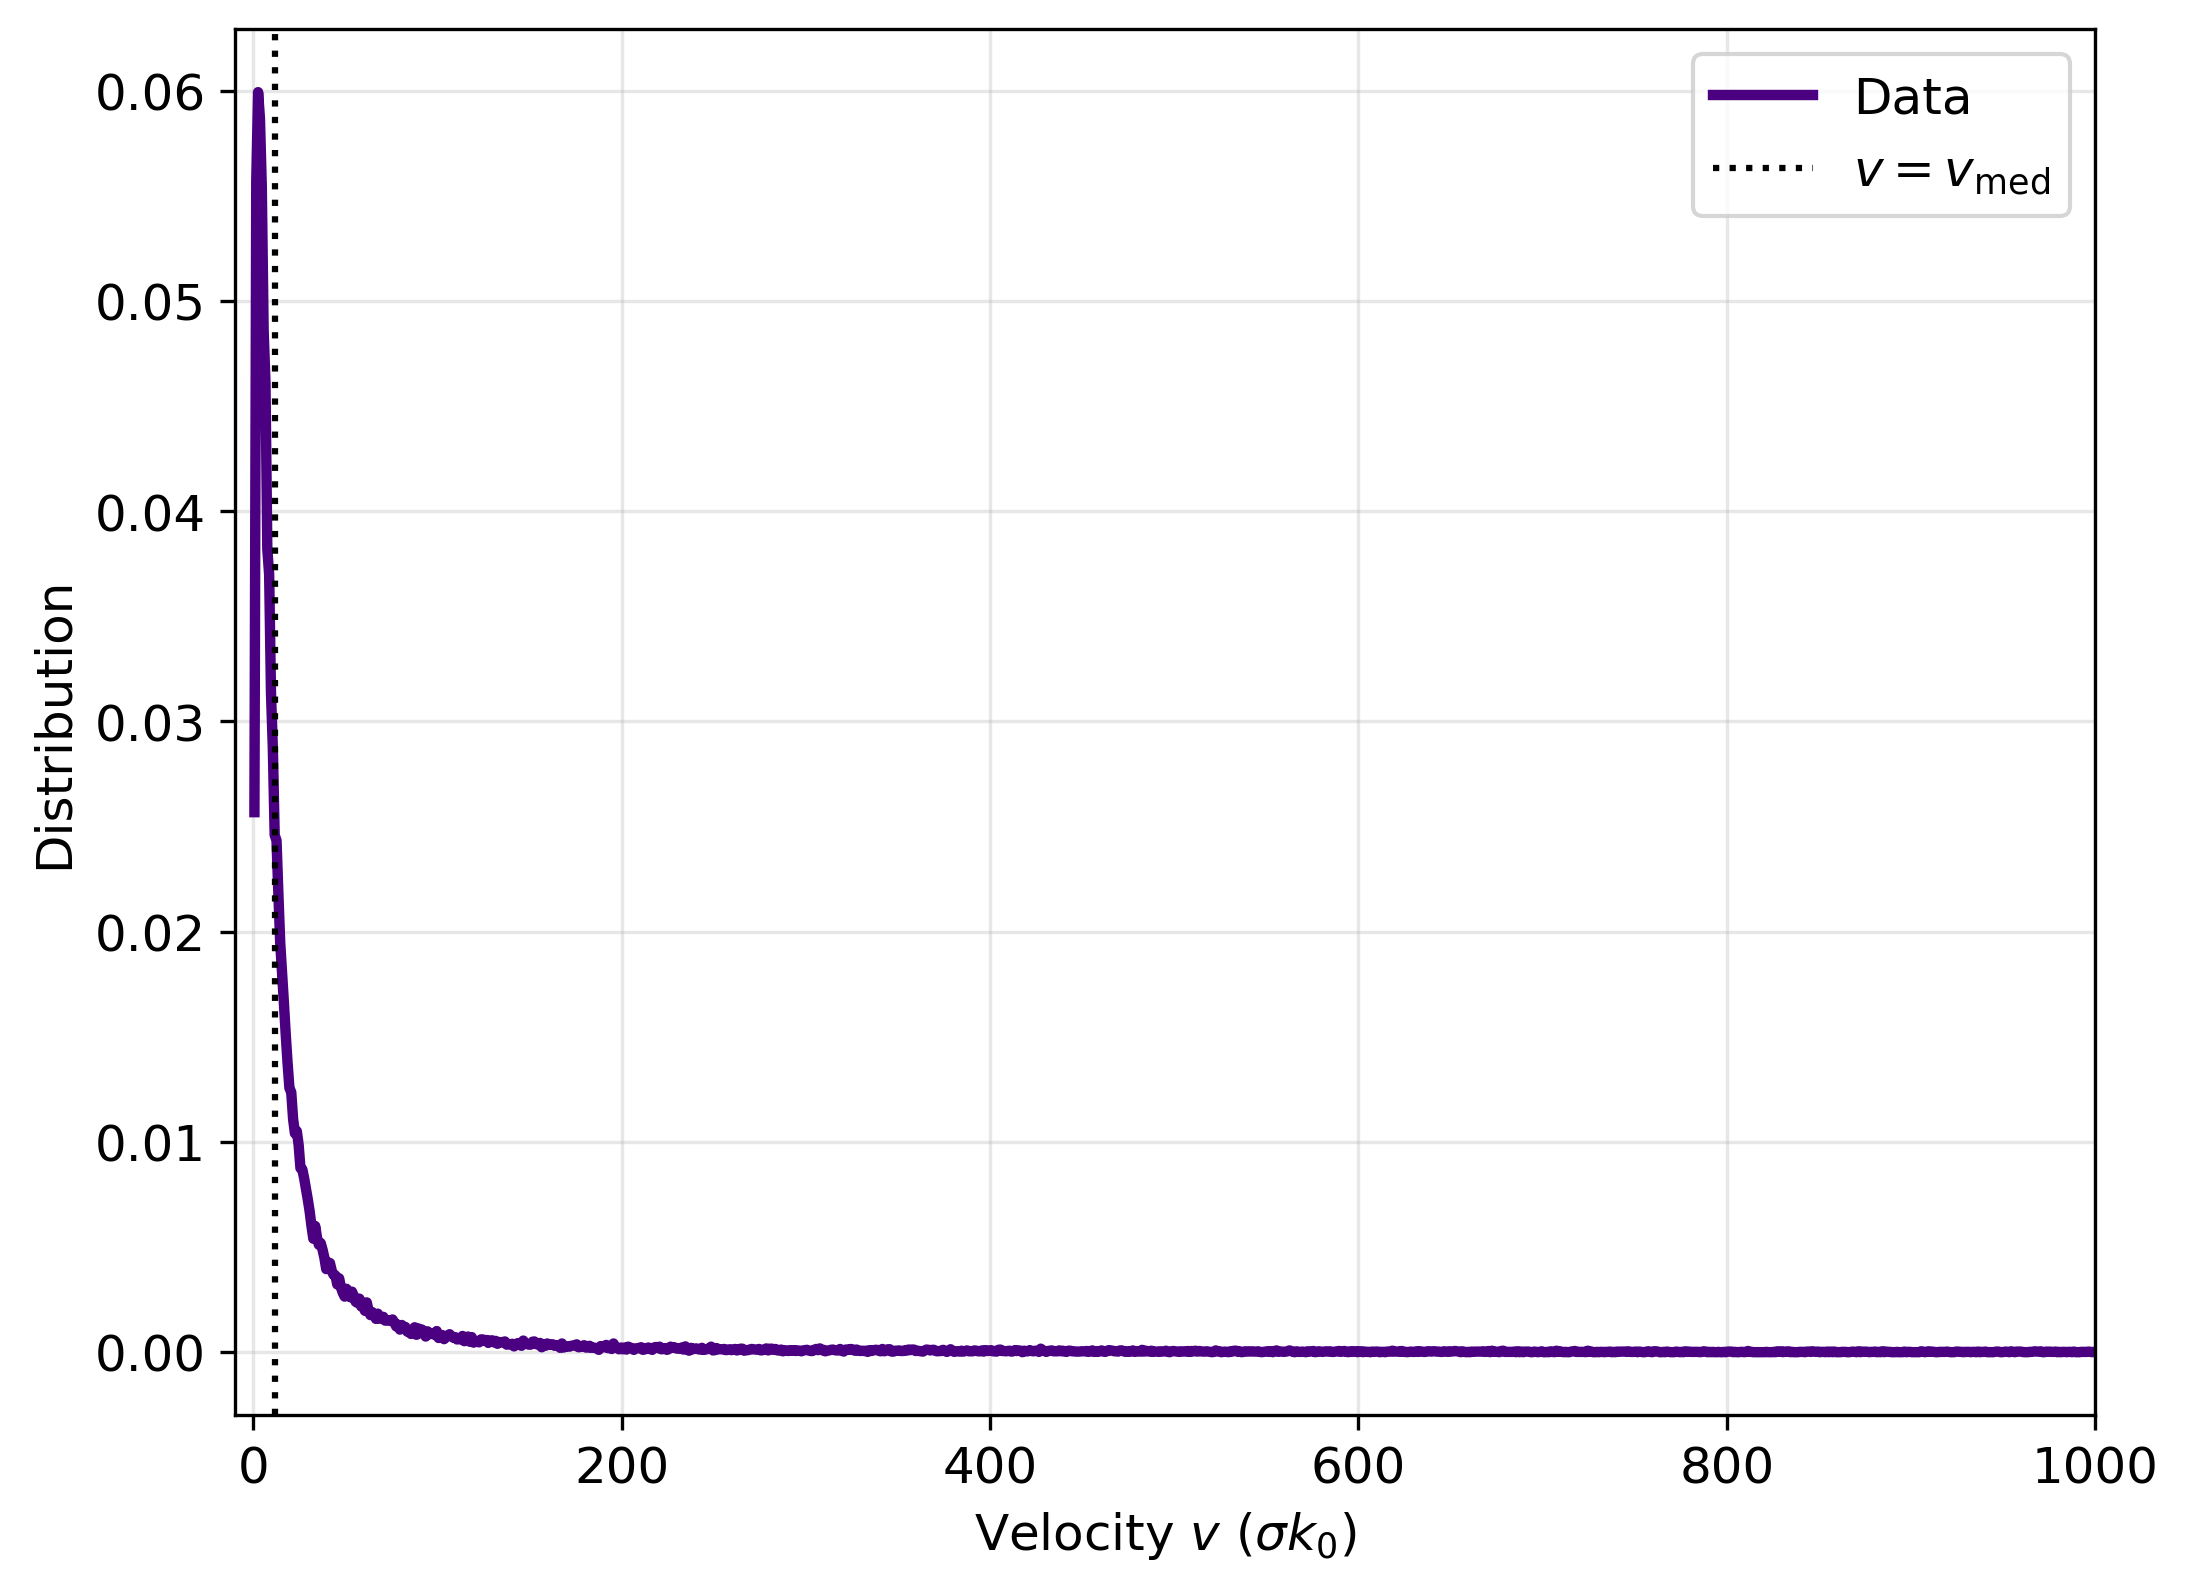

In [5]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()
vi_med = df["vi_med"][0]

plt.figure(figsize=(8, 6), dpi=300)

# --- Velocity ---
plt.plot(
    vi_points,
    vi_distrib,
    color="indigo",
    linewidth=2.5,
    label="Data"
)

plt.axvline(x=vi_med, color="black", linestyle=":", linewidth=1.5, label=r"$v = v_{\text{med}}$")
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"Velocity $v$ ($\sigma k_0$)")
plt.ylabel("Distribution")
plt.xlim(-1e1, 1e3)
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.legend()
plt.show()

Loading subfiles:  99%|█████████▉| 190/192 [00:03<00:00, 56.06subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__3/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


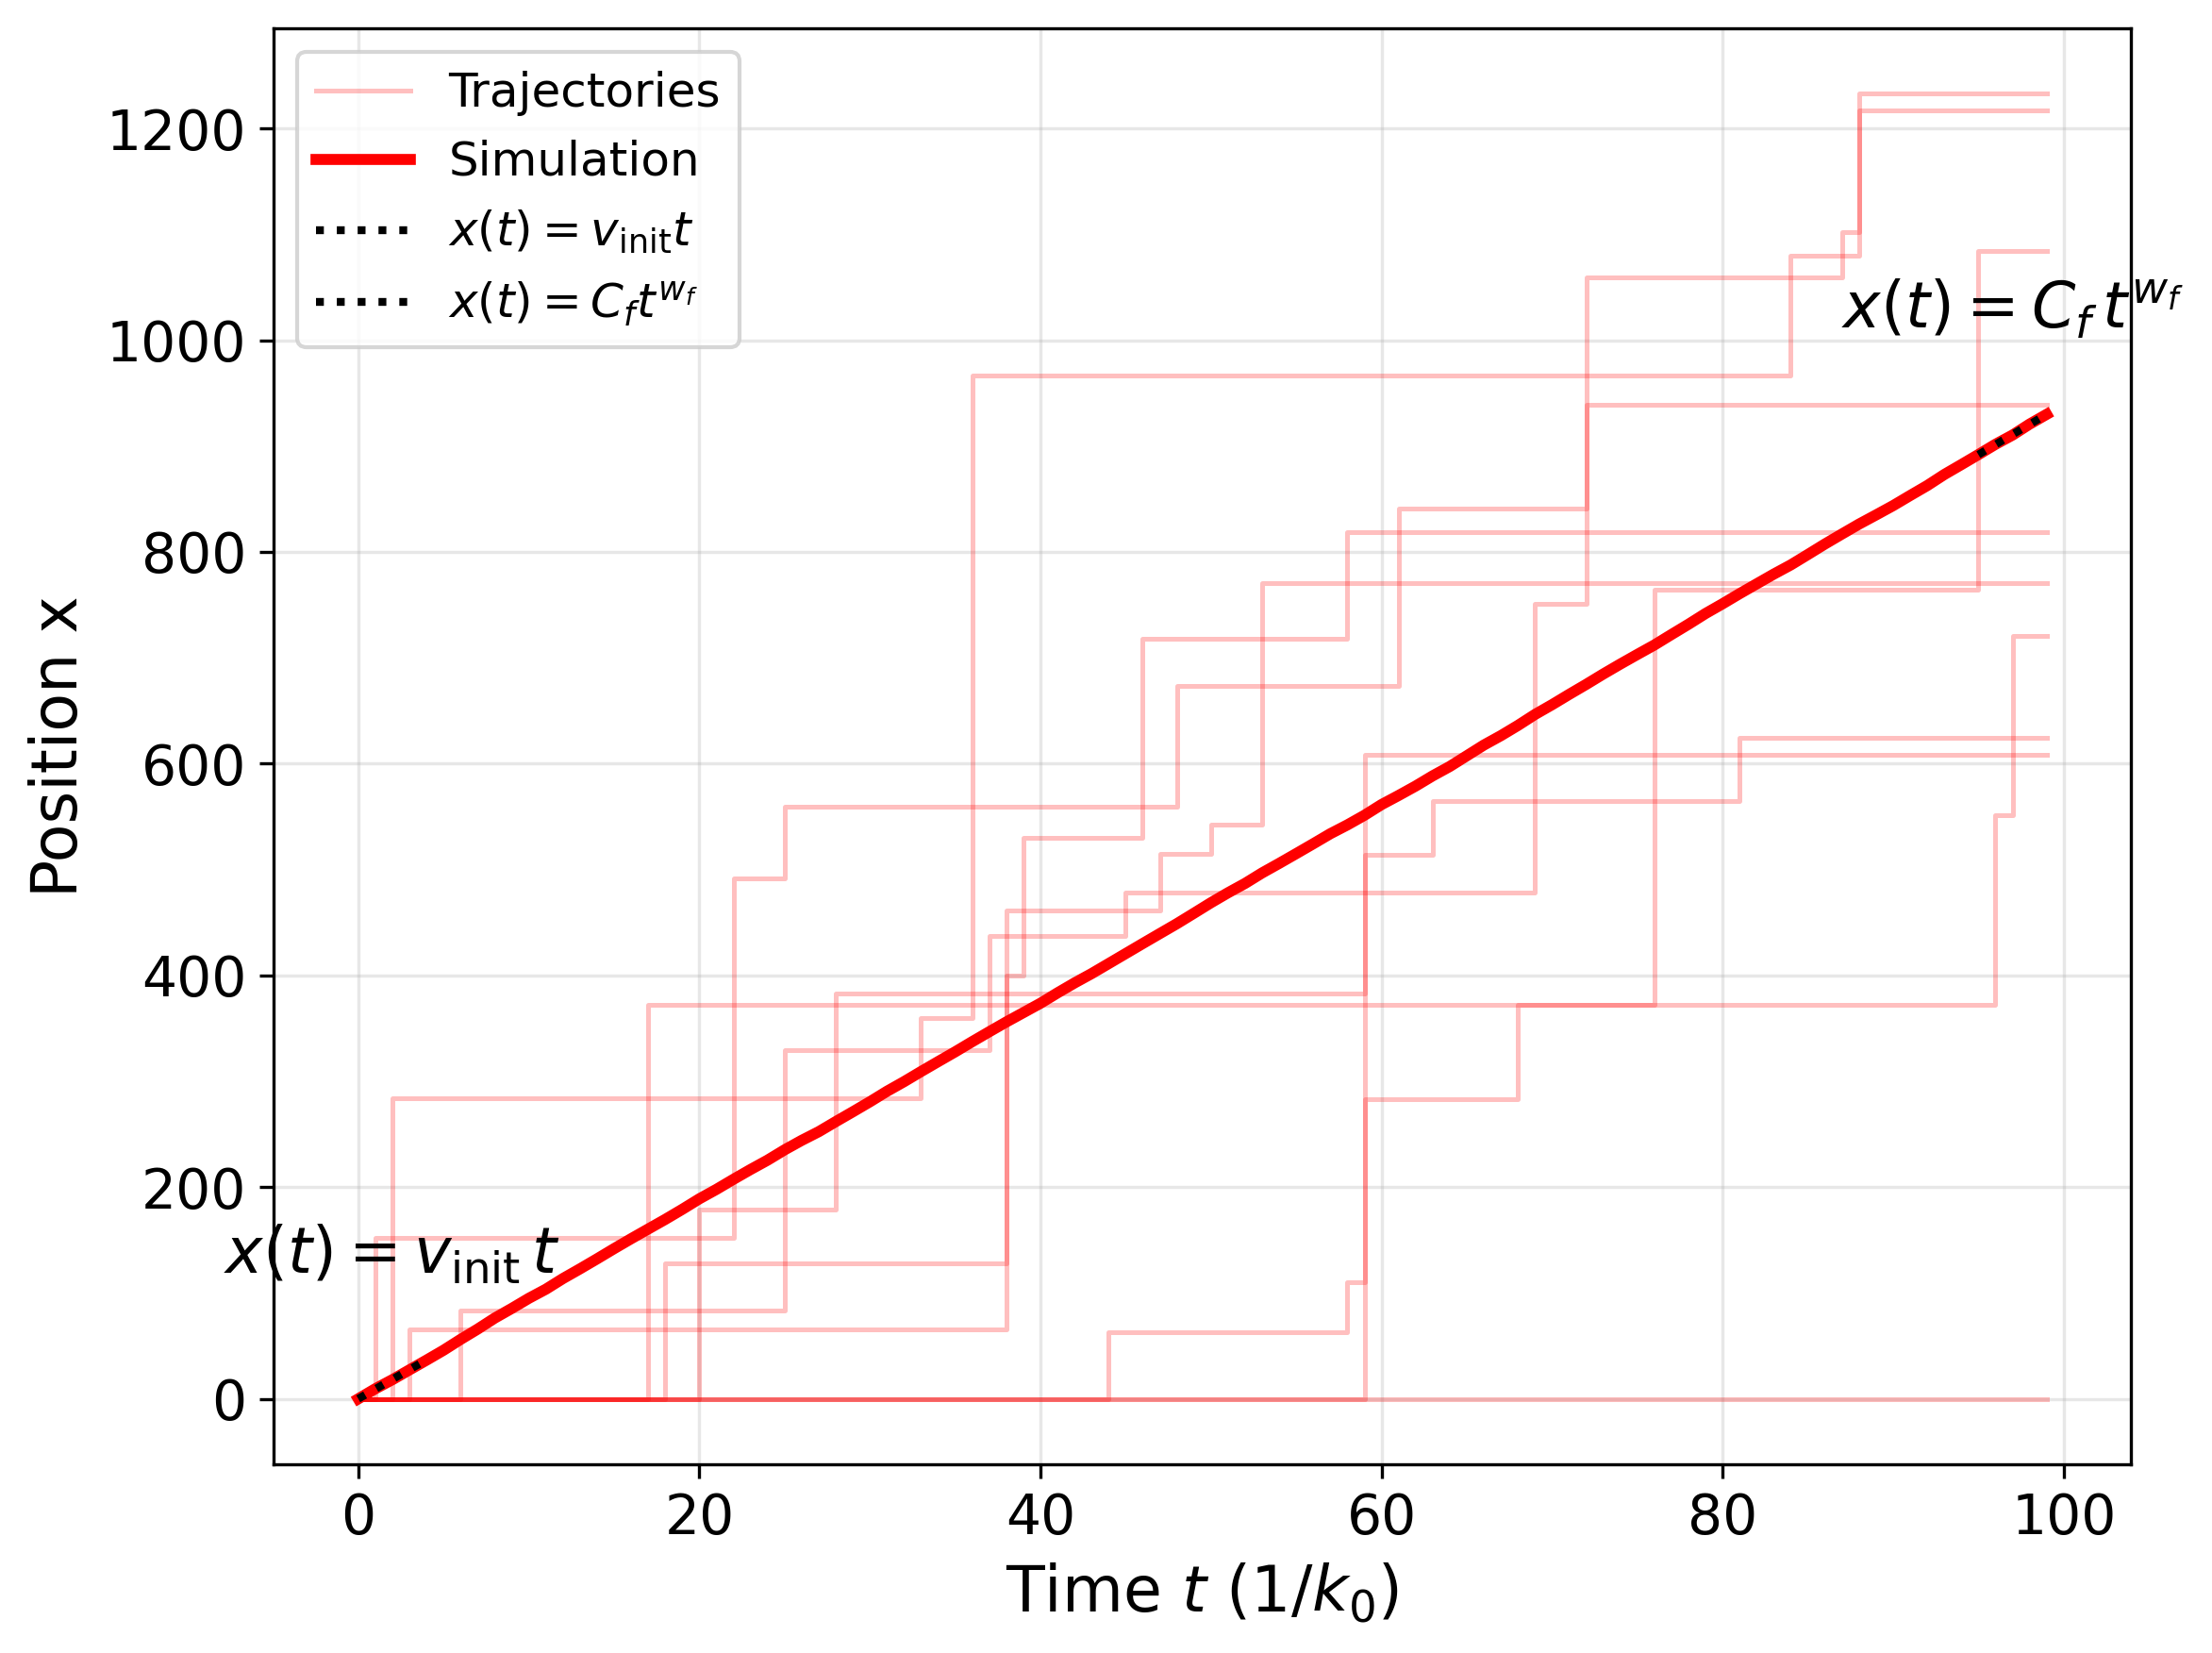

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 12

# Chargement
df = find_parquet_and_load(**params)

times = df["times"][0].to_numpy()
results = df["results"][0].to_numpy()
vf = df["vf"].to_numpy()
Cf = df["Cf"].to_numpy()
wf = df["wf"].to_numpy()


# Moyenne des trajectoires
mean_traj = np.mean(results, axis=0)

plt.figure(figsize=(8, 6), dpi=300)

# Fits début et fin
t_fit_init = times[0:5]
x_fit_init = vf * t_fit_init

t_fit_final = times[95:100]
x_fit_final = Cf * t_fit_final**wf

# Trajectoires individuelles
for i in range(10):
    plt.step(
        times,
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )

# Trajectoire moyenne
plt.plot(
    times,
    mean_traj,
    color="red",
    linewidth=2.8,
    label="Simulation",
)

# Fit initial (linéaire) 
plt.plot( t_fit_init, x_fit_init, color="black", linestyle=":", linewidth=2, label=r"$x(t)=v_{\mathrm{init}}t$", )

# Fit final (puissance)
plt.plot(
    t_fit_final,
    x_fit_final,
    color="black",
    linestyle=":",
    linewidth=2,
    label=r"$x(t)=C_f t^{w_f}$",
)

# Annotations
plt.text(
    t_fit_init[len(t_fit_init)//2],
    x_fit_init[len(x_fit_init)//2] + 100,
    r"$x(t)=v_{\mathrm{init}}\,t$",
    fontsize=16,
    ha="center",
)

plt.text(
    t_fit_final[len(t_fit_final)//2],
    x_fit_final[len(x_fit_final)//2] + 100,
    r"$x(t)=C_f\,t^{w_f}$",
    fontsize=16,
    ha="center",
)

# Mise en forme
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)

plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)

plt.legend(fontsize=12)
# ax.set_title(r"$\mu = 160,\ \theta = 20$", fontsize=18)

plt.tight_layout()
plt.show()

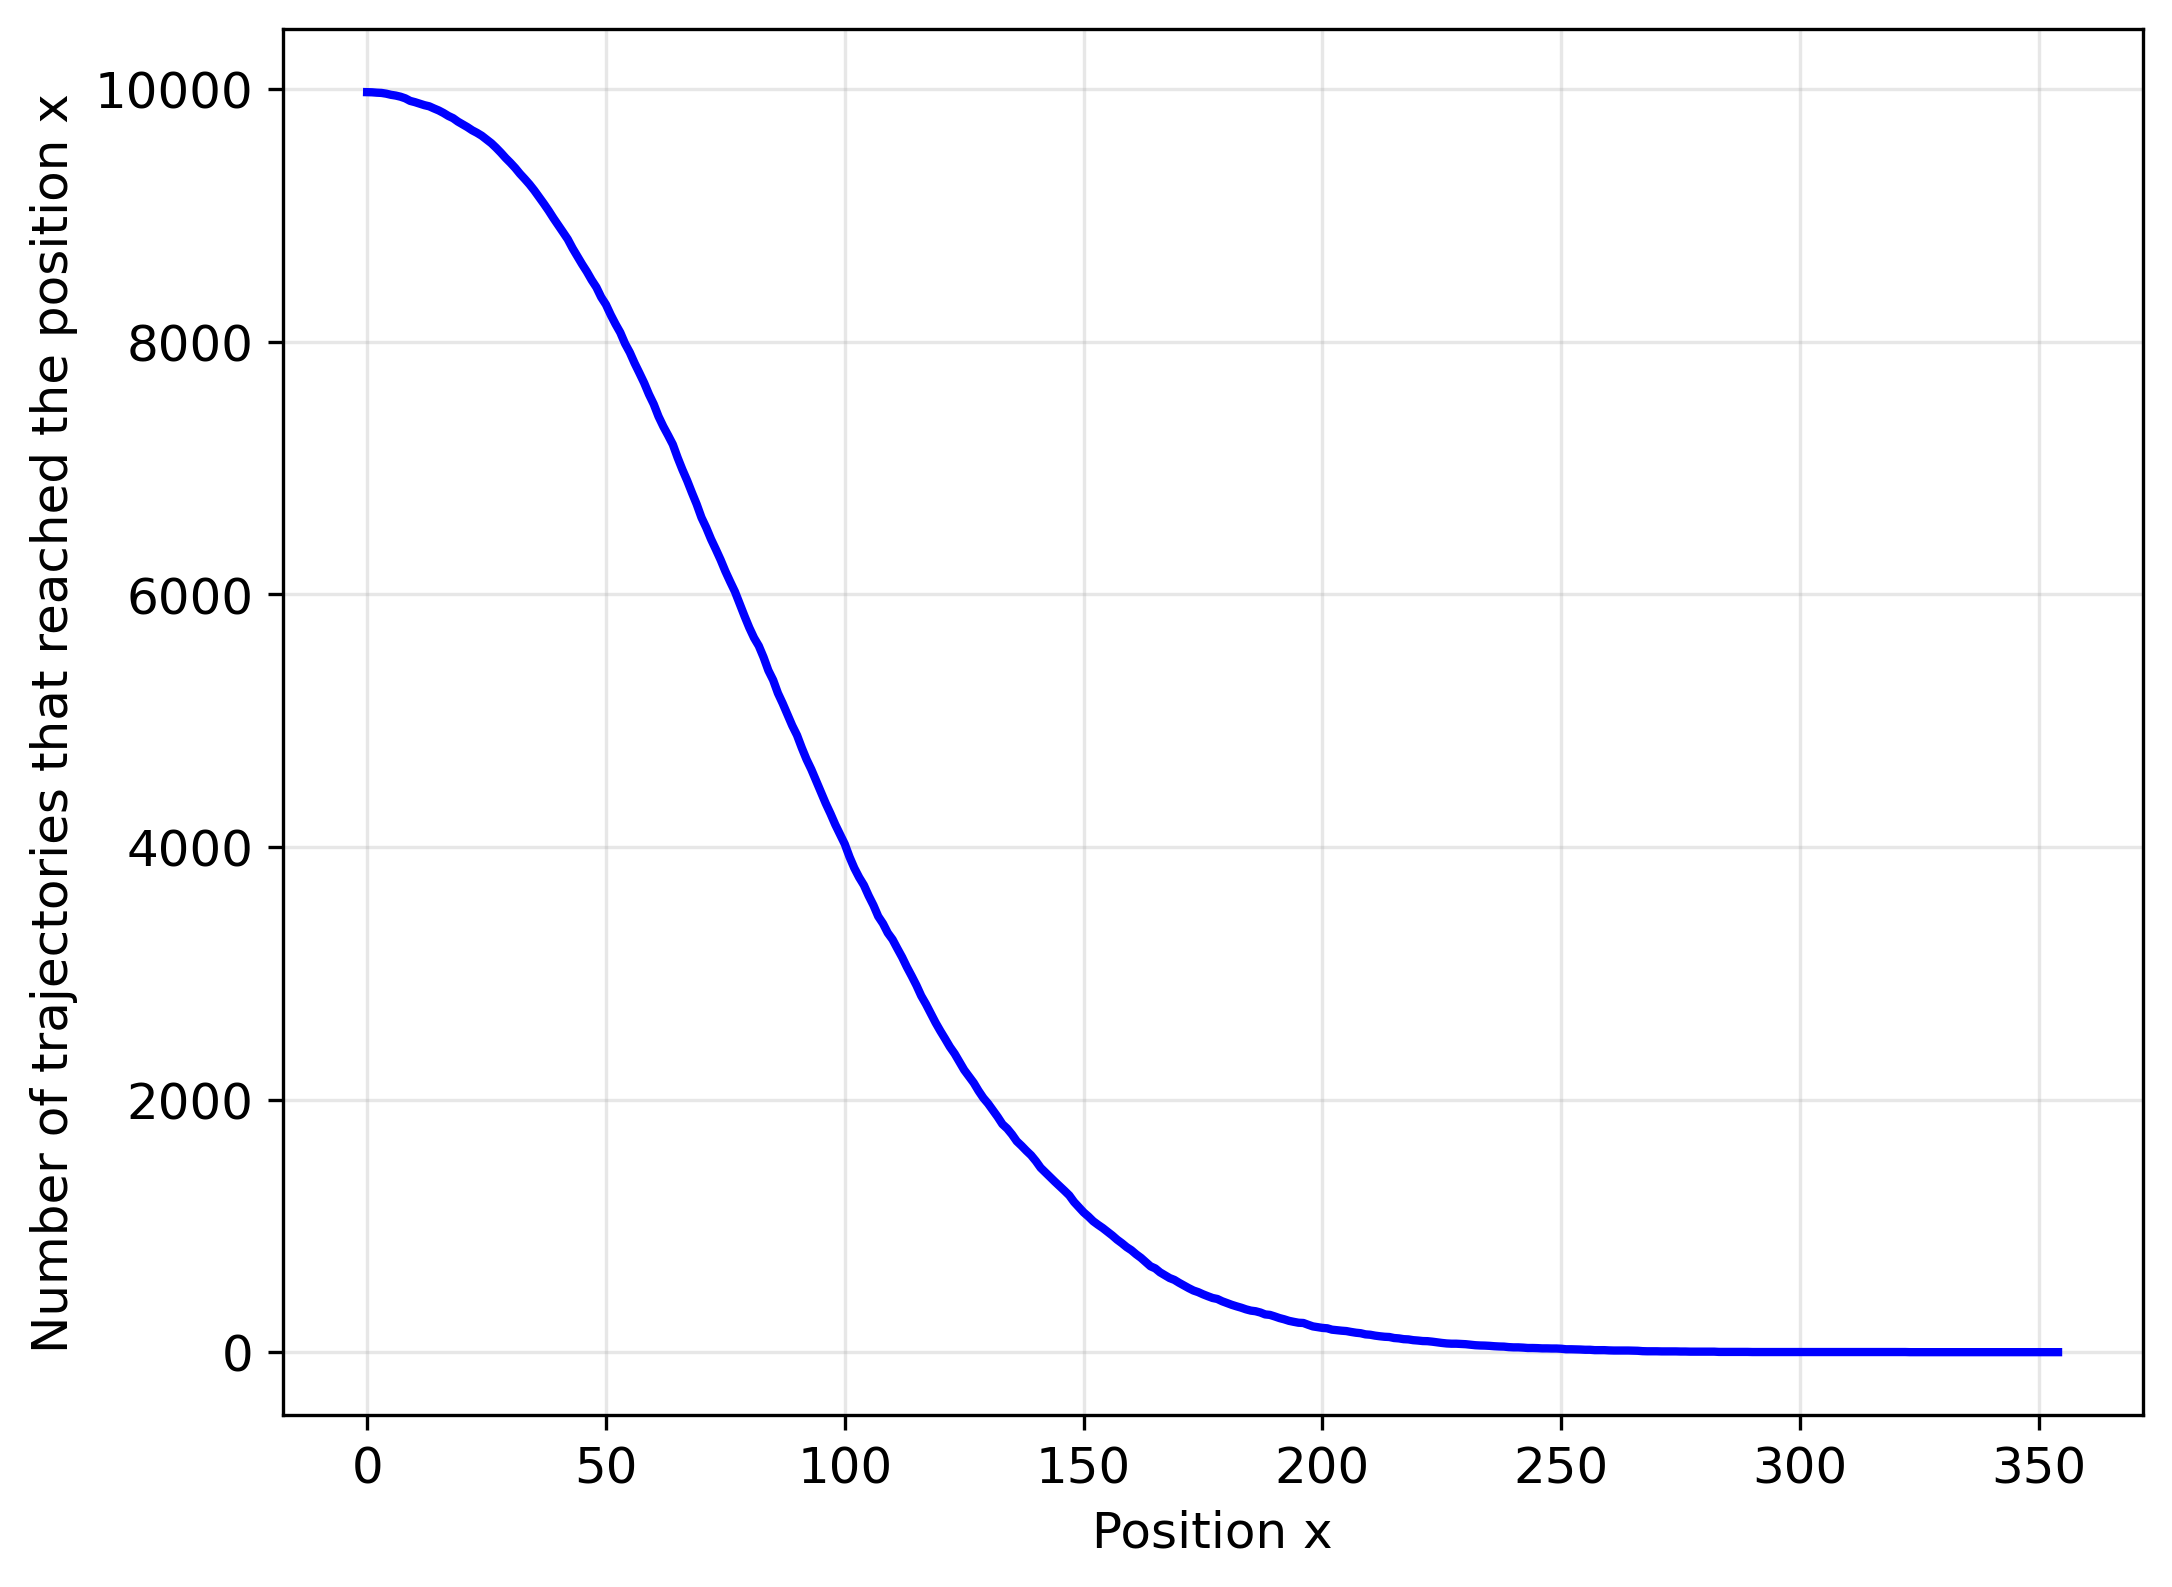

In [7]:
plt.figure(figsize=(8, 6), dpi=300)
plt.rcParams["font.size"] = 12
n_reached = df["fpt_number"][0].to_numpy()
plt.plot(n_reached, color="blue", linewidth=2.0)
plt.xlabel("Position x")
plt.ylabel("Number of trajectories that reached the position x")
plt.grid(True, alpha=0.30)
plt.show()

float64
(102, 355)
<class 'numpy.ndarray'>
(355,)


<Axes: title={'center': 'Distribution of FPTs'}, xlabel='Position x', ylabel='Time t'>

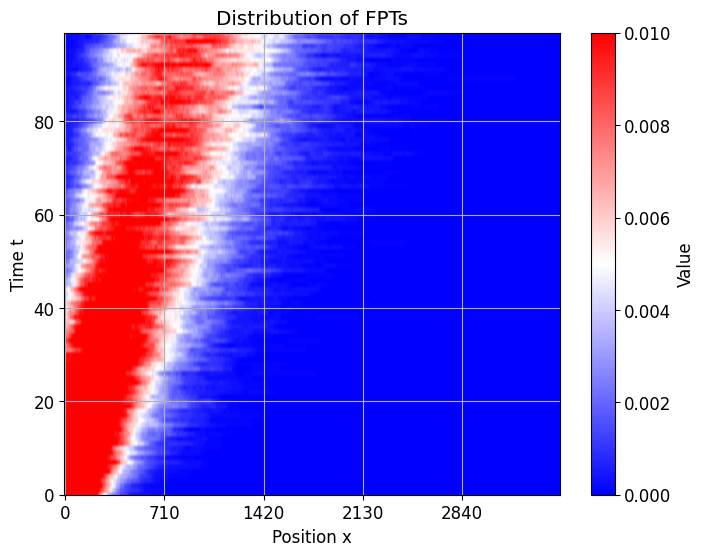

In [8]:
from nucleo.io.plots_1D import plot_fpt_distrib_2d
plt.rcParams["font.size"] = 12


fpt_distrib = df["fpt_distrib"][0].to_numpy()
fpt_distrib = np.stack(fpt_distrib)
tmax = df["tmax"][0]
bint = df["bint"][0]

print(fpt_distrib.dtype)
print(fpt_distrib.shape)
print(type(fpt_distrib[0]))
print(fpt_distrib[0].shape)

plot_fpt_distrib_2d(
    fpt_distrib_2D=fpt_distrib,
    tmax=tmax,
    time_bin=bint,
)

Loading subfiles:  37%|███▋      | 71/192 [00:01<00:02, 43.38subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__36/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=190__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=190__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


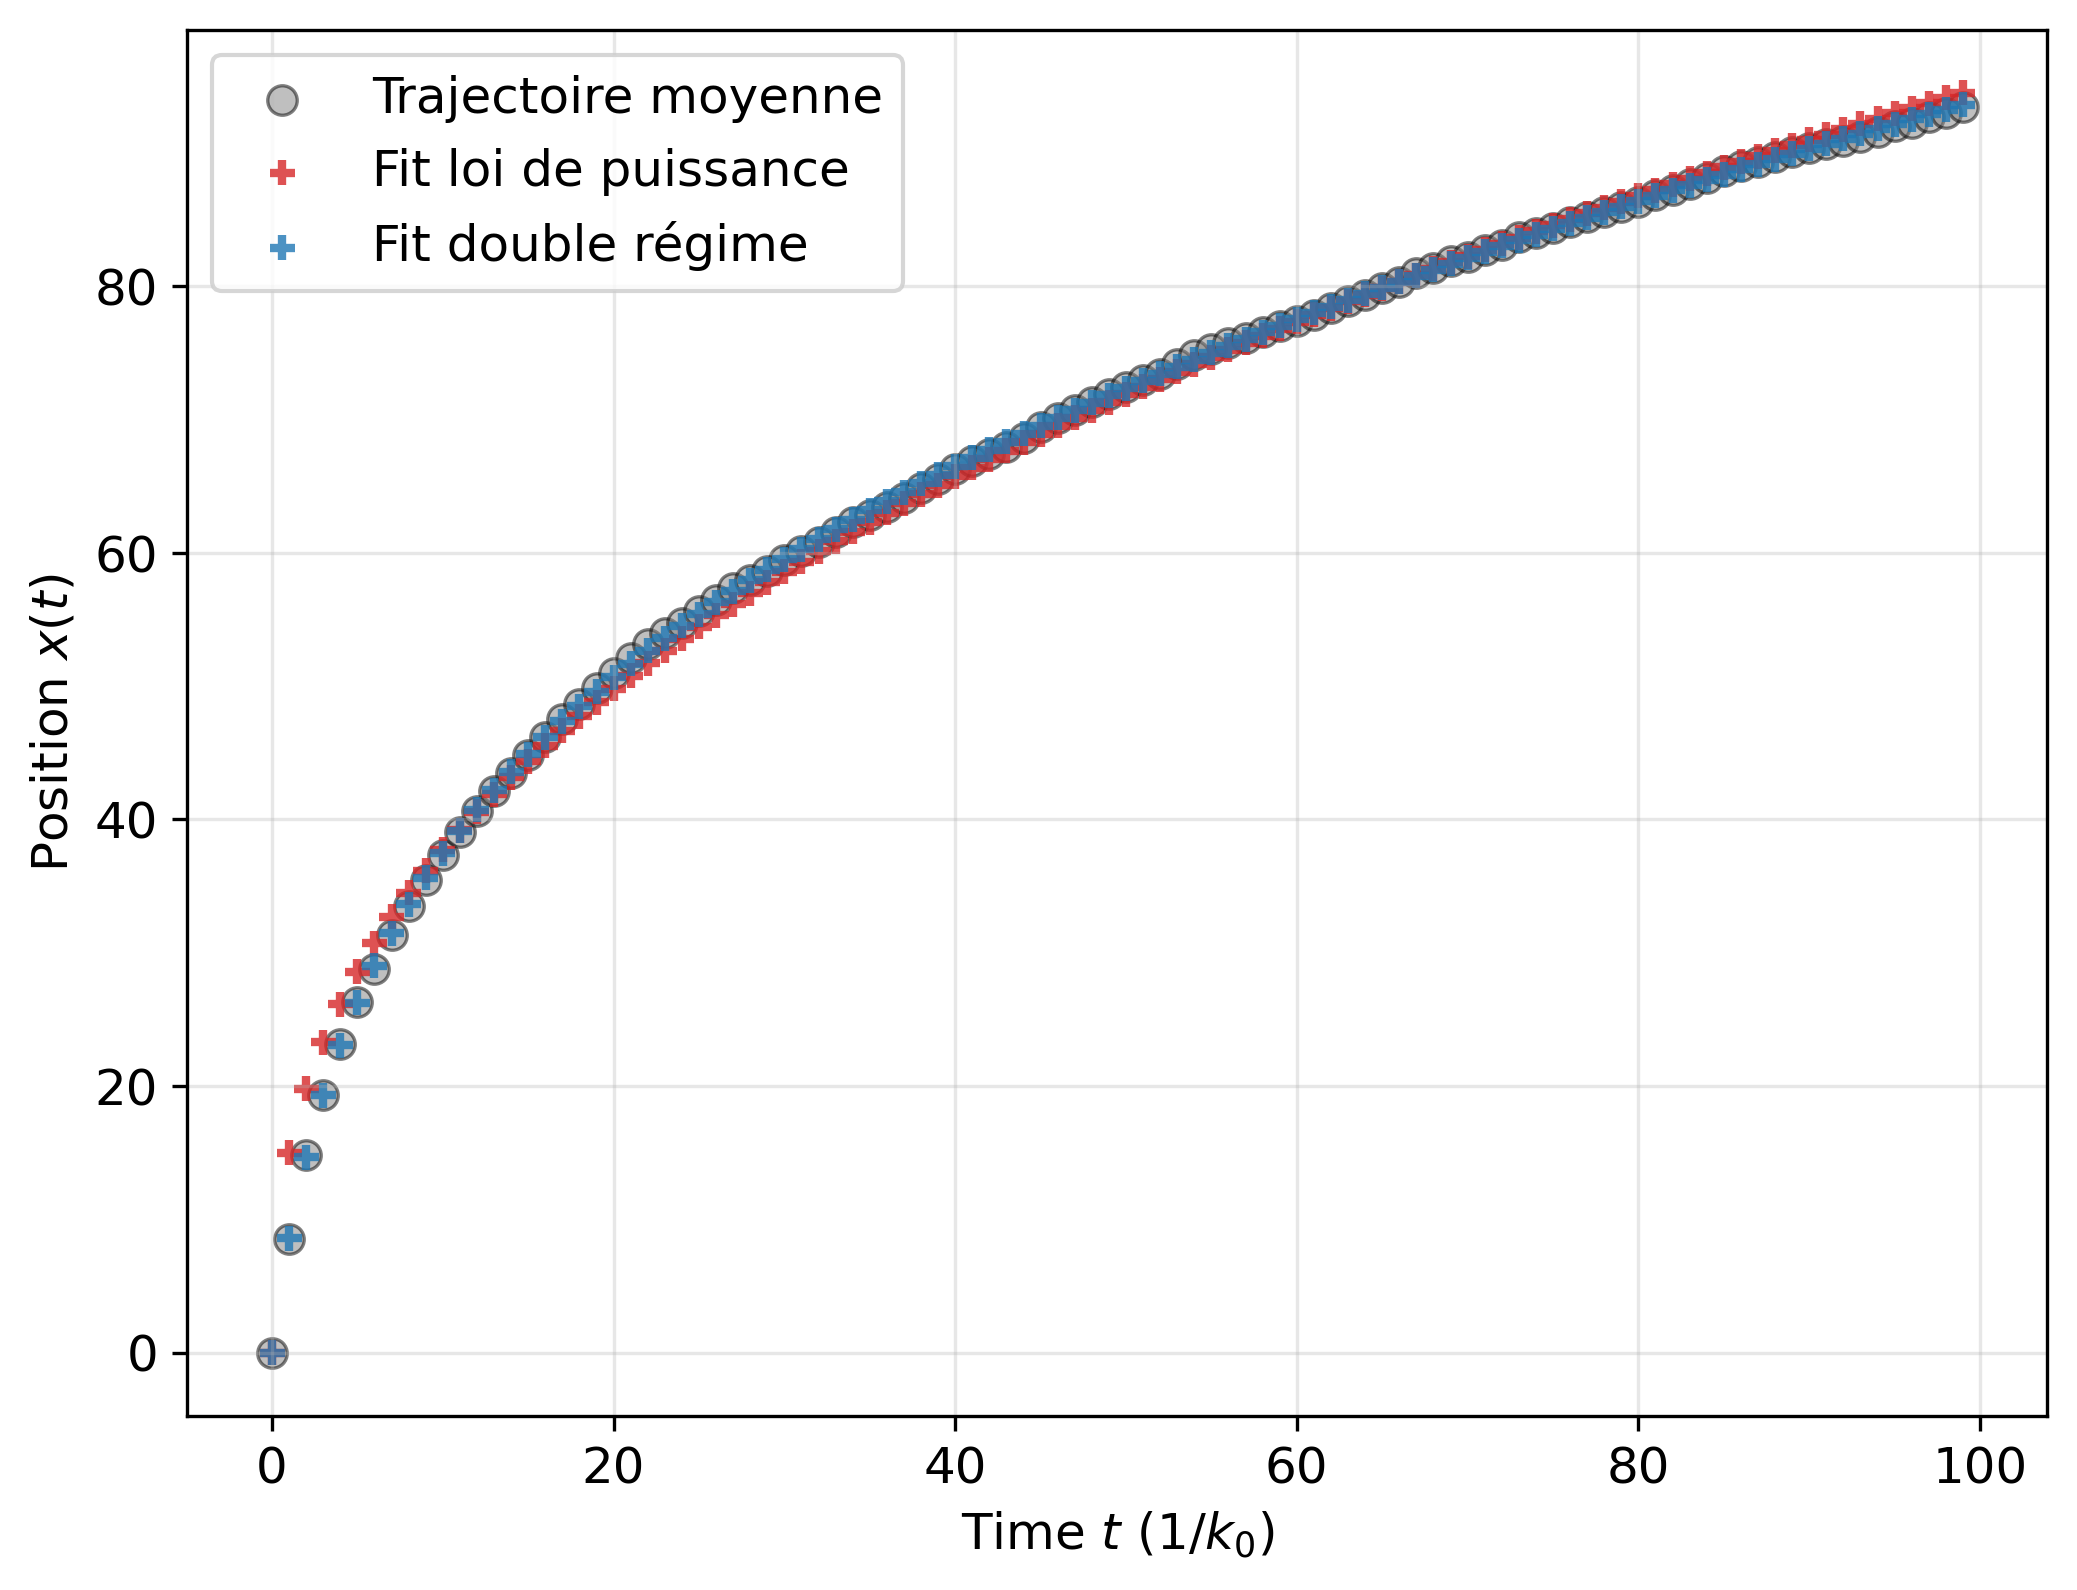

In [9]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 190,  # 180 Ok 190 pas top
    "theta": 10,
    "nt": 10_000,
}
df = find_parquet_and_load(**params)
results = df["results"][0].to_numpy()
times = df["times"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
results_std = df["results_std"][0].to_numpy()

# --- Fit 1 : loi de puissance simple x(t) ~ t^alpha ---
def power_law(t, A, alpha):
    return A * t**alpha
# on évite t=0 pour la loi de puissance (divergence)
mask = times > 0
popt_pl, _ = curve_fit(
    power_law, times[mask], results_mean[mask],
    p0=[1.0, 0.5], maxfev=10000
)
A_fit, alpha_fit = popt_pl

# --- Fit 2 : régime linéaire simple x(t) = v * t ---
def linear_law(t, v):
    return v * t

popt_lin, _ = curve_fit(
    linear_law, times, results_mean,
    p0=[results_mean[1] / times[1]], maxfev=10000
)
v_lin_fit, = popt_lin

# --- Fit 3 : double régime (linéaire -> loi de puissance) via transition Heaviside ---
def double_regime(t, D, alpha, v, tau, h):
    ratio = (t / tau) ** h
    regime_long = D * t**alpha * ratio / (ratio + 1)
    regime_court = t * v / (ratio + 1)
    return regime_long + regime_court
# valeurs initiales : v proche de la pente aux temps courts,
# D, alpha proches du fit précédent, tau vers le milieu de la fenêtre temporelle
p0 = [A_fit, alpha_fit, results_mean[1] / times[1], np.median(times), 2.0]
popt_dr, _ = curve_fit(
    double_regime, times, results_mean, p0=p0, maxfev=20000
)
D_fit, alpha2_fit, v_fit, tau_fit, h_fit = popt_dr

# --- Visualisation comparative ---
plt.figure(figsize=(8, 6), dpi=300)
plt.scatter(
    times, results_mean,
    color="grey",
    alpha=0.50,
    s=50,
    edgecolor="black",
    linewidth=0.8,
    label="Trajectoire moyenne"
)
t_fine = np.linspace(times.min(), times.max(), 100)
# plt.scatter(
#     t_fine, linear_law(t_fine, *popt_lin),
#     color="tab:green", linestyle="--", linewidth=2,
#     label=rf"Fit linéaire",
#     marker="+", alpha=0.80
# )
plt.scatter(
    t_fine, power_law(t_fine, *popt_pl),
    color="tab:red", linestyle="--", linewidth=2,
    label=rf"Fit loi de puissance",
    marker="+", alpha=0.80
)
plt.scatter(
    t_fine, double_regime(t_fine, *popt_dr),
    color="tab:blue", linestyle="--", linewidth=2,
    label=rf"Fit double régime",
    marker="+", alpha=0.80
)
# plt.axvline(tau_fit, color="tab:blue", linestyle=":", alpha=0.5,
#             label=rf"Temps de transition $\tau$")
plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

/tmp/ipykernel_138058/2639809296.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


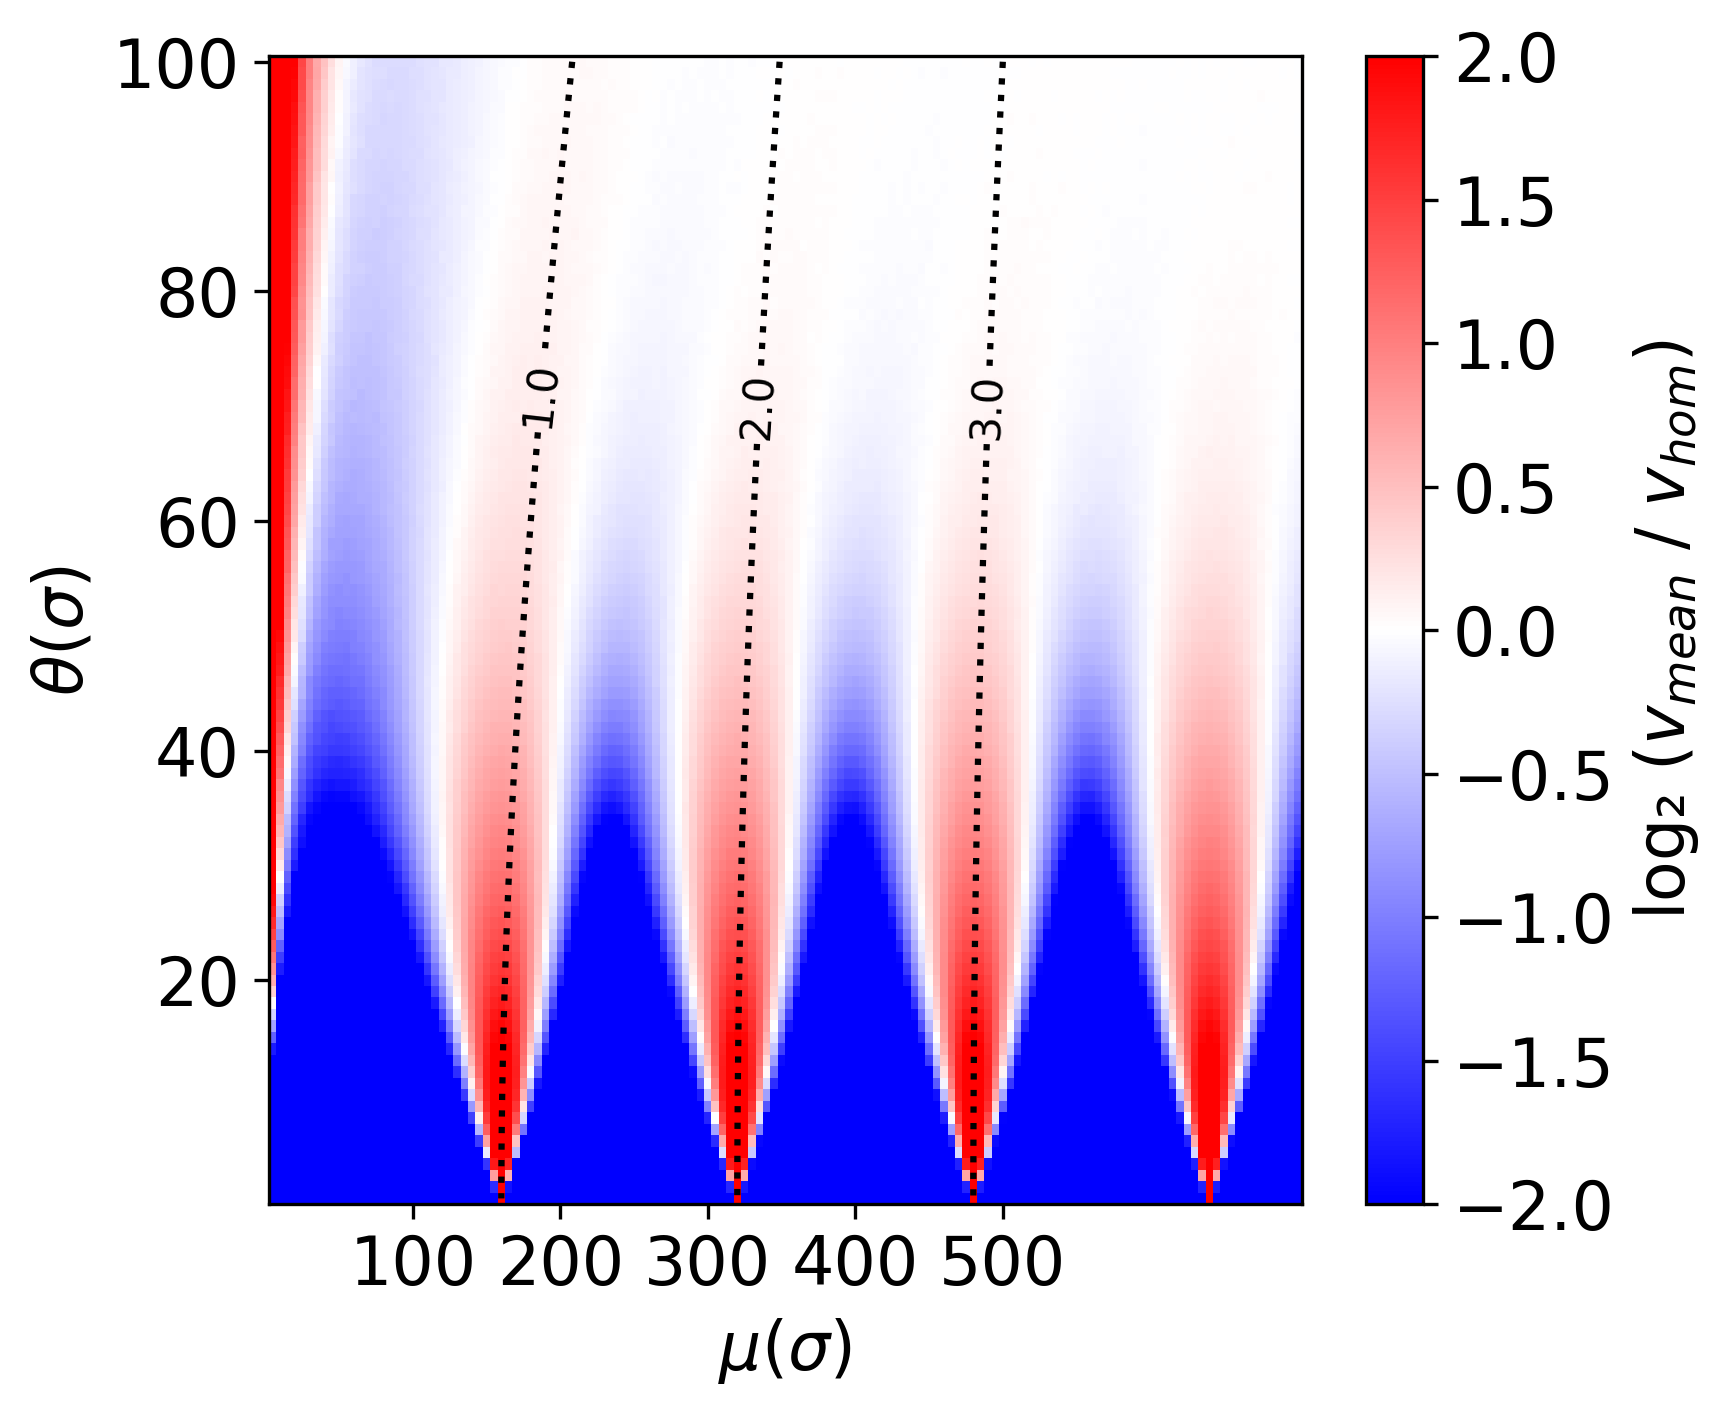

<Figure size 640x480 with 0 Axes>

In [10]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15"
)
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")
# points = [(160, 20), (160, 60), (240, 20), (240, 60)]

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
# color_positions = np.linspace(0.1, 0.9, len(points))
# color_list = [cmap(pos) for pos in color_positions]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=1,        # équivalent du `key` de l'ancien dict (premier idx = 0) # MAX 19 (homogen)
    speed_col="v_mean",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=True,
    title=False,
)

# for i, (mu_pt, theta_pt) in enumerate(points):
#     ax.scatter(
#         mu_pt,
#         theta_pt,
#         color=color_list[i],
#         s=100,              # taille du point
#         edgecolor="black",  # contour du point
#         zorder=10           # pour être au-dessus de la heatmap
#     )

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

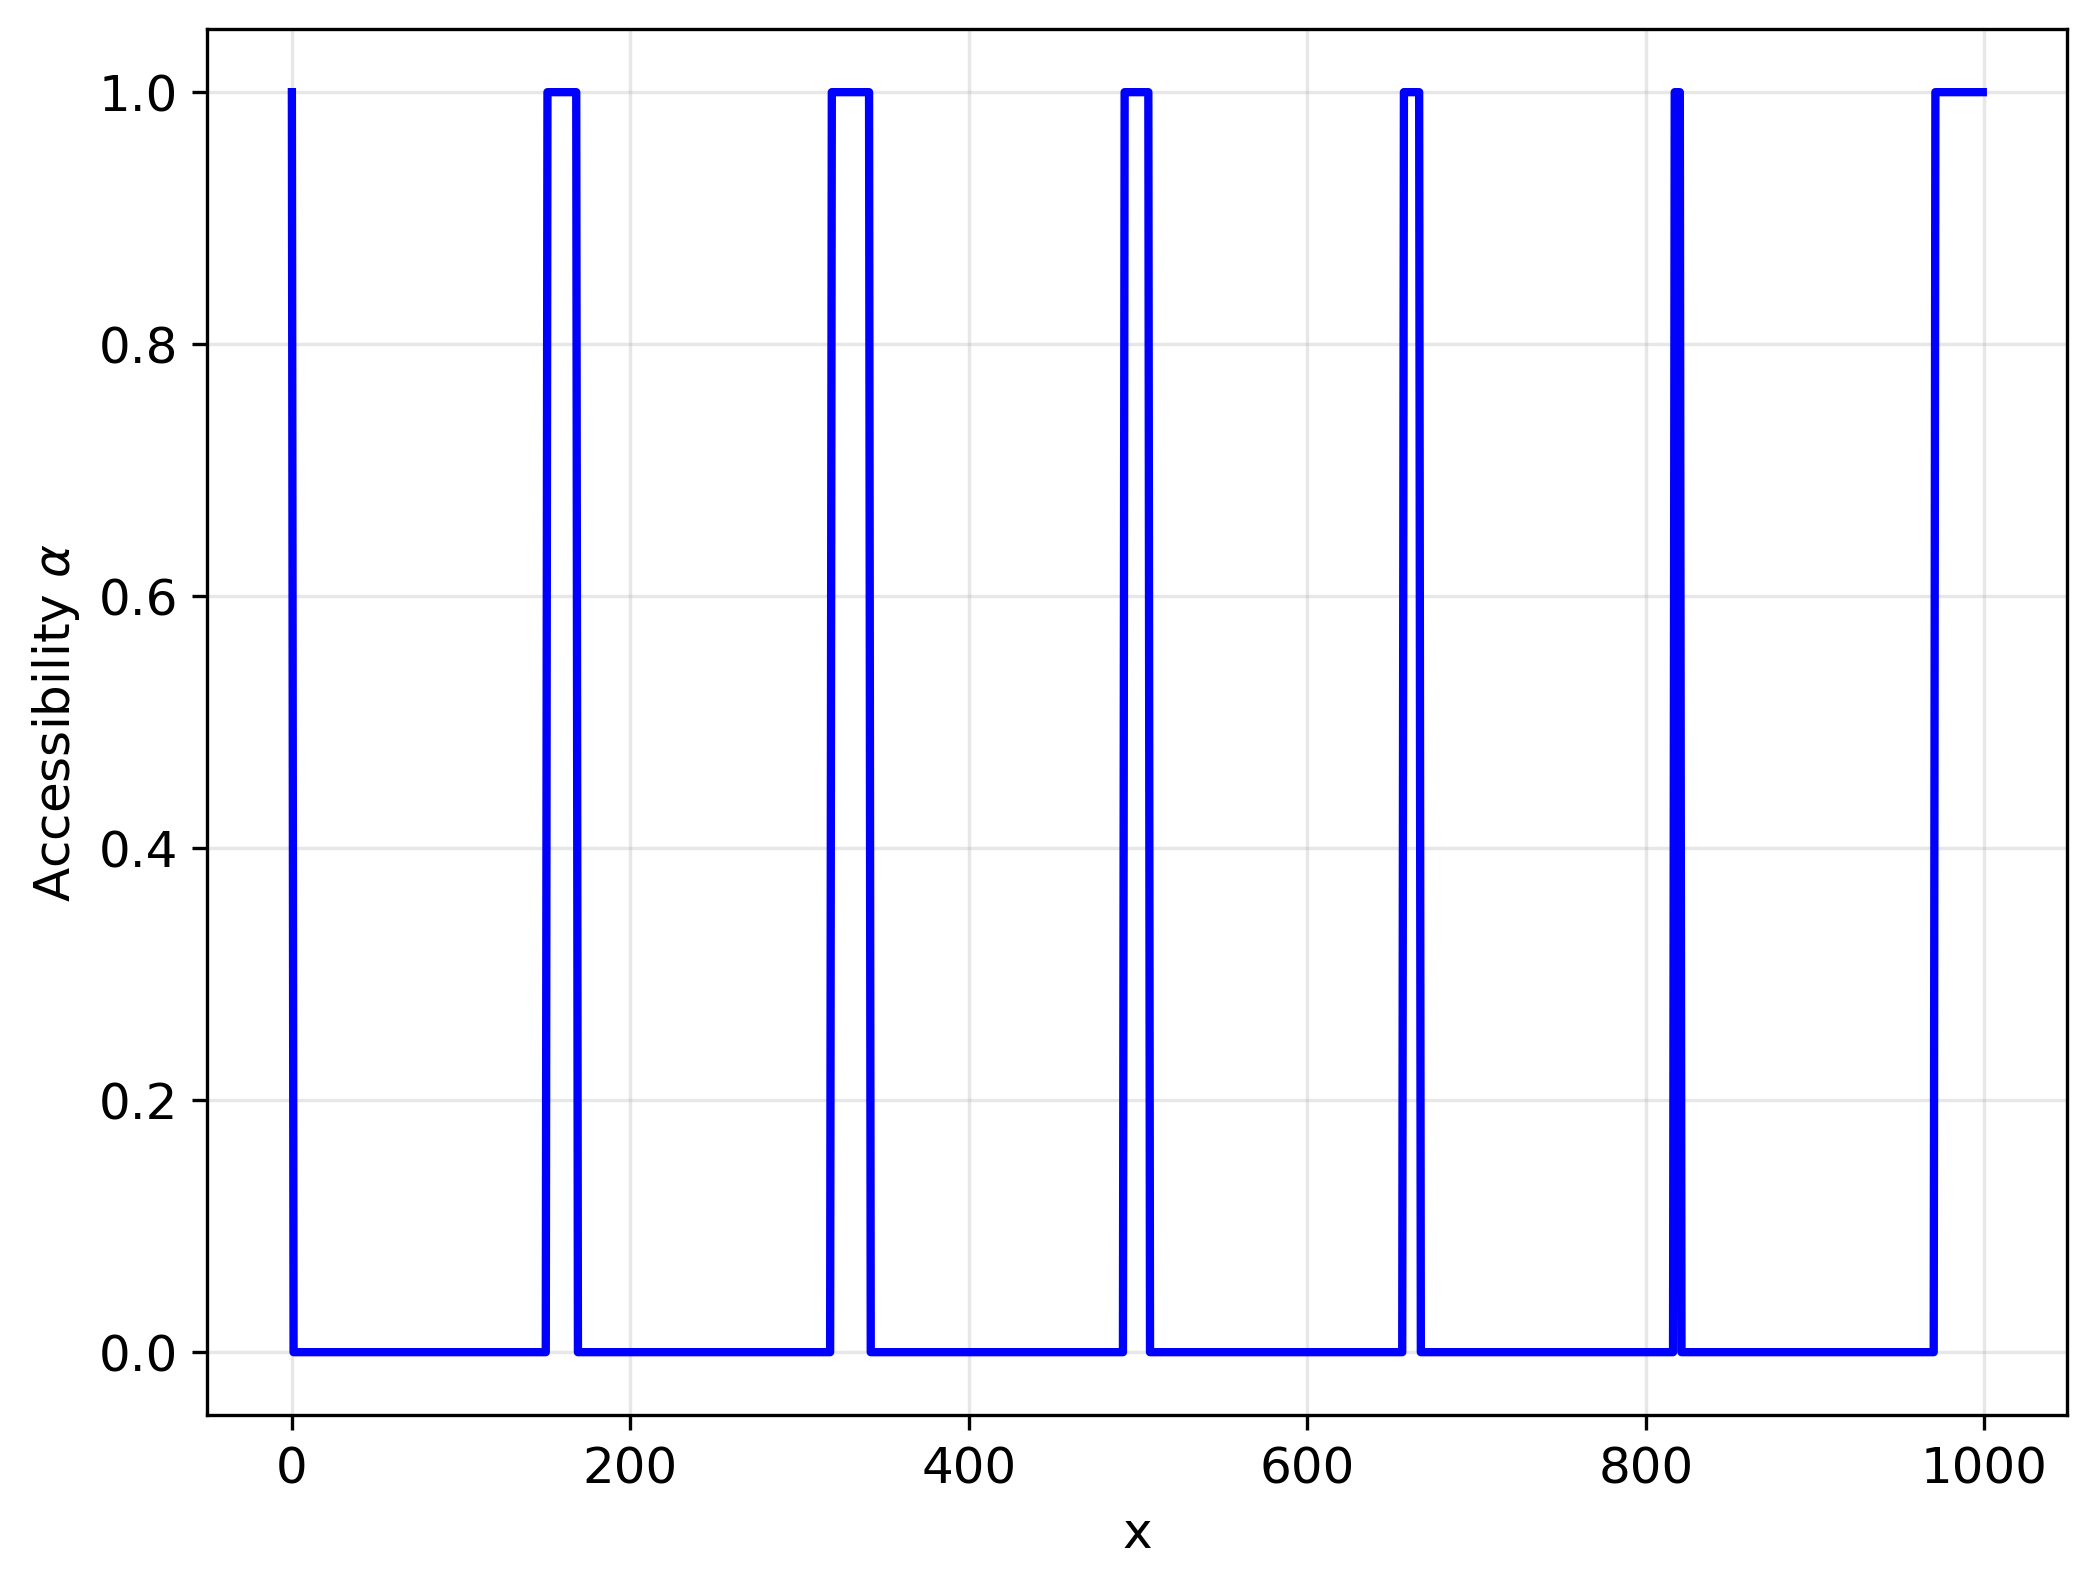

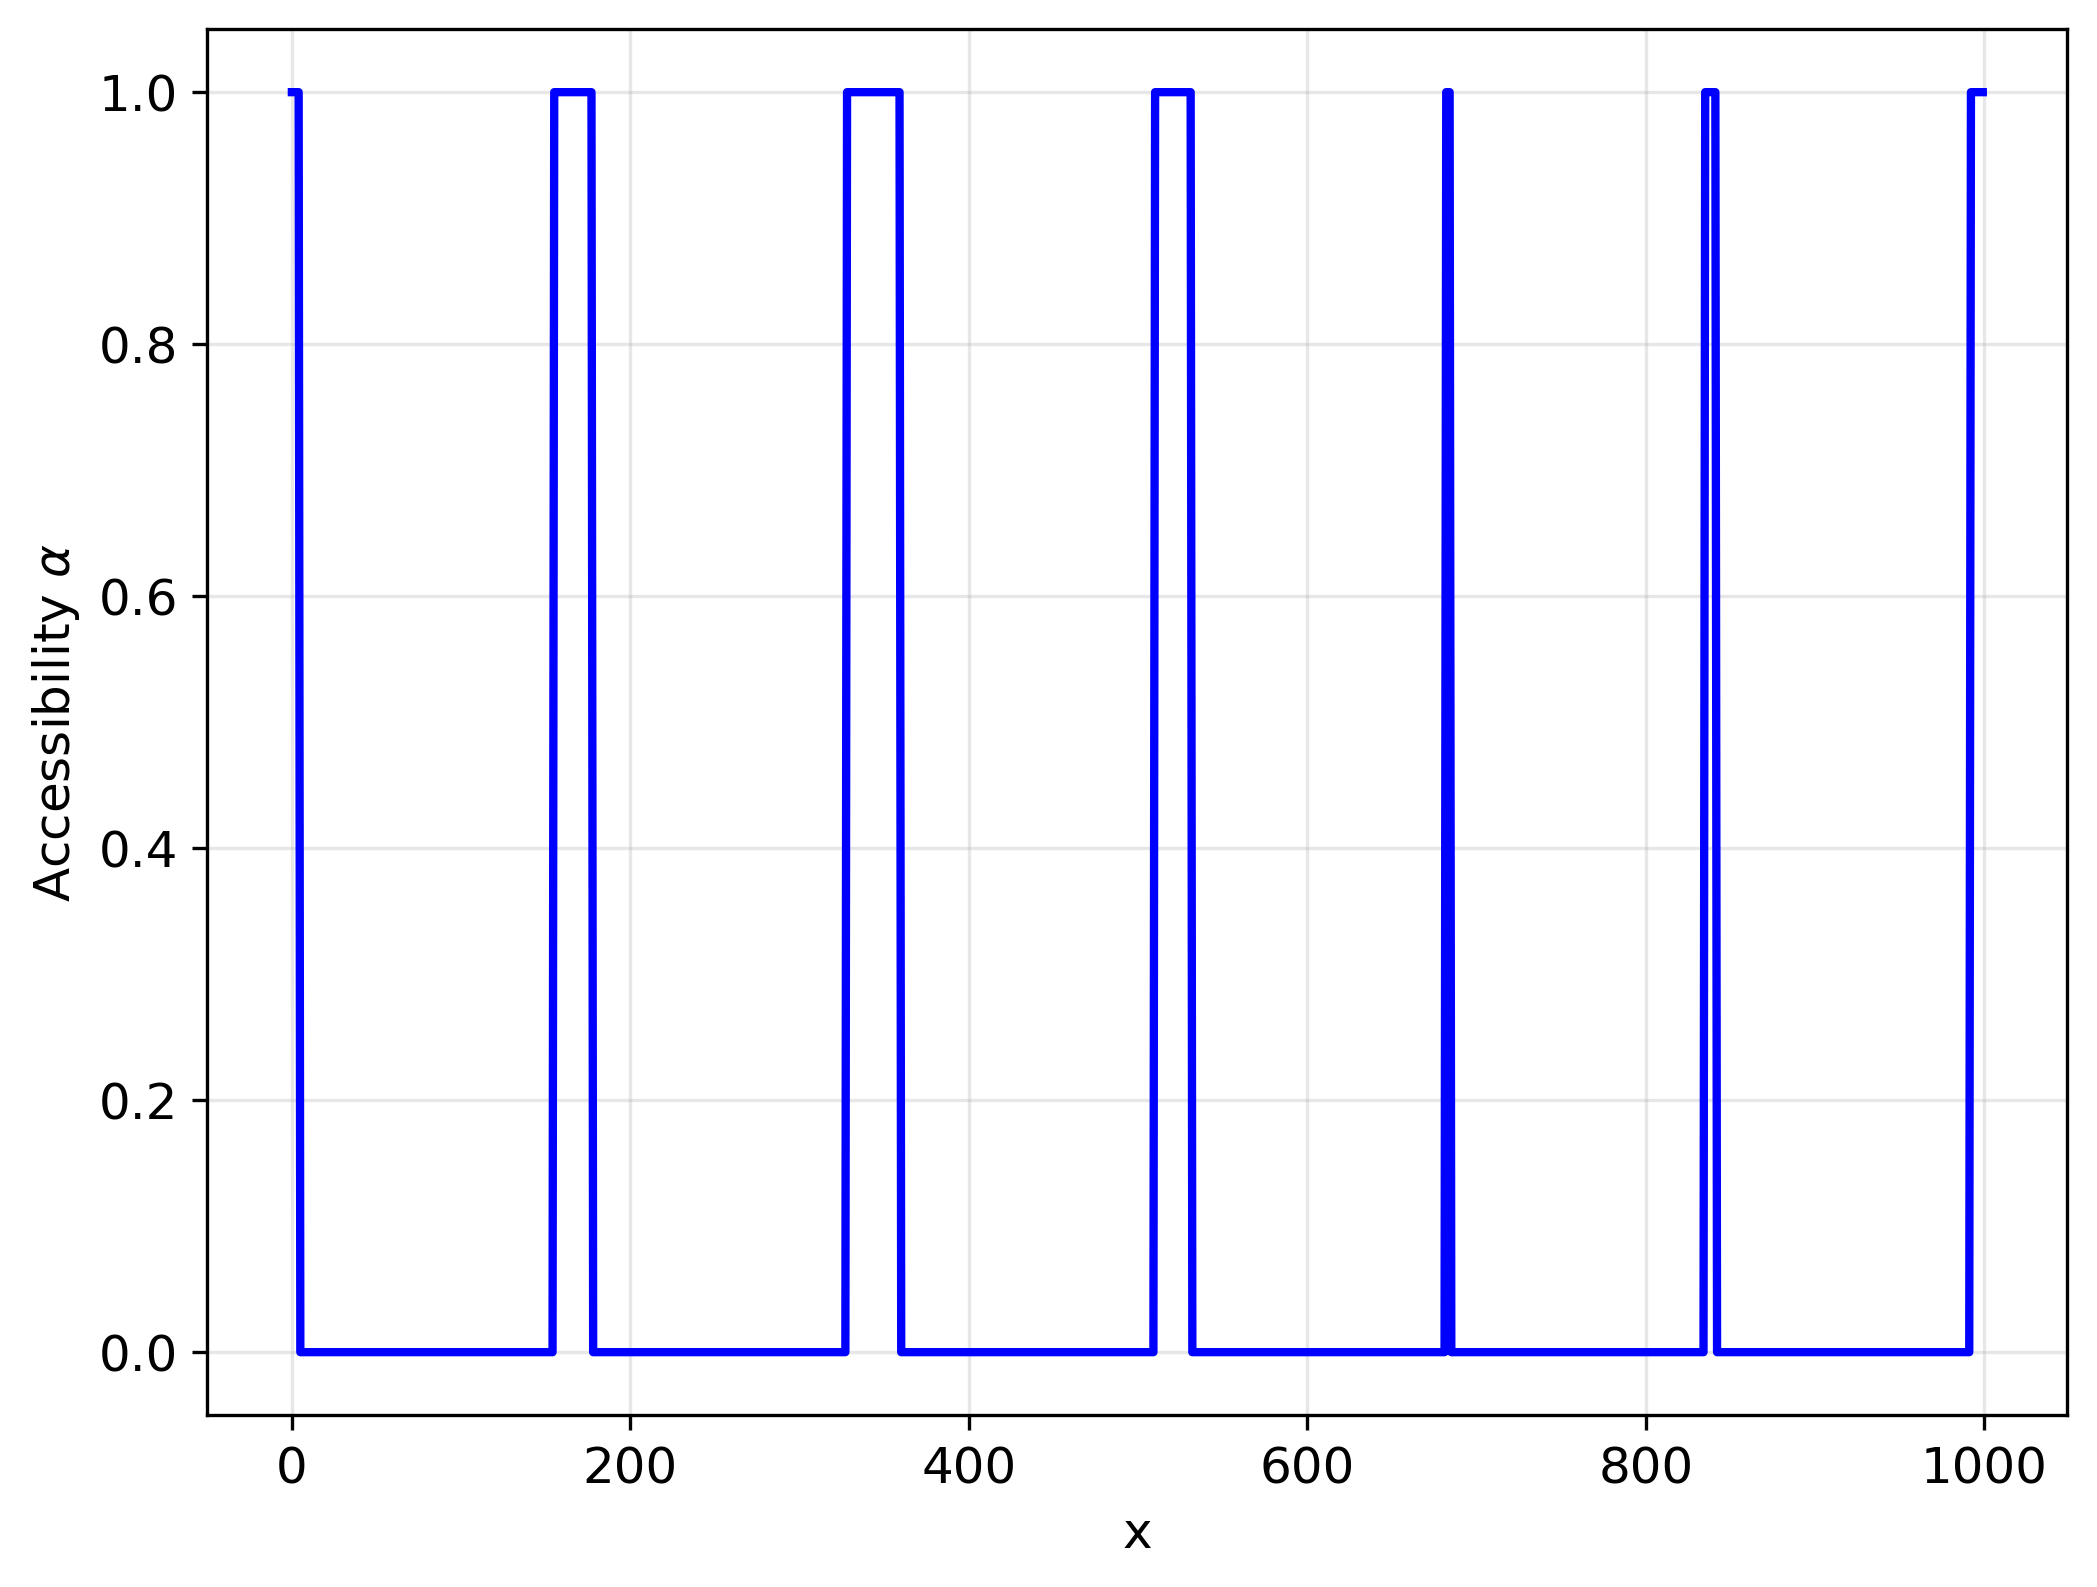

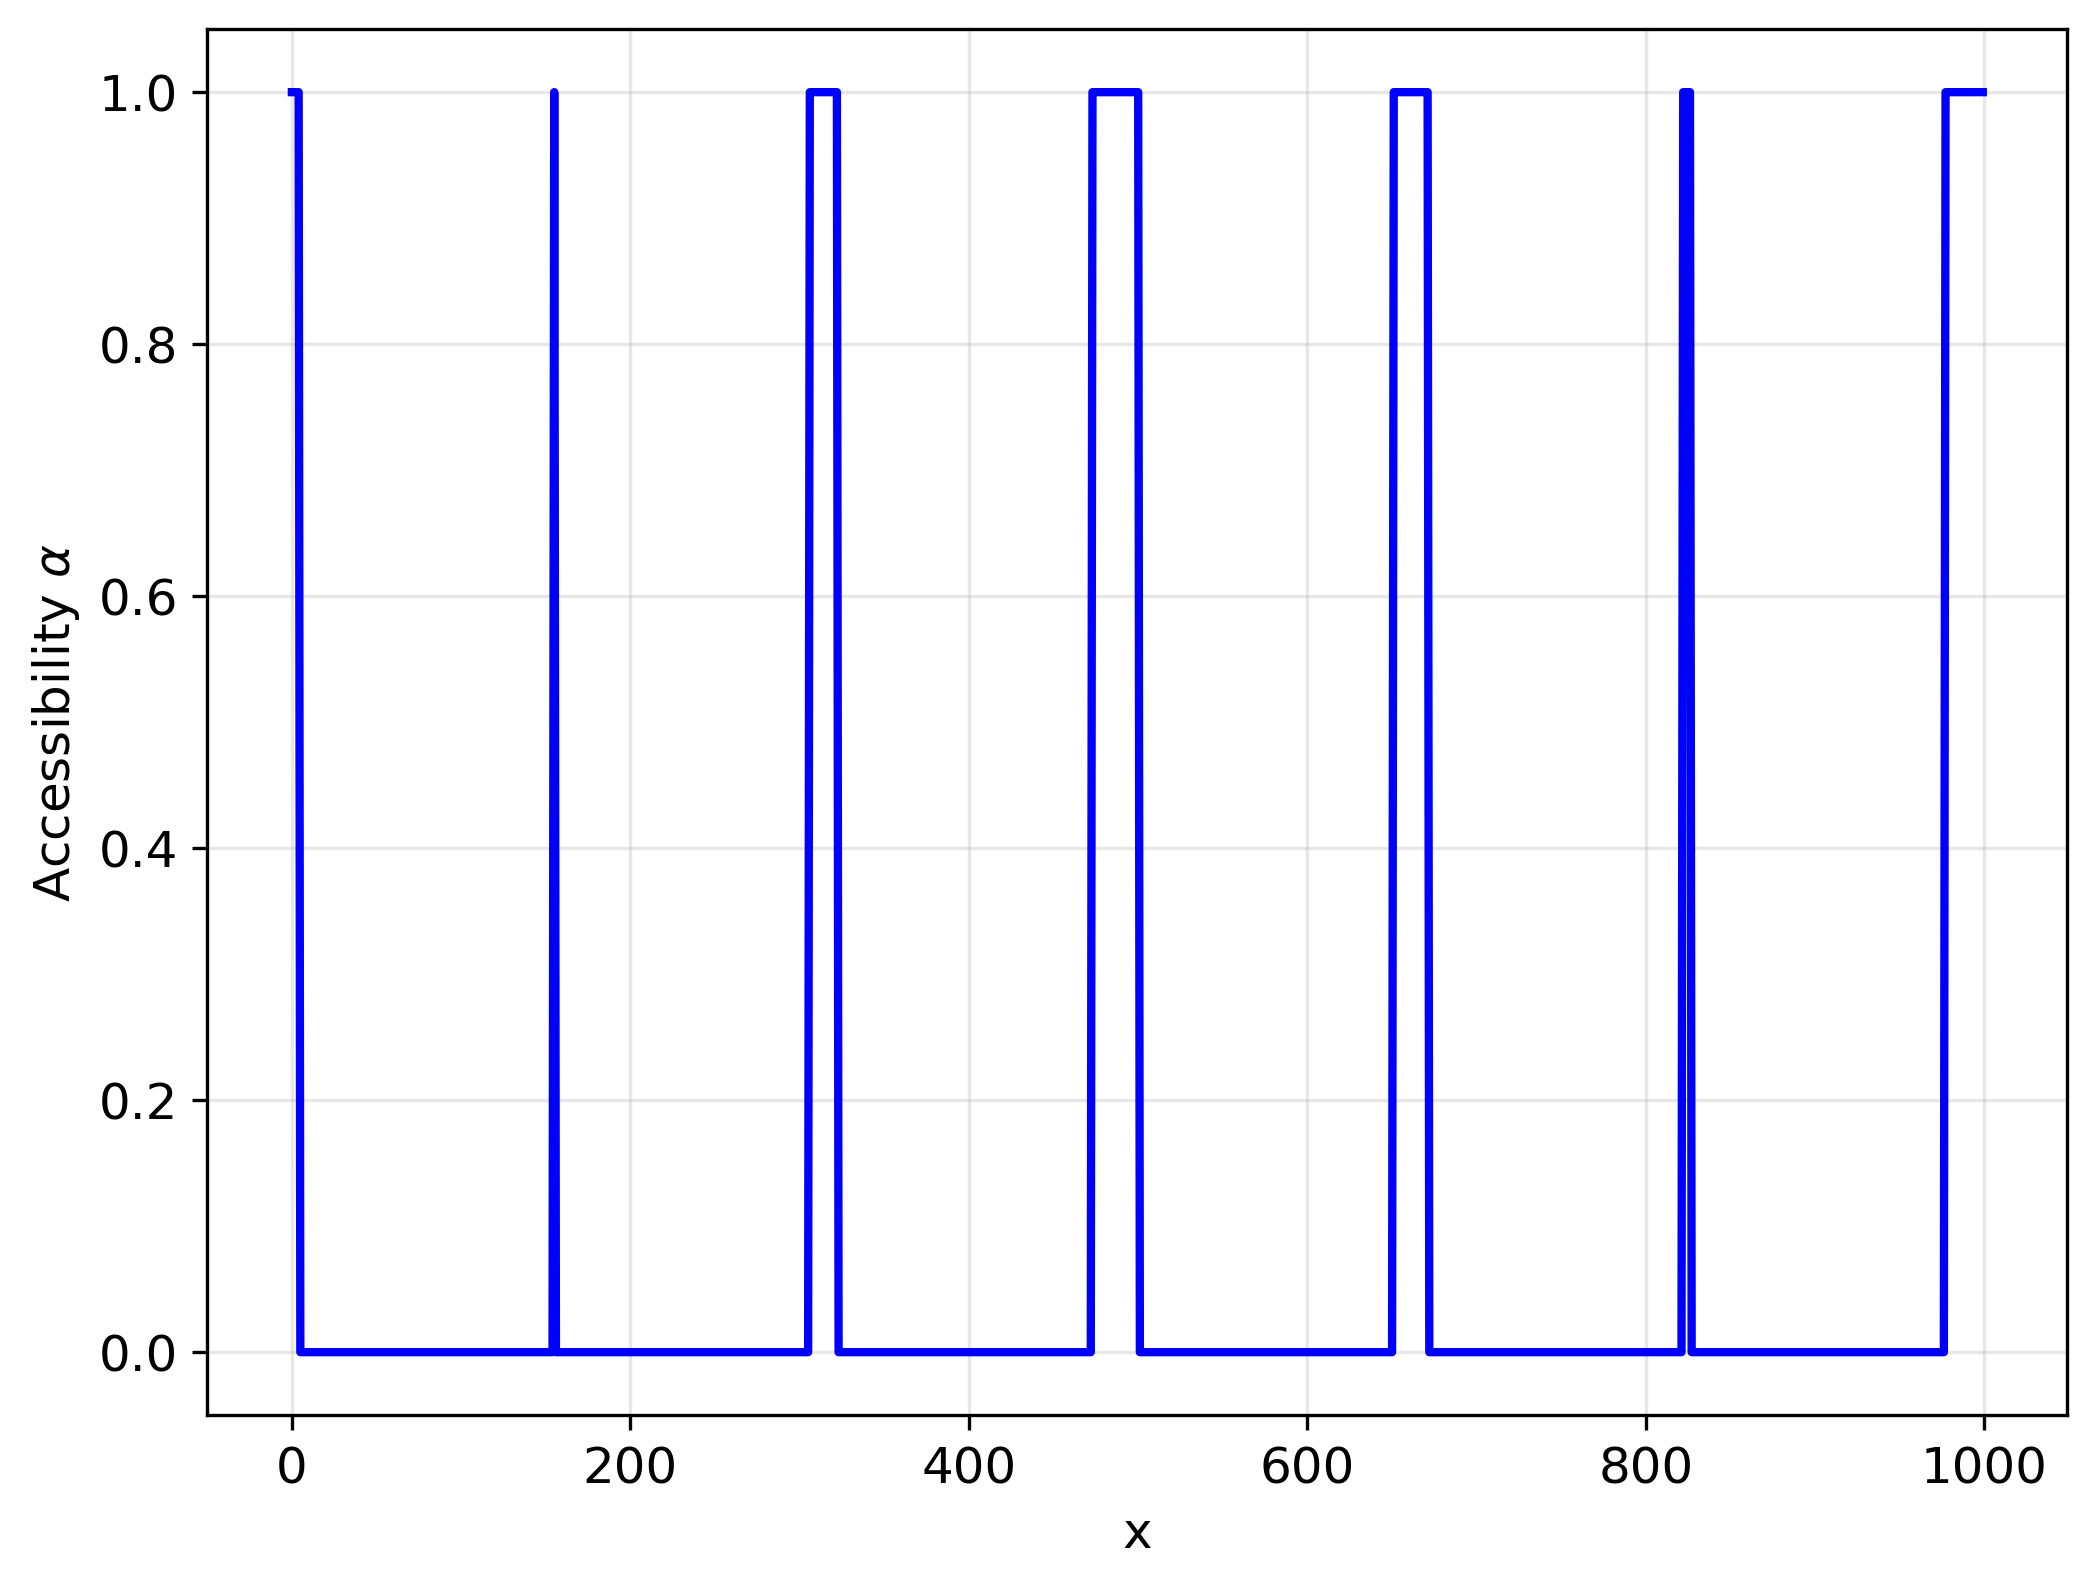

In [11]:
from nucleo.simulation.chromatin import alpha_random
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

for i in range (0,3):
    picture = alpha_random(params["s"], params["l"], 1, 0, 0, 1000, bps=1)
    plt.figure(figsize=(8, 6), dpi=300)
    plt.plot(picture, color="blue", linewidth=2.0)
    plt.xlabel("x")
    plt.ylabel(rf"Accessibility $\alpha$")
    plt.grid(True, alpha=0.30)
    plt.show()

Loading subfiles:  39%|███▊      | 74/192 [00:01<00:02, 46.73subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__29/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


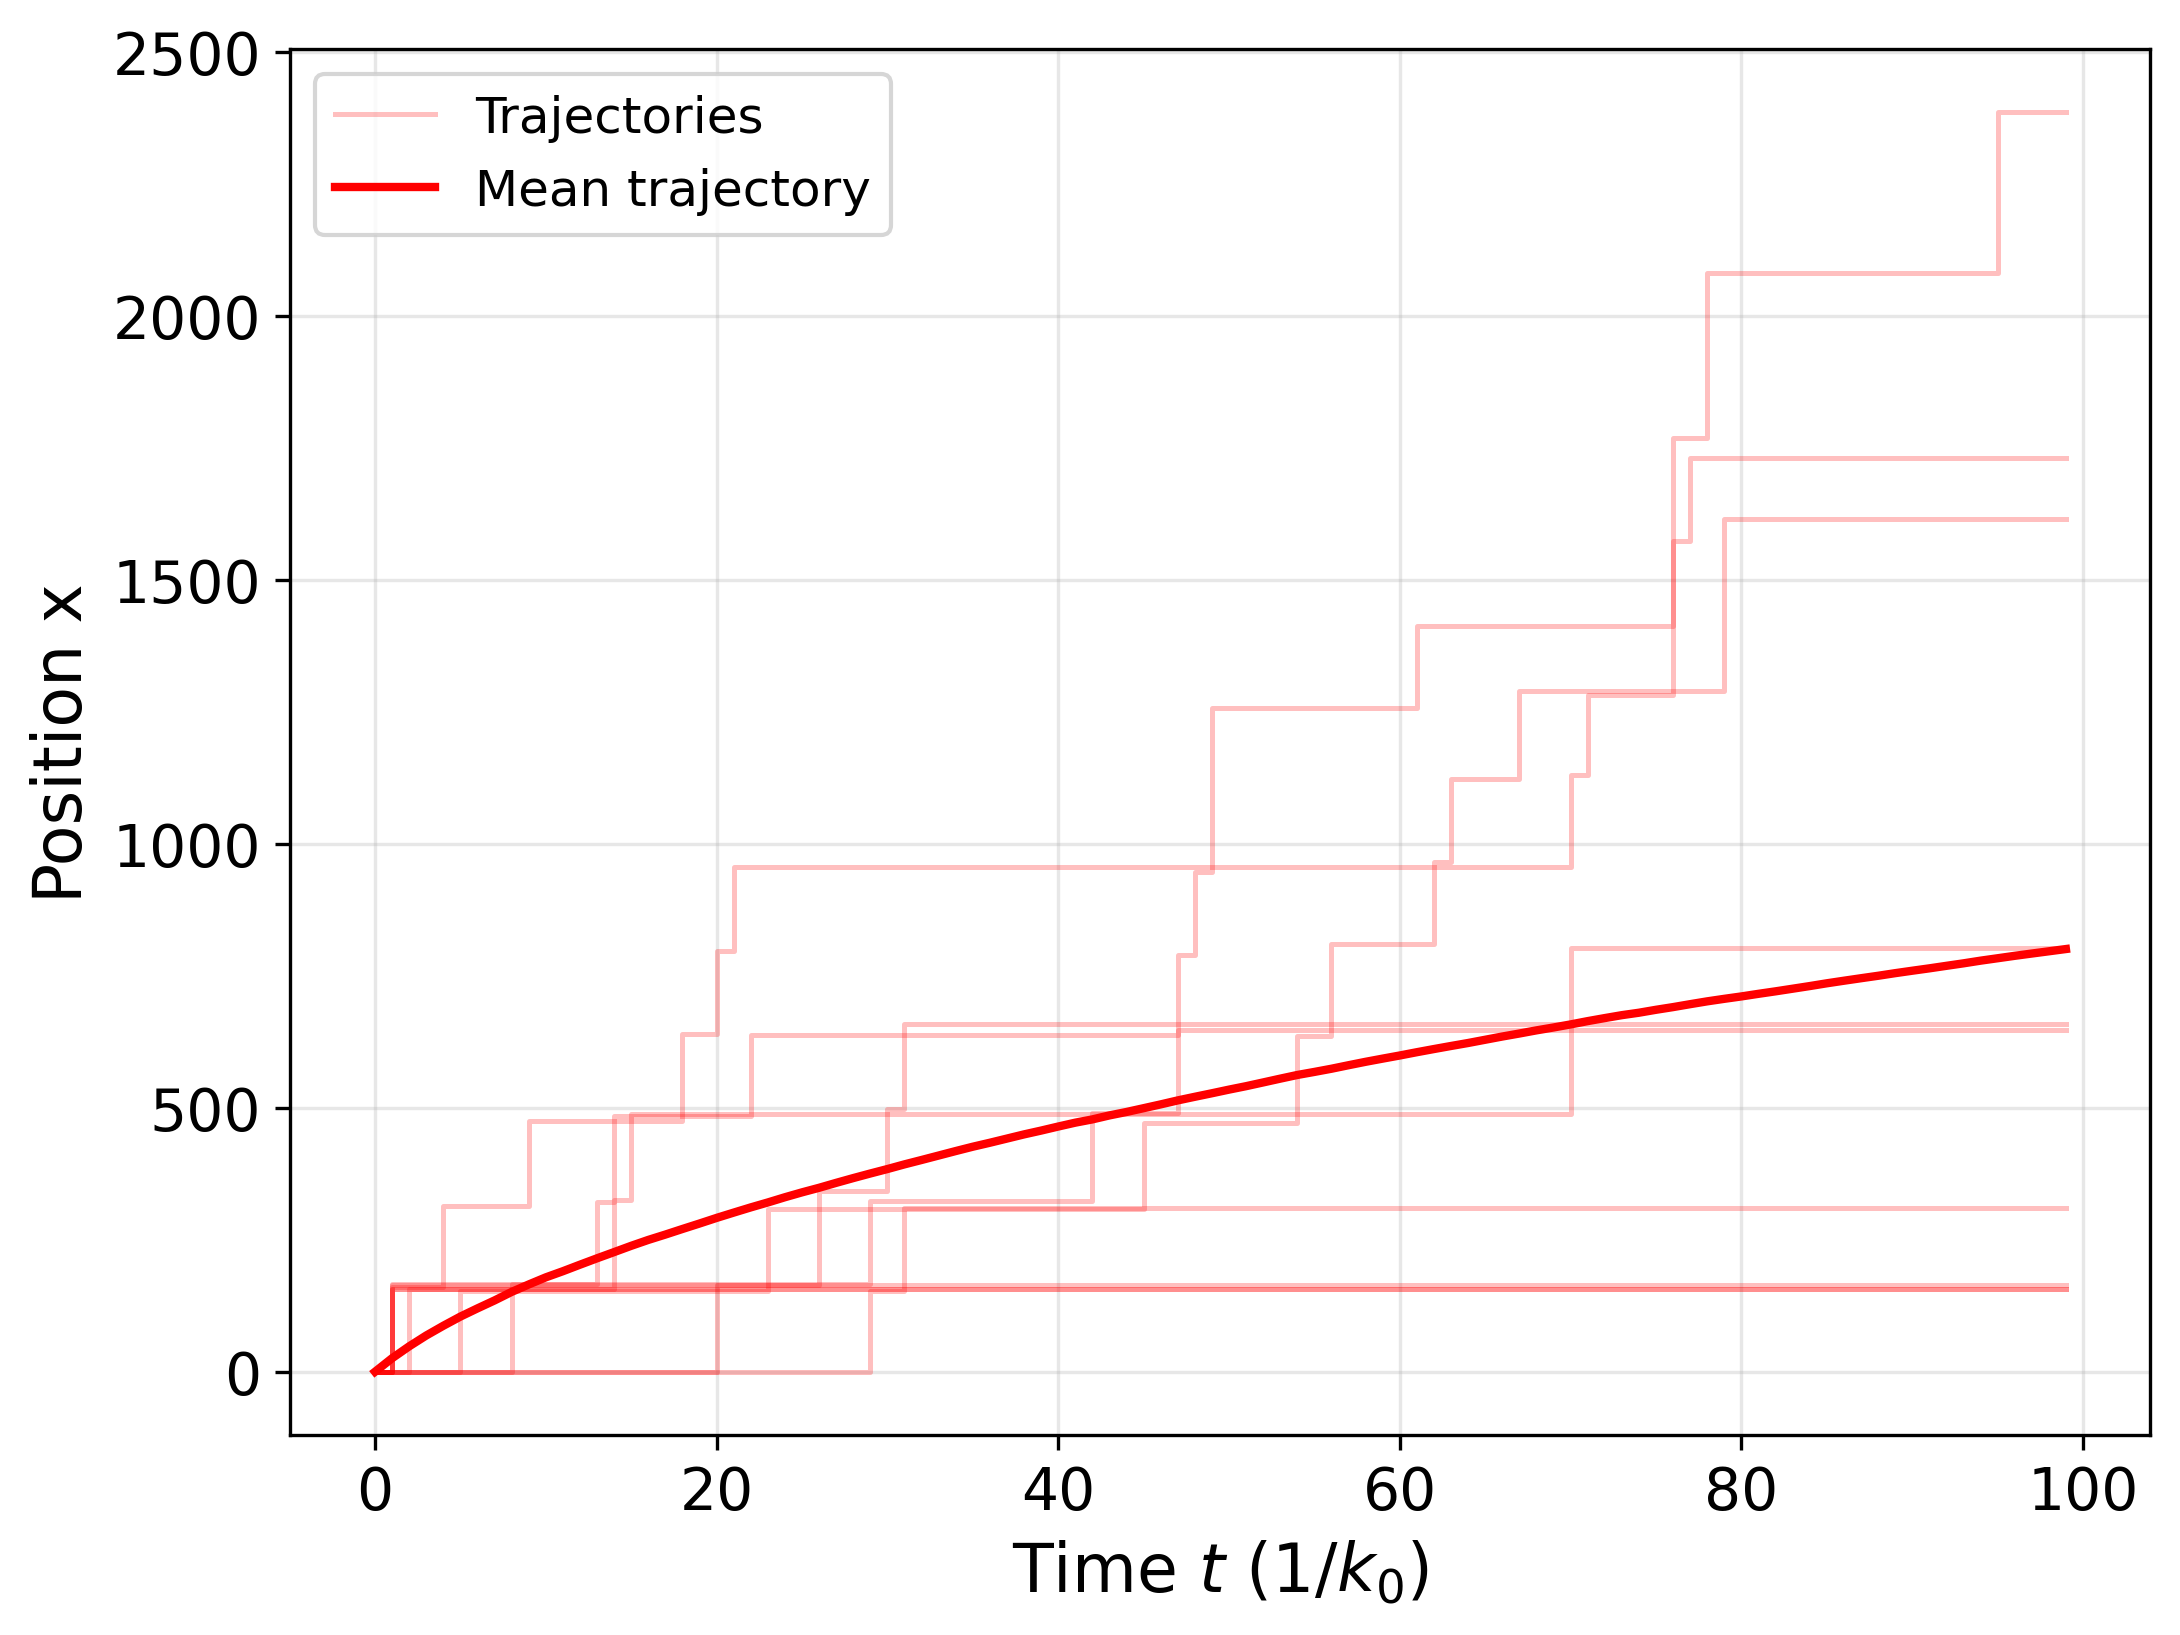

Loading subfiles:  37%|███▋      | 71/192 [00:01<00:02, 44.36subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__36/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=180__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=180__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


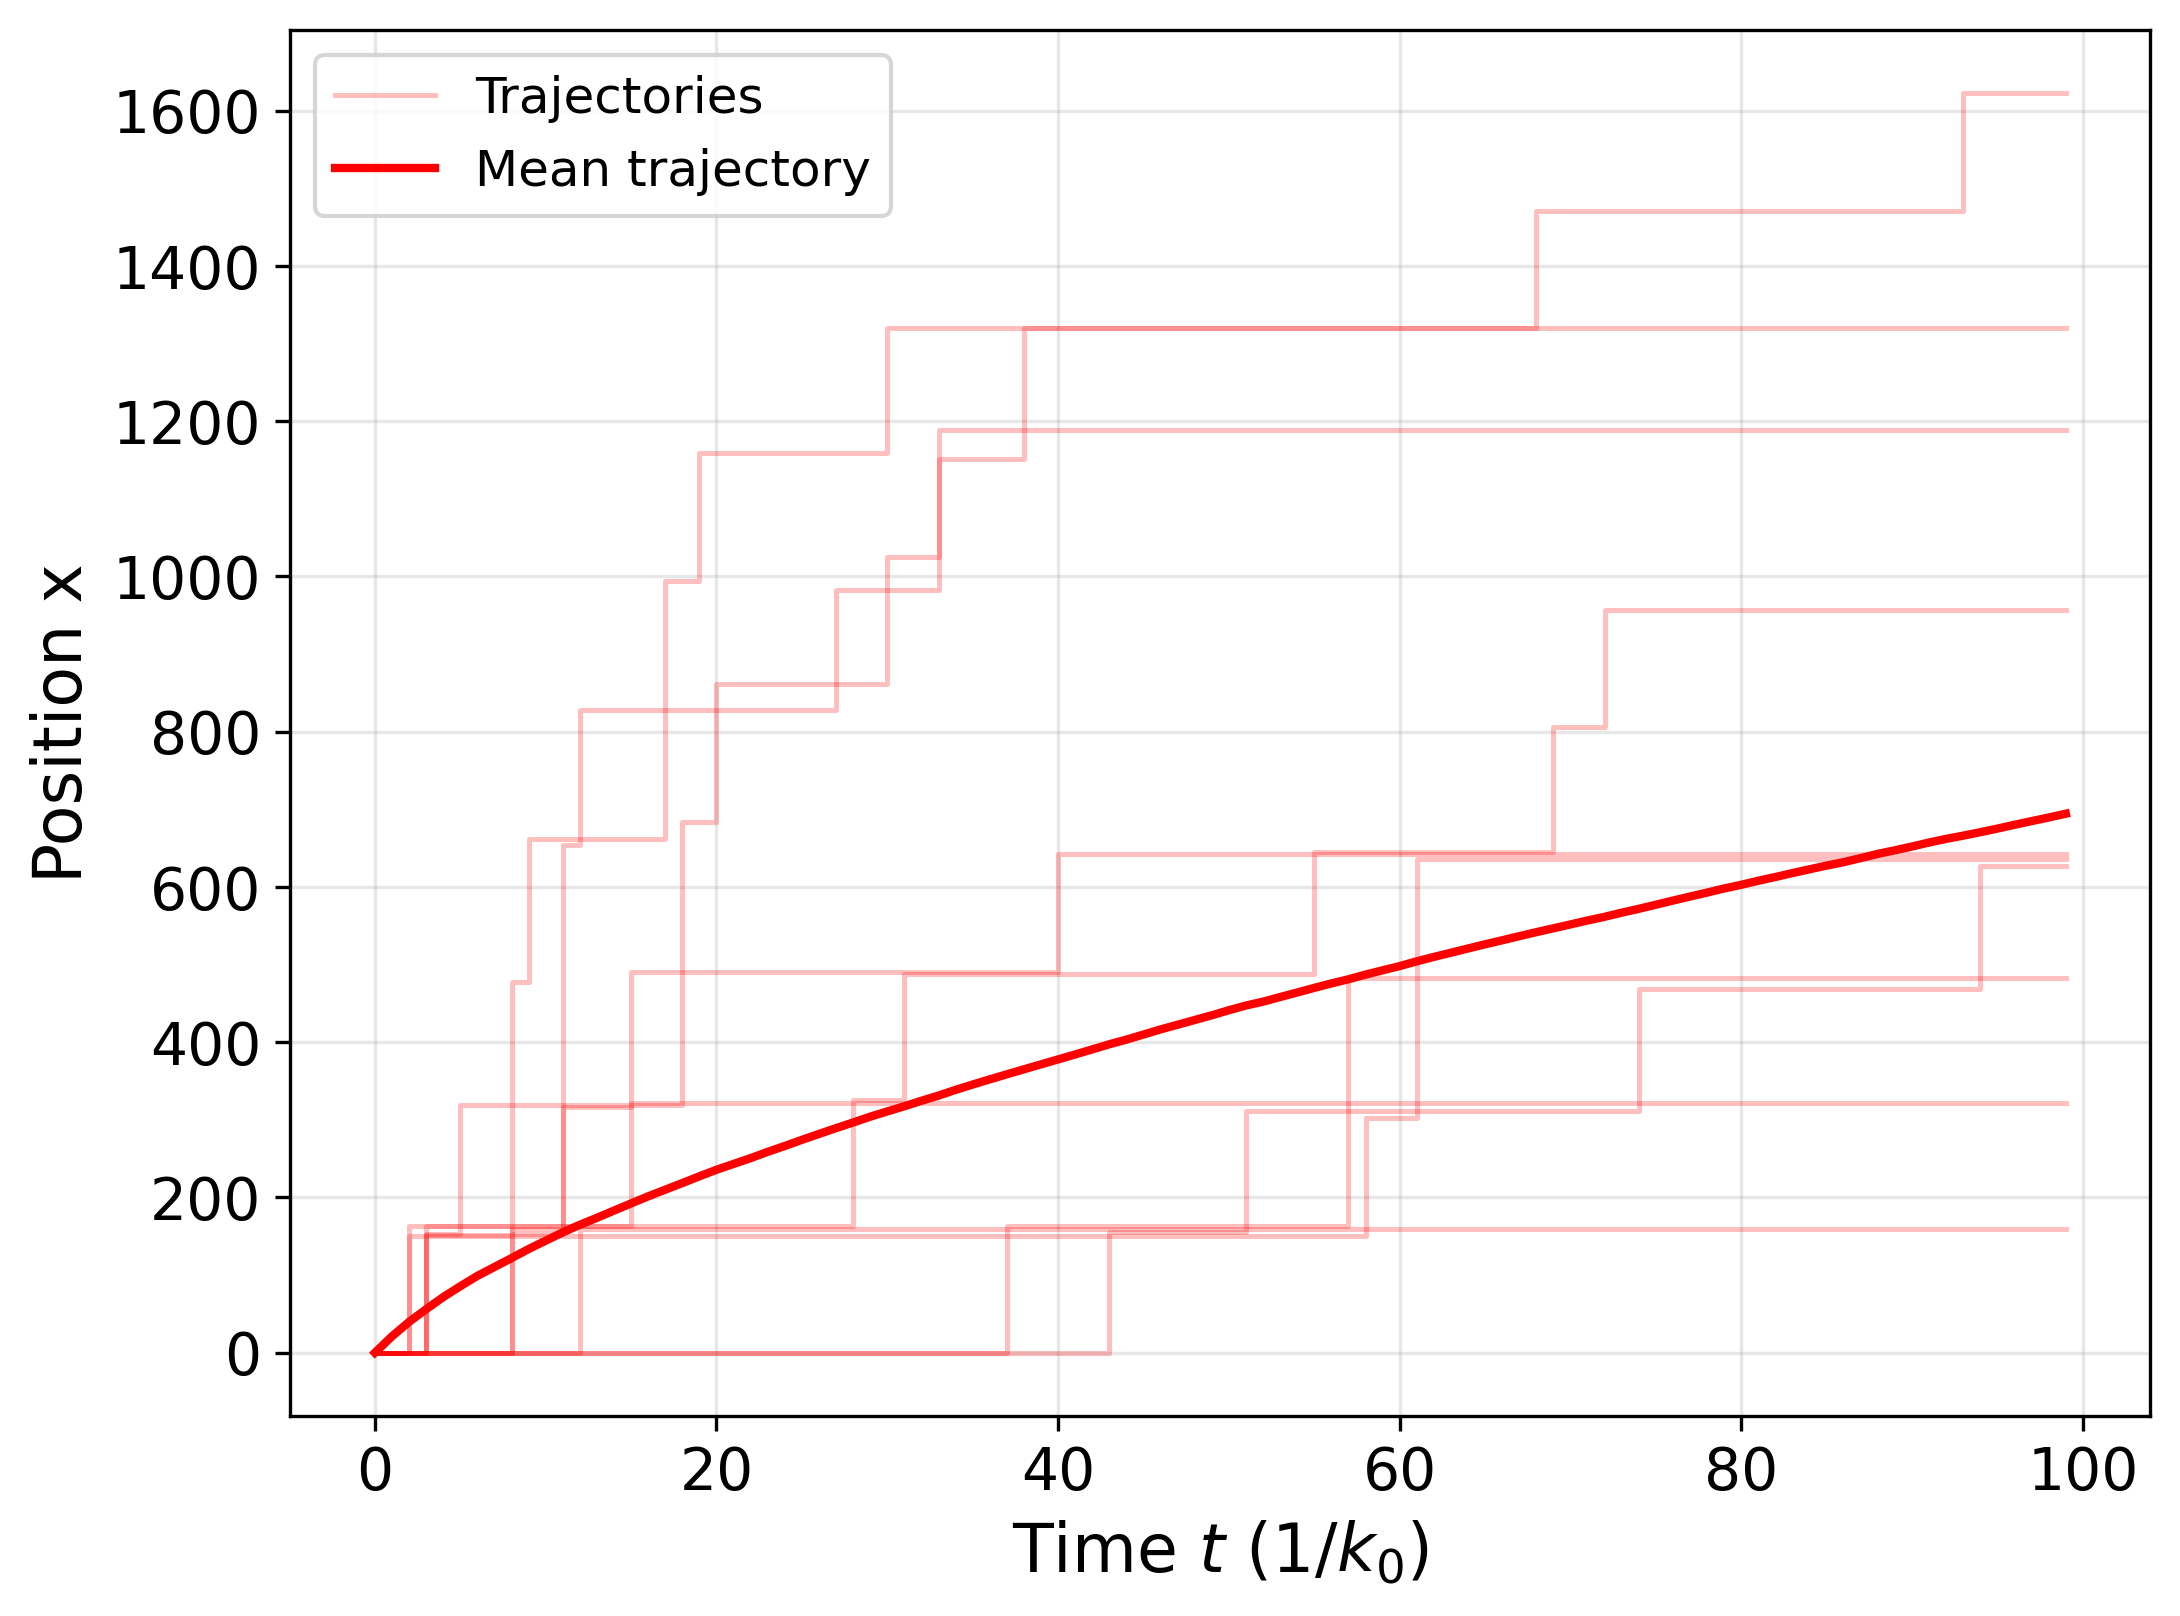

In [14]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)

results = df["results"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
plt.figure(figsize=(8, 6), dpi=300)
for i in range(10):
    plt.step(
        df["times"][0].to_numpy(),
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )
plt.plot(results_mean, color="red", linewidth=2.0, label="Mean trajectory")
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 180,
    "theta": 20,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)
results = df["results"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
plt.figure(figsize=(8, 6), dpi=300)
for i in range(10):
    plt.step(
        df["times"][0].to_numpy(),
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )
plt.plot(results_mean, color="red", linewidth=2.0, label="Mean trajectory")
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_138058/4256819532.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


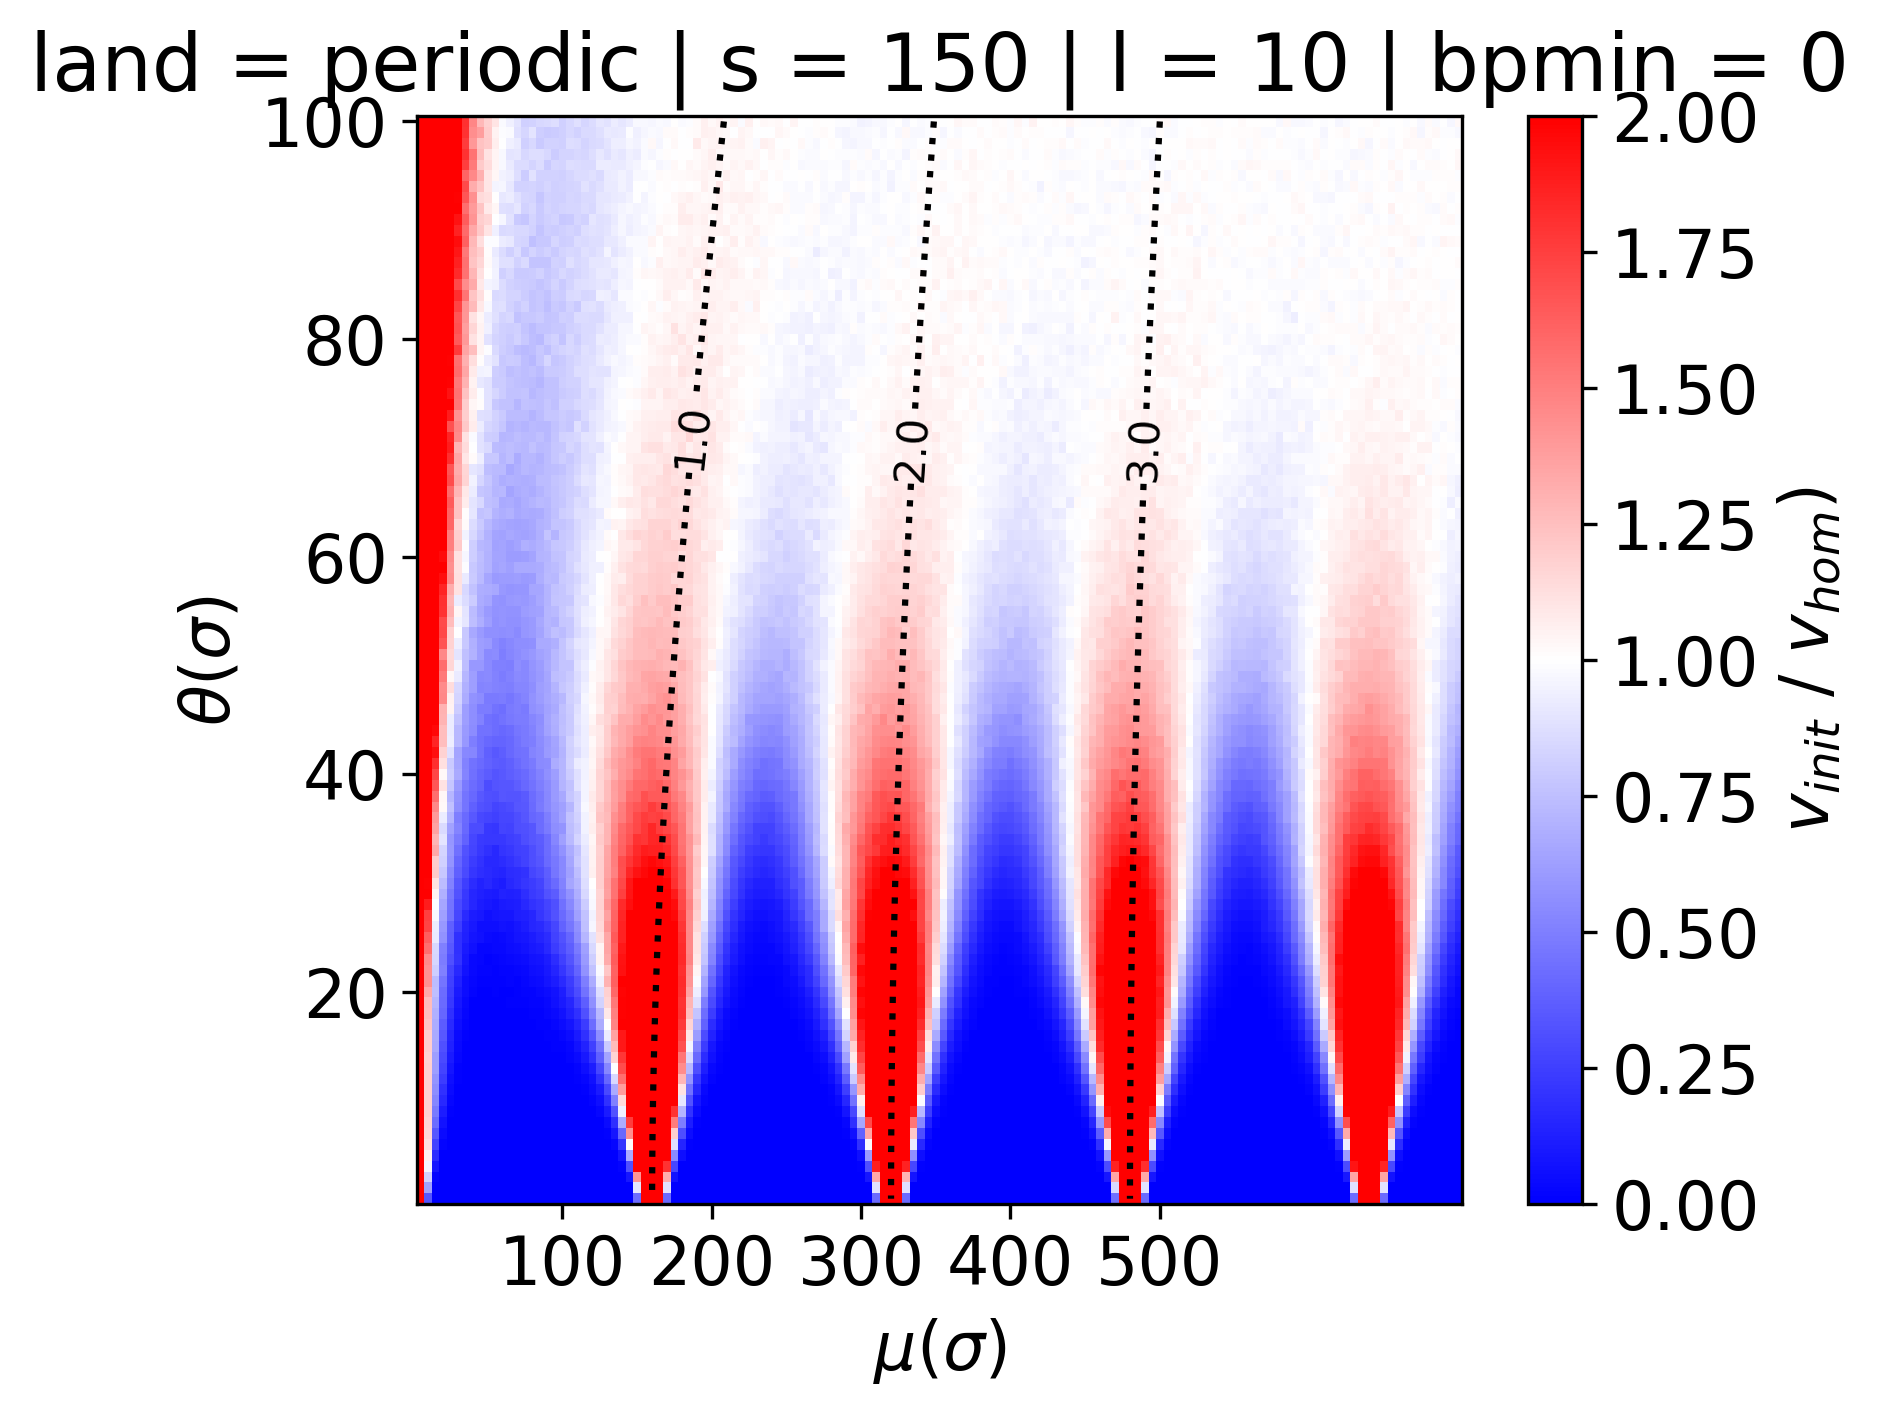

In [15]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nucleo.io.plots_2D import plot_one_heatmap_from_df
plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15"
)
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=1,        # équivalent du `key` de l'ancien dict (premier idx = 0) # MAX 19 (homogen)
    speed_col="vf",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=False,
    dashed_line=True,
    title=True,
)

plt.tight_layout()
plt.show()

Loading subfiles:  39%|███▊      | 74/192 [00:01<00:02, 46.04subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__29/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=10__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 'bpmin', 'mu', 'theta', 'alphaf', 'alphao', 'beta', 'rcapt', 'rrest', 'alphac', 'alphad', 'alphar', 'krel', 'Kp', 'Kz', 'c_linker', 'c_nucleo', 'Lmin', 'Lmax', 'bps', 'origin', 'tmax', 'dt', 'times', 'binx', 'bint', 'bound_l', 'bound_m', 'bound_h', 'alpha0', 'nt', 's_mean', 'l_mean', 'alpha_mean_a', 'alpha_mean_v', 'alpha_me

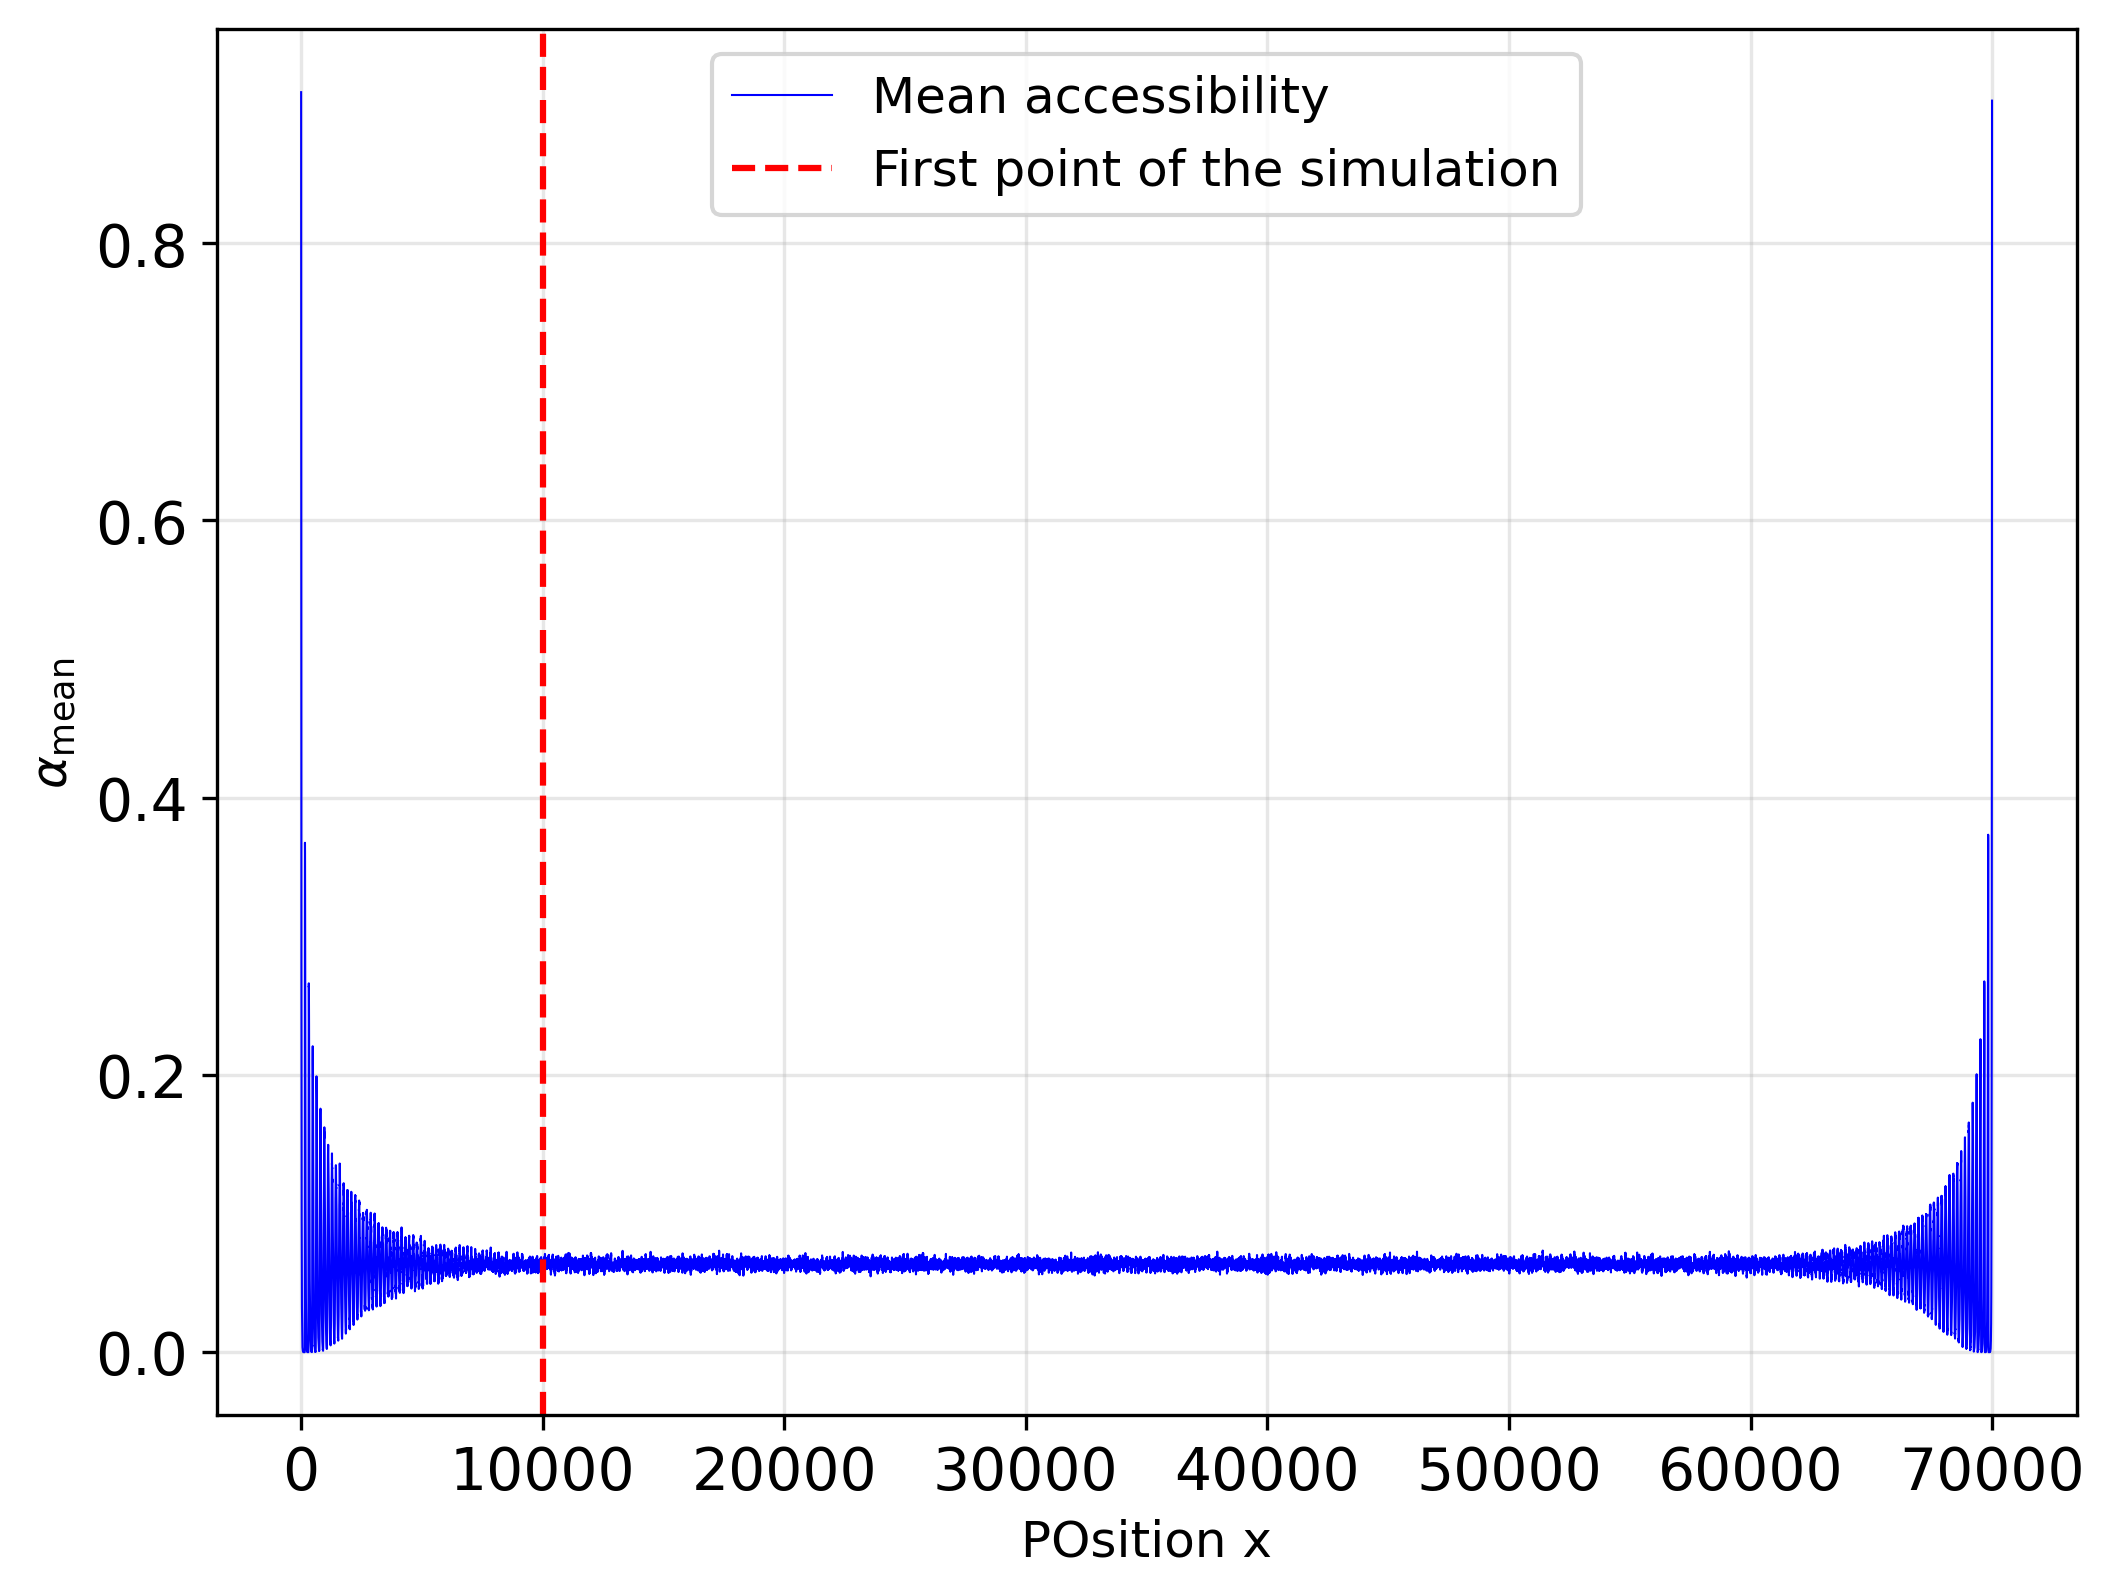

In [16]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)
print(df.columns)

alpha_mean_a = df["alpha_mean_a"][0].to_numpy()

plt.figure(figsize=(8, 6), dpi=300)
plt.plot(
    alpha_mean_a,
    color="blue",
    alpha=1,
    linewidth=0.50,
    label="Mean accessibility"
)

plt.axvline(x=10000, color='red', linestyle='--', linewidth=1.5, label='First point of the simulation')

plt.xlabel(r"POsition x")
plt.ylabel(r"$\alpha_{\text{mean}}$")
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

/tmp/ipykernel_138058/679864615.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


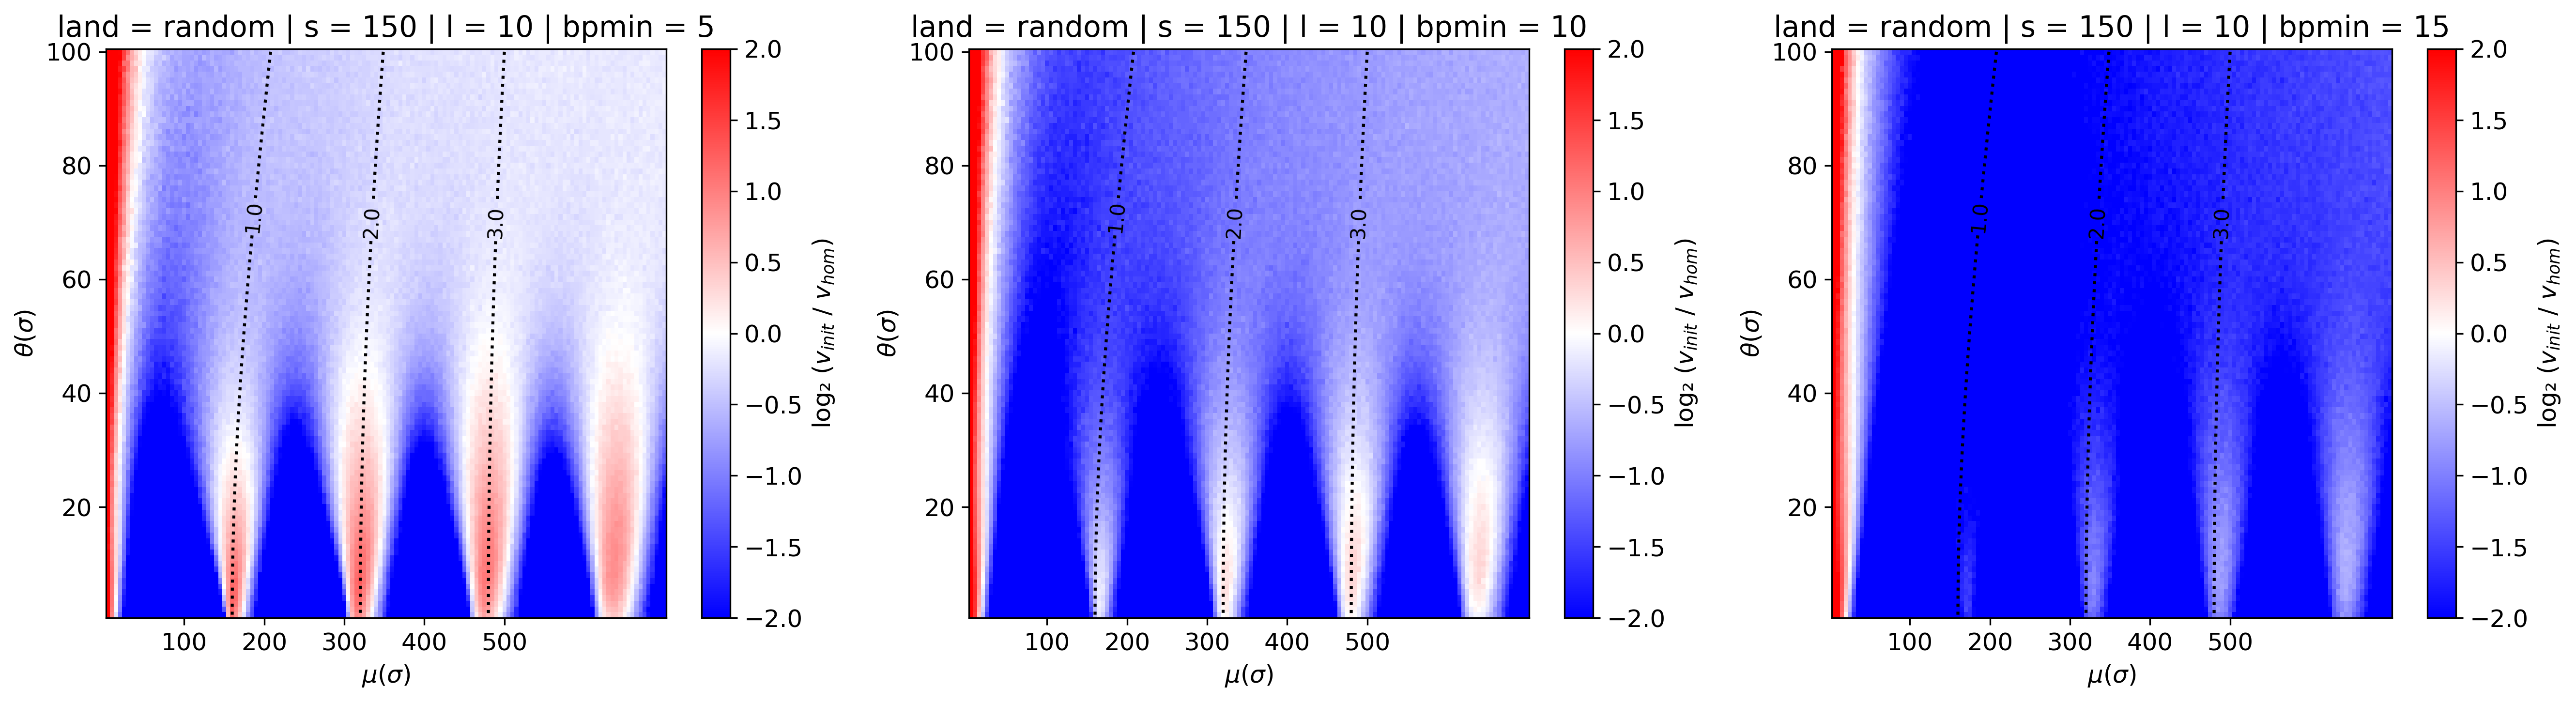

In [17]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nucleo.io.plots_2D import plot_one_heatmap_from_df
plt.rcParams["font.size"] = 12

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15"
)
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")

# ── Grille de plots pour les configs 1 à 9 ────────────────────────────────────
config_indices = list(range(16,19))  # 1 à 9 inclus
n_configs = len(config_indices)

nrows, ncols = 1, 3  # 9 cases pour 9 configs
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), dpi=300)
axes = axes.flatten()

for ax, config_idx in zip(axes, config_indices):
    plot_one_heatmap_from_df(
        heatmaps_df,
        config_idx=config_idx,
        speed_col="vf",
        ax=ax,
        type_of_data="norm_th",
        plot_log2=True,
        dashed_line=True,
        title=True,
    )

# Cacher les axes en trop s'il y en a (pas le cas ici avec 9/9)
for ax in axes[n_configs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [4]:
import numpy as np

Nk = 1e8 / 300
print(f"Number of Kuhn lengths: {Nk:.2e}")

rg = np.sqrt(Nk * (100e-9)**2 / 6)
print(f"Radius of gyration: {rg:.2e} m")

Number of Kuhn lengths: 3.33e+05
Radius of gyration: 2.36e-05 m


Loading subfiles:   5%|▌         | 10/192 [00:00<00:06, 26.12subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__19/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 160$, $\theta = 20$


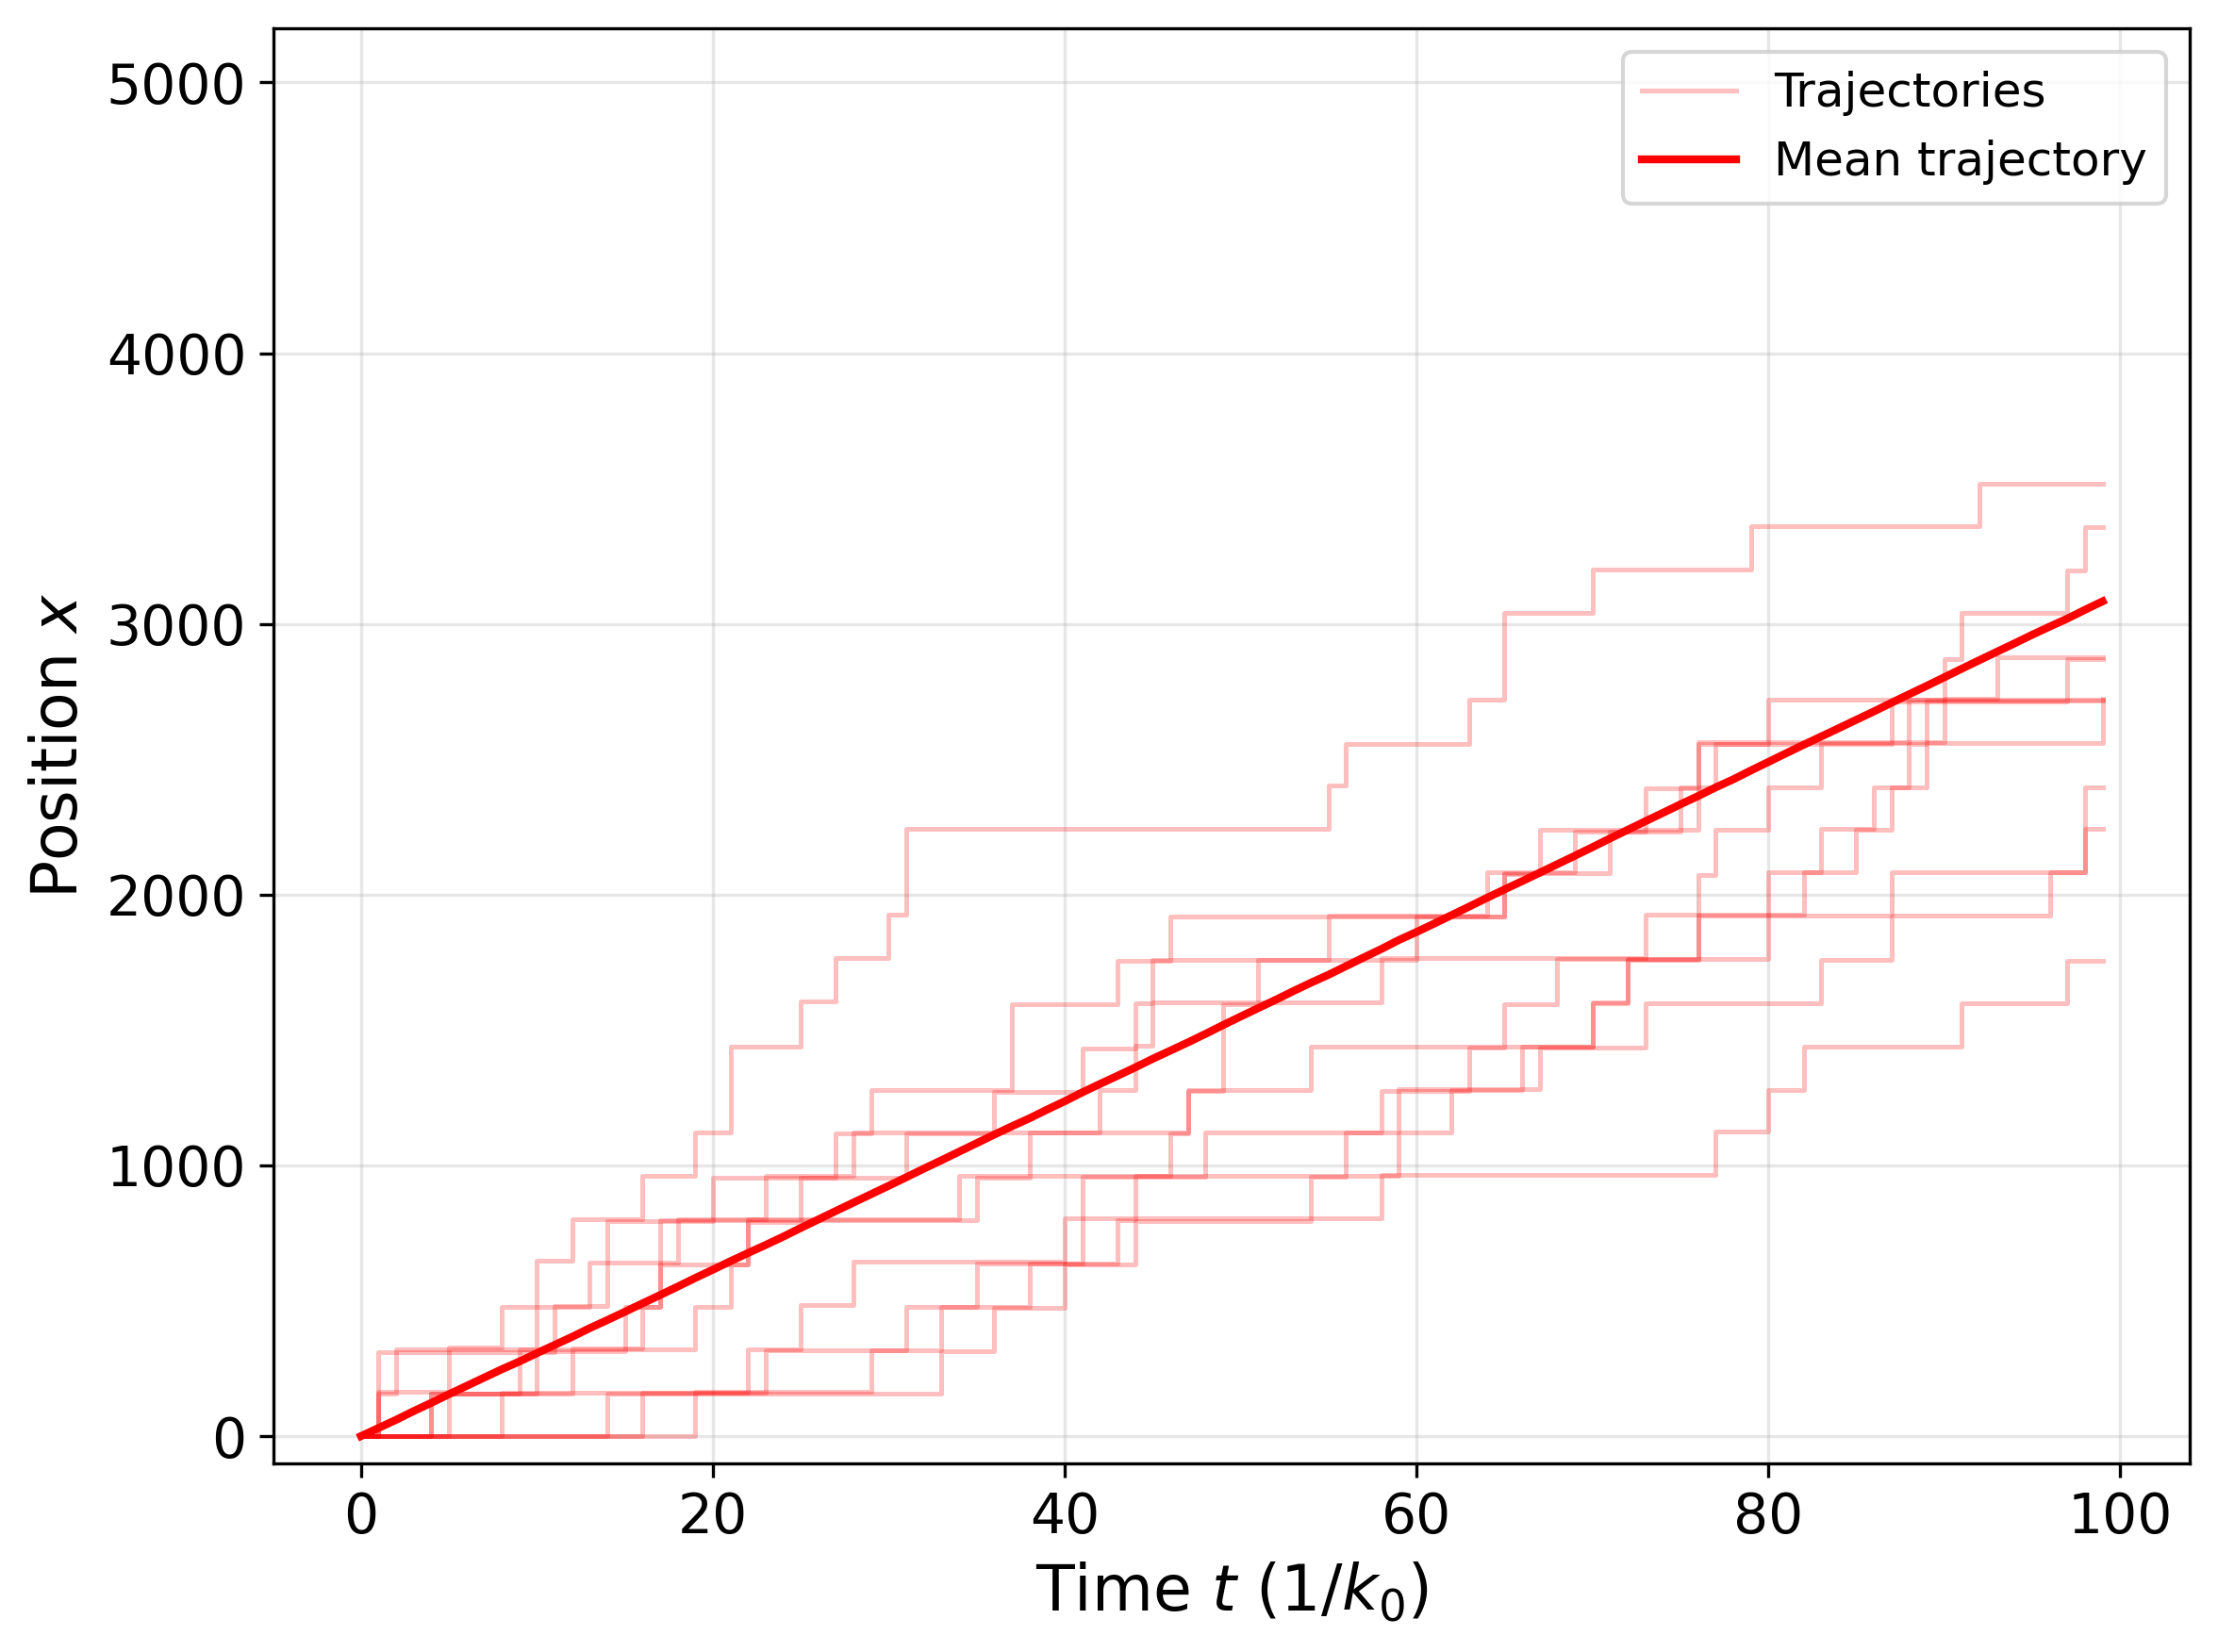

Loading subfiles:   5%|▌         | 10/192 [00:00<00:05, 30.36subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__19/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 160$, $\theta = 50$


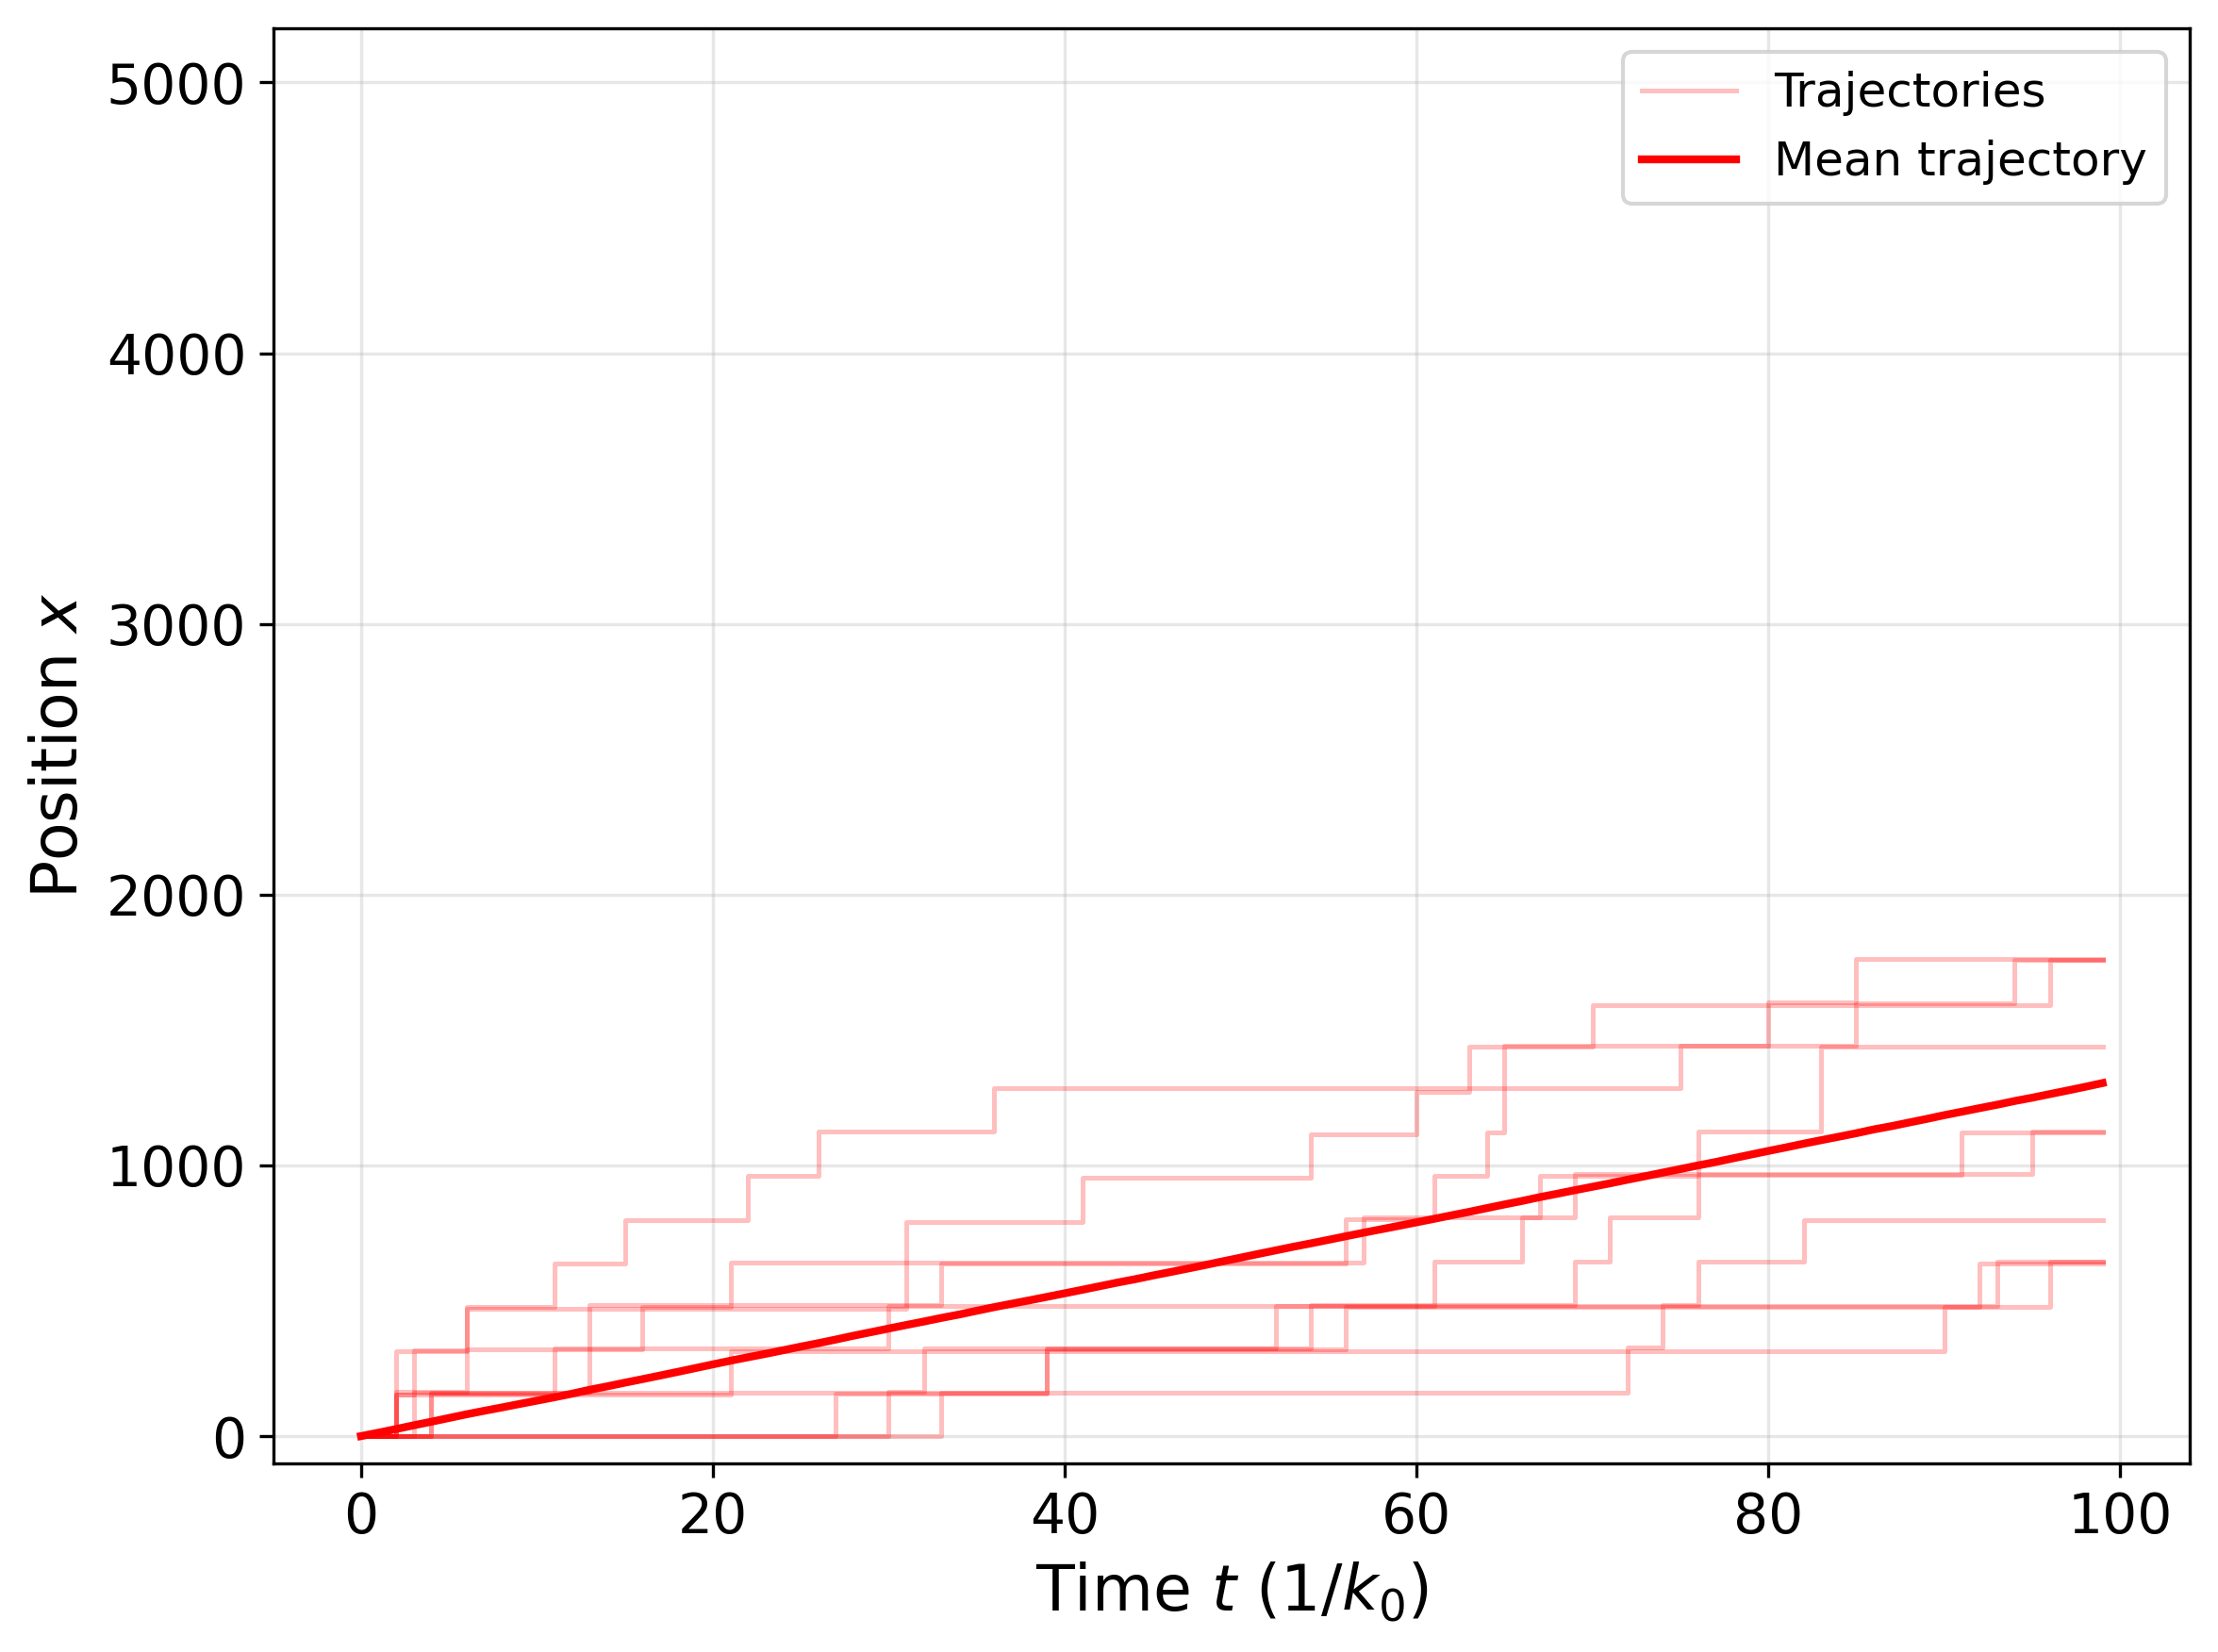

Loading subfiles:   5%|▌         | 10/192 [00:00<00:04, 36.49subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__19/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=160__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 160$, $\theta = 100$


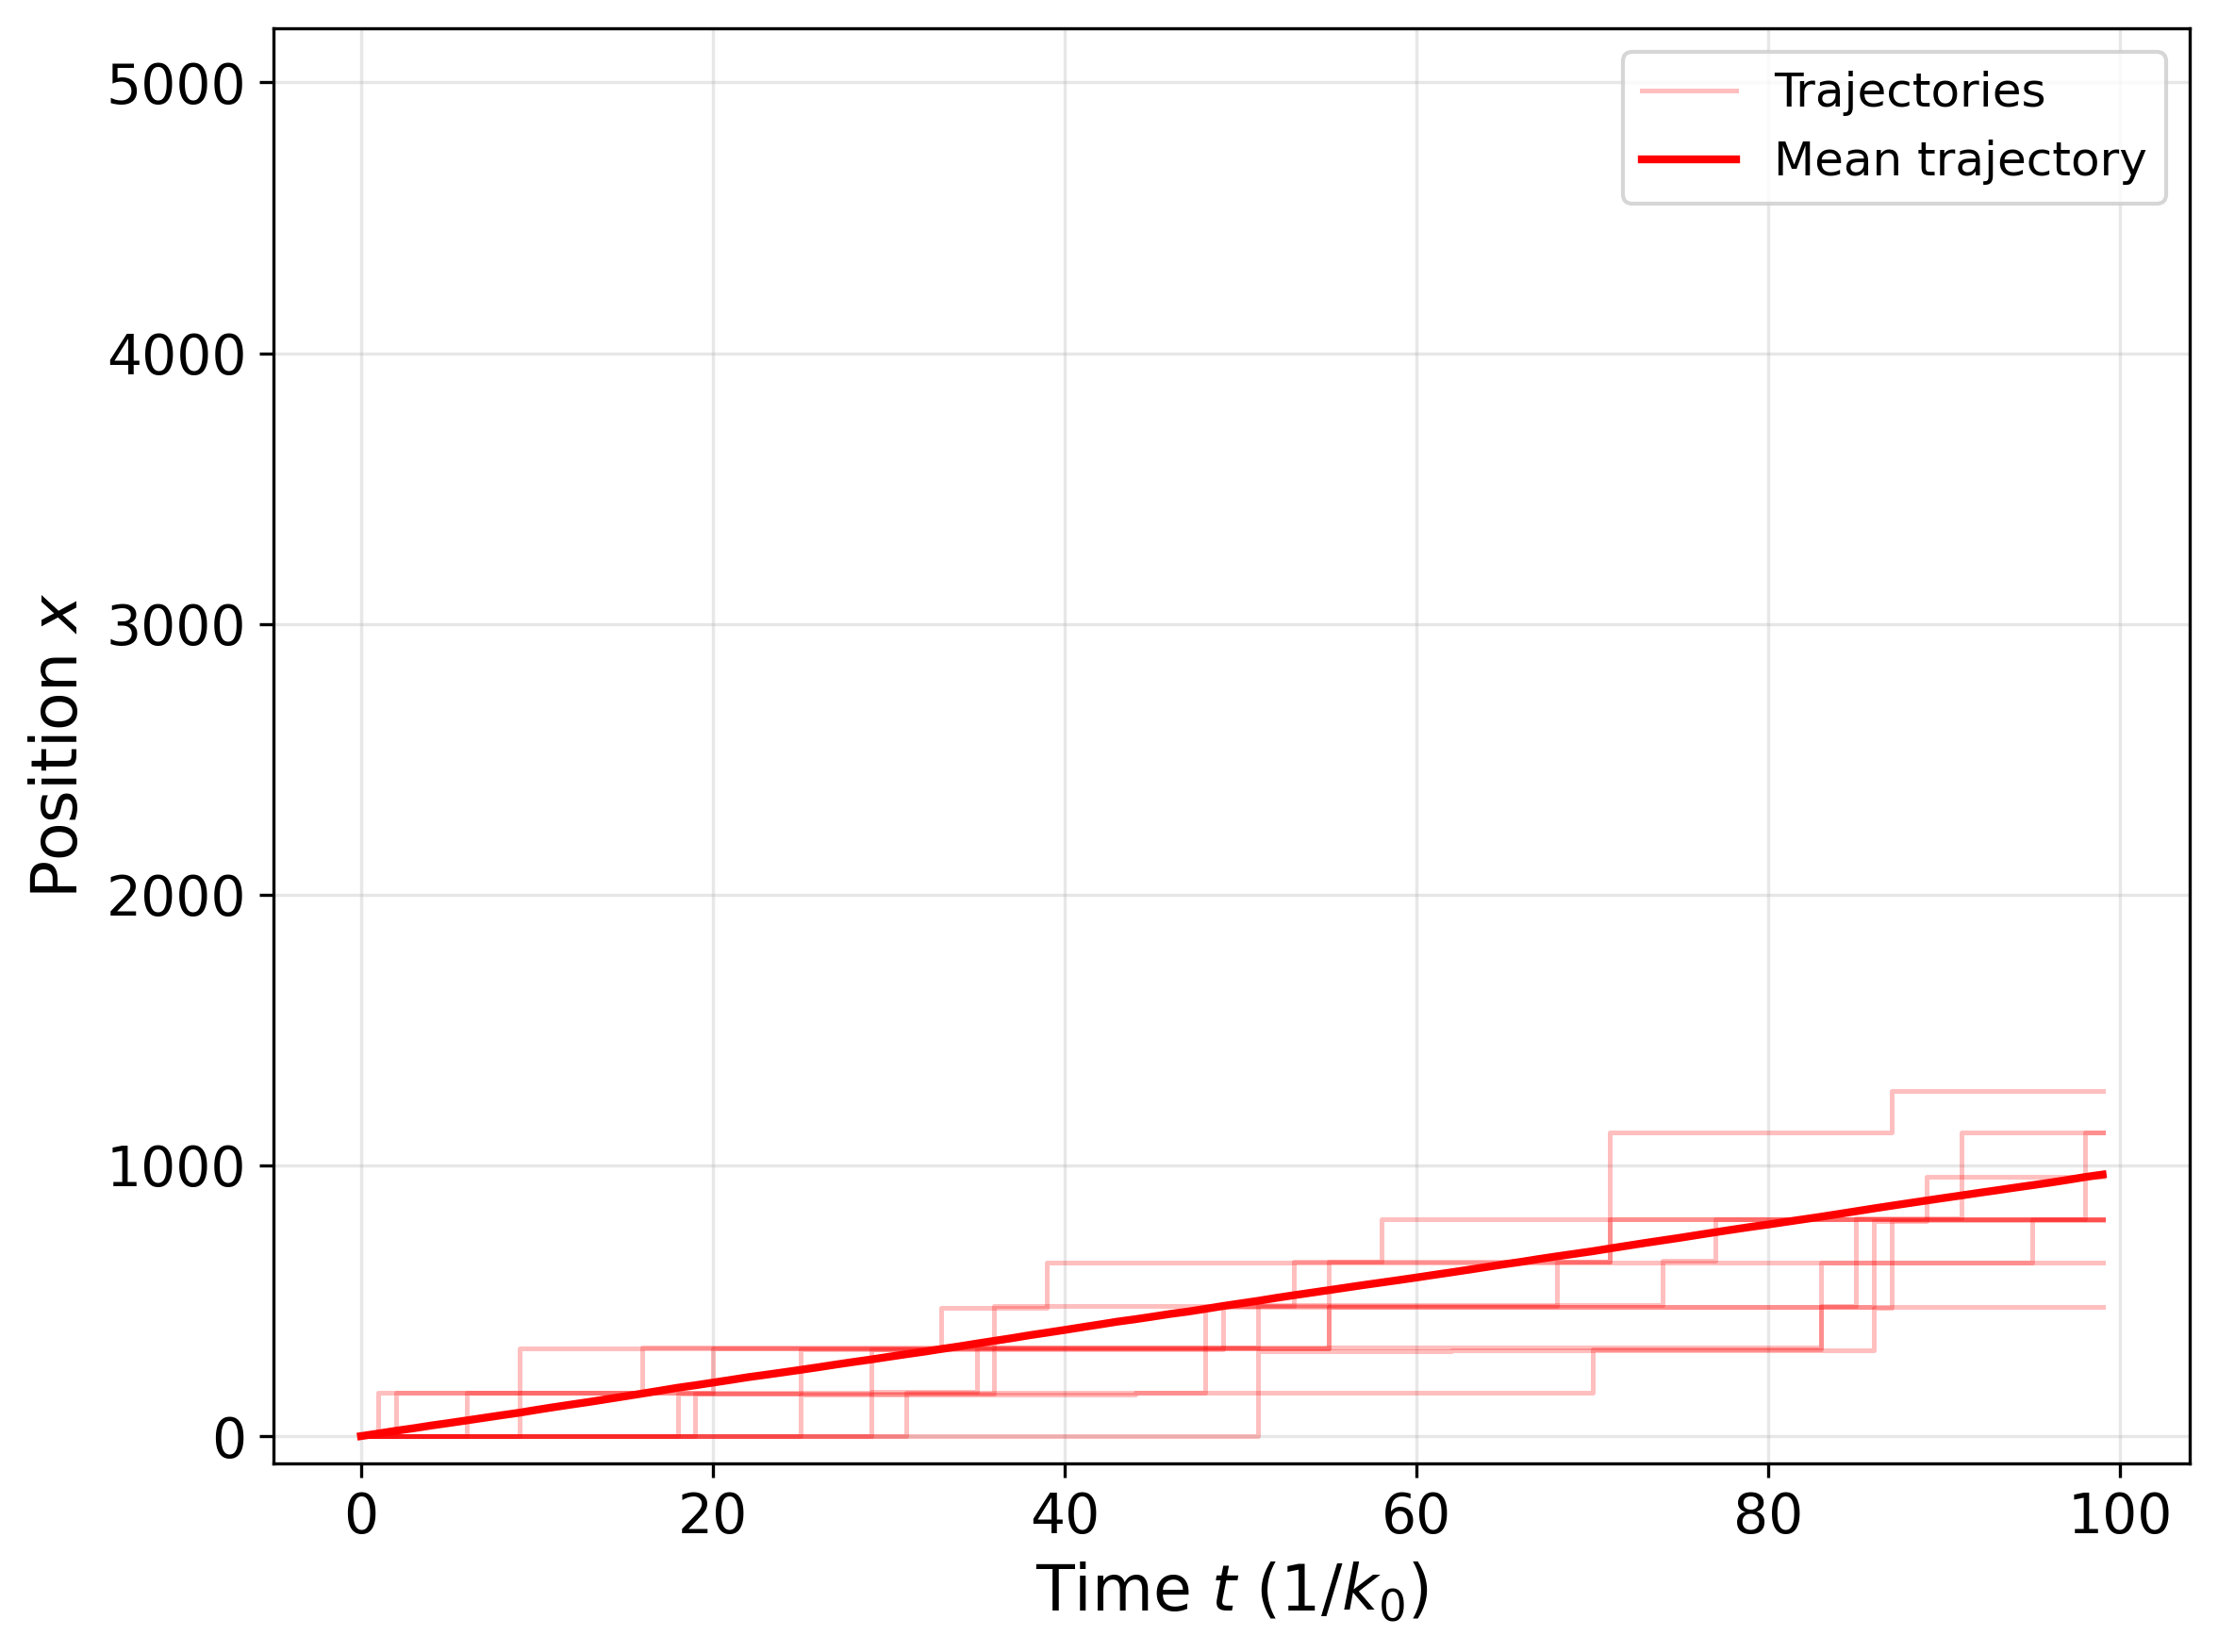

Loading subfiles:   1%|          | 2/192 [00:00<00:16, 11.59subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__6/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 240$, $\theta = 20$


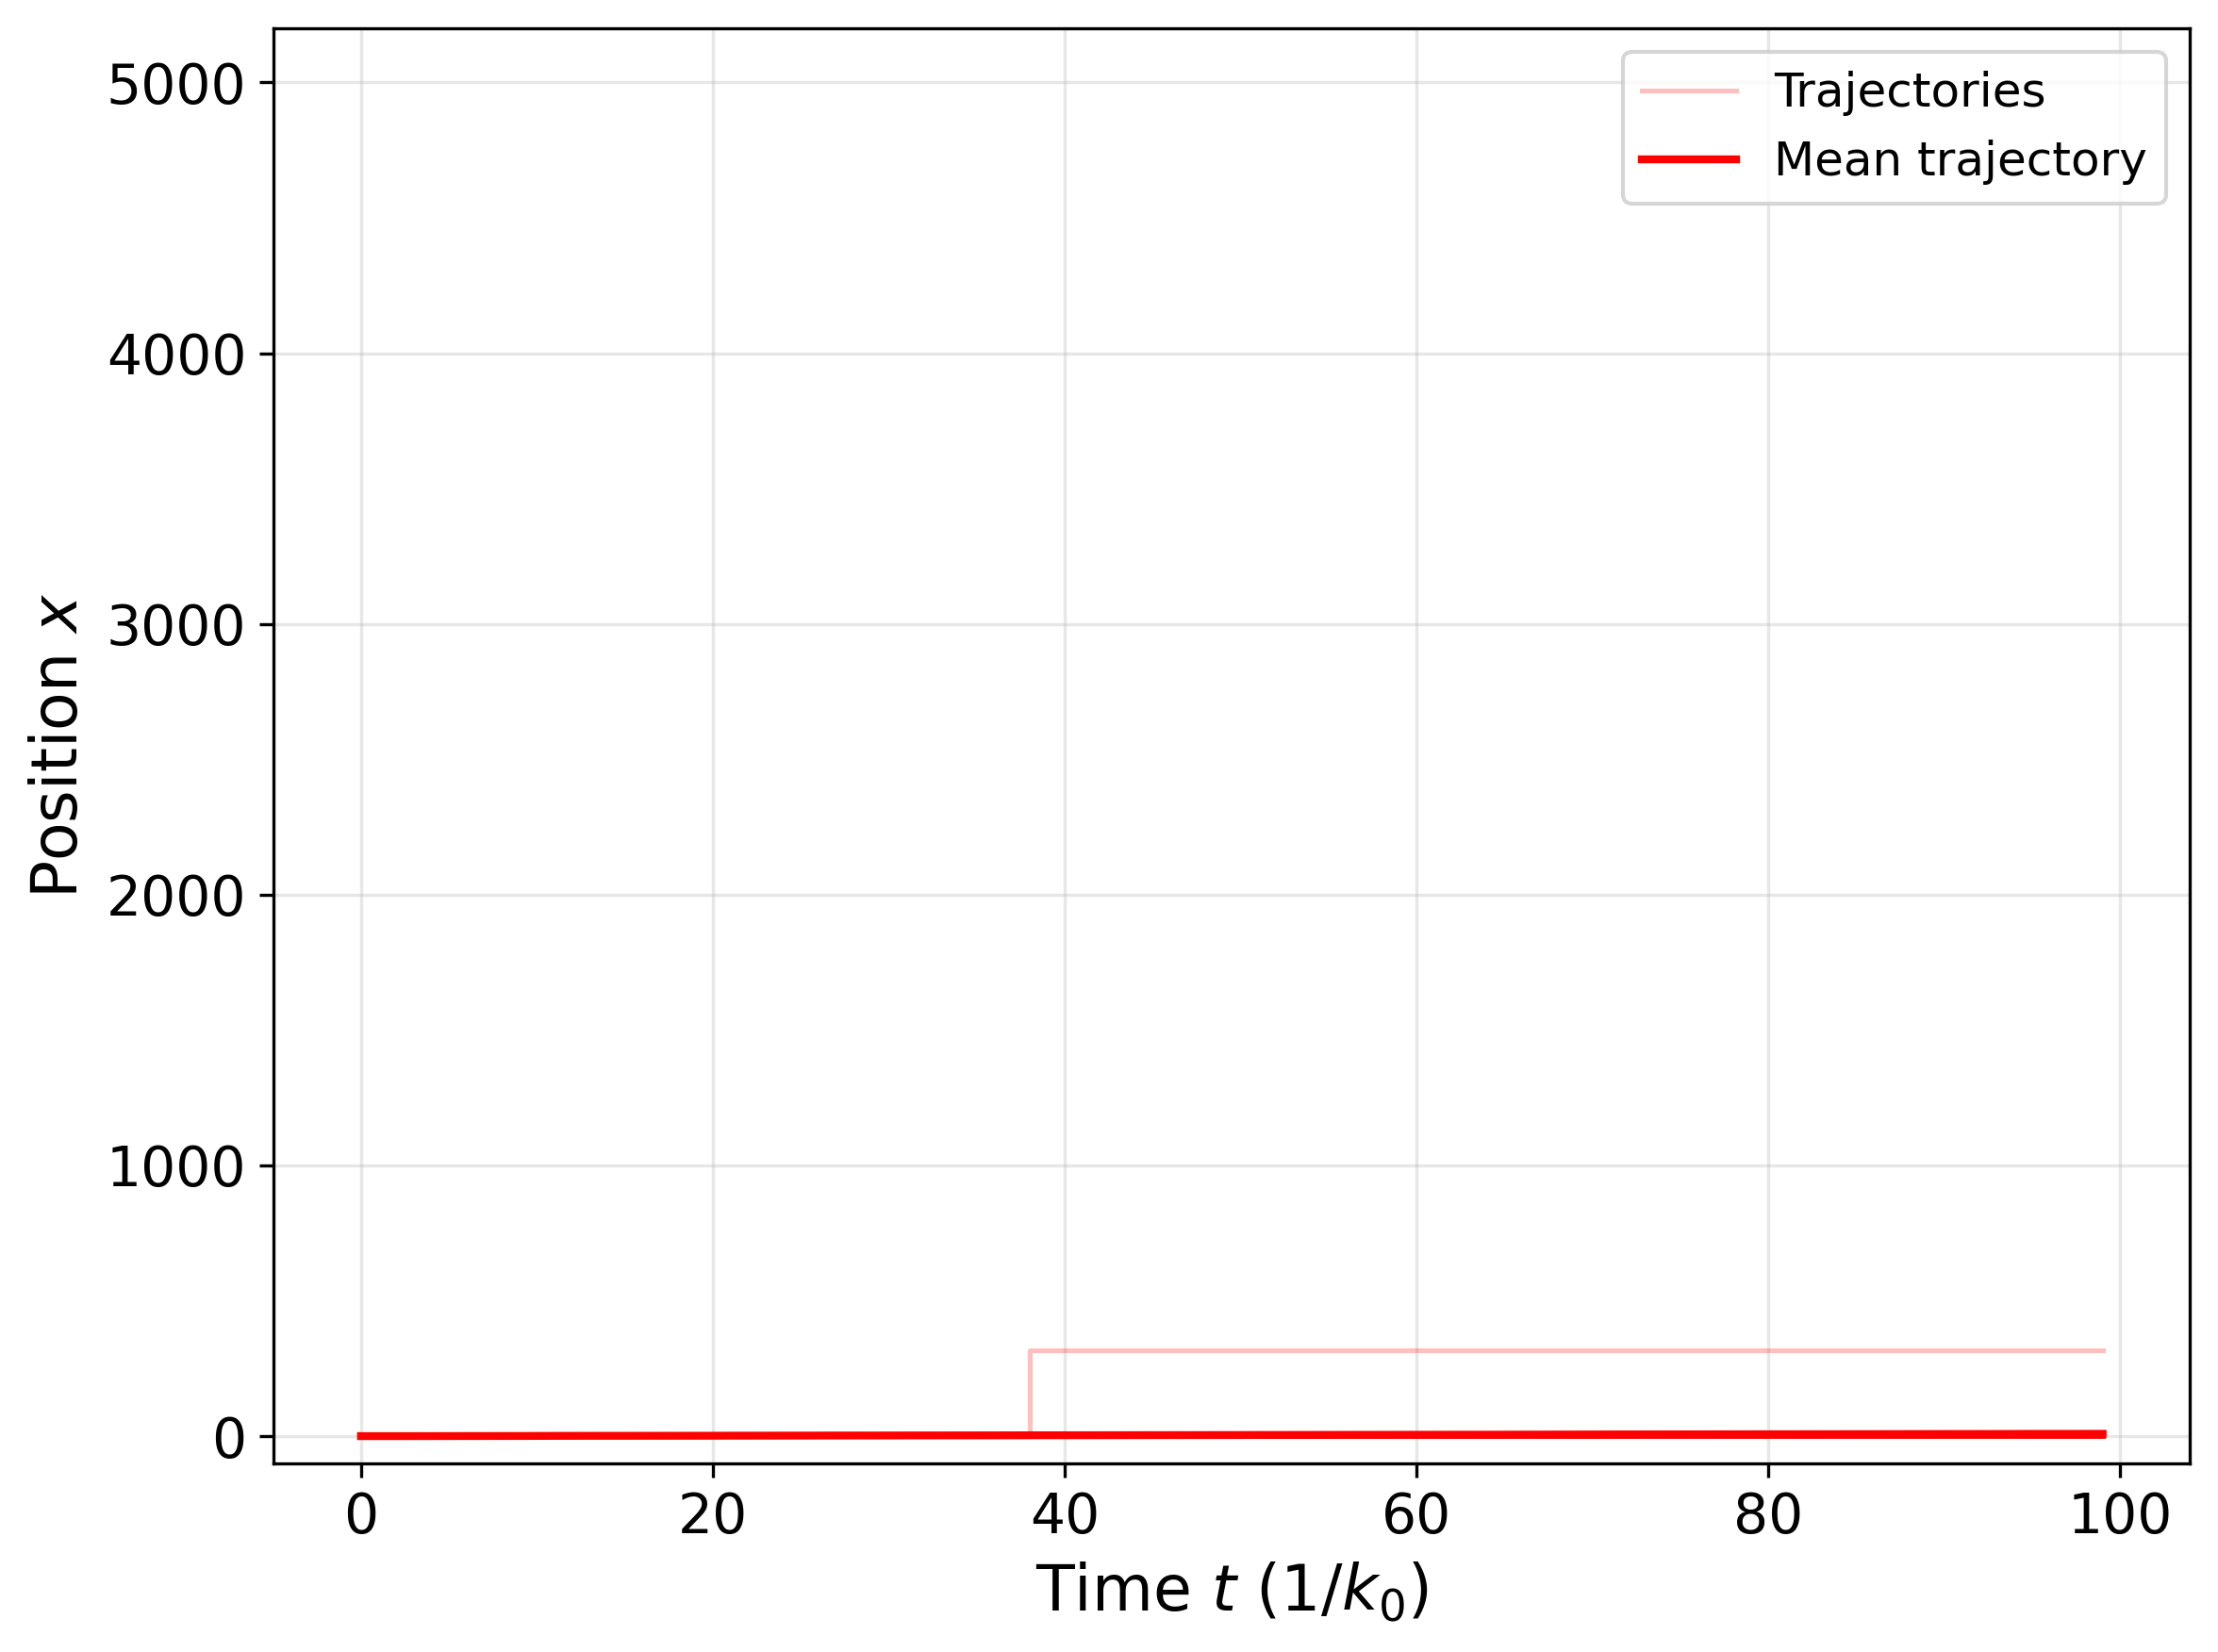

Loading subfiles:   1%|          | 2/192 [00:00<00:14, 12.78subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__6/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 240$, $\theta = 50$


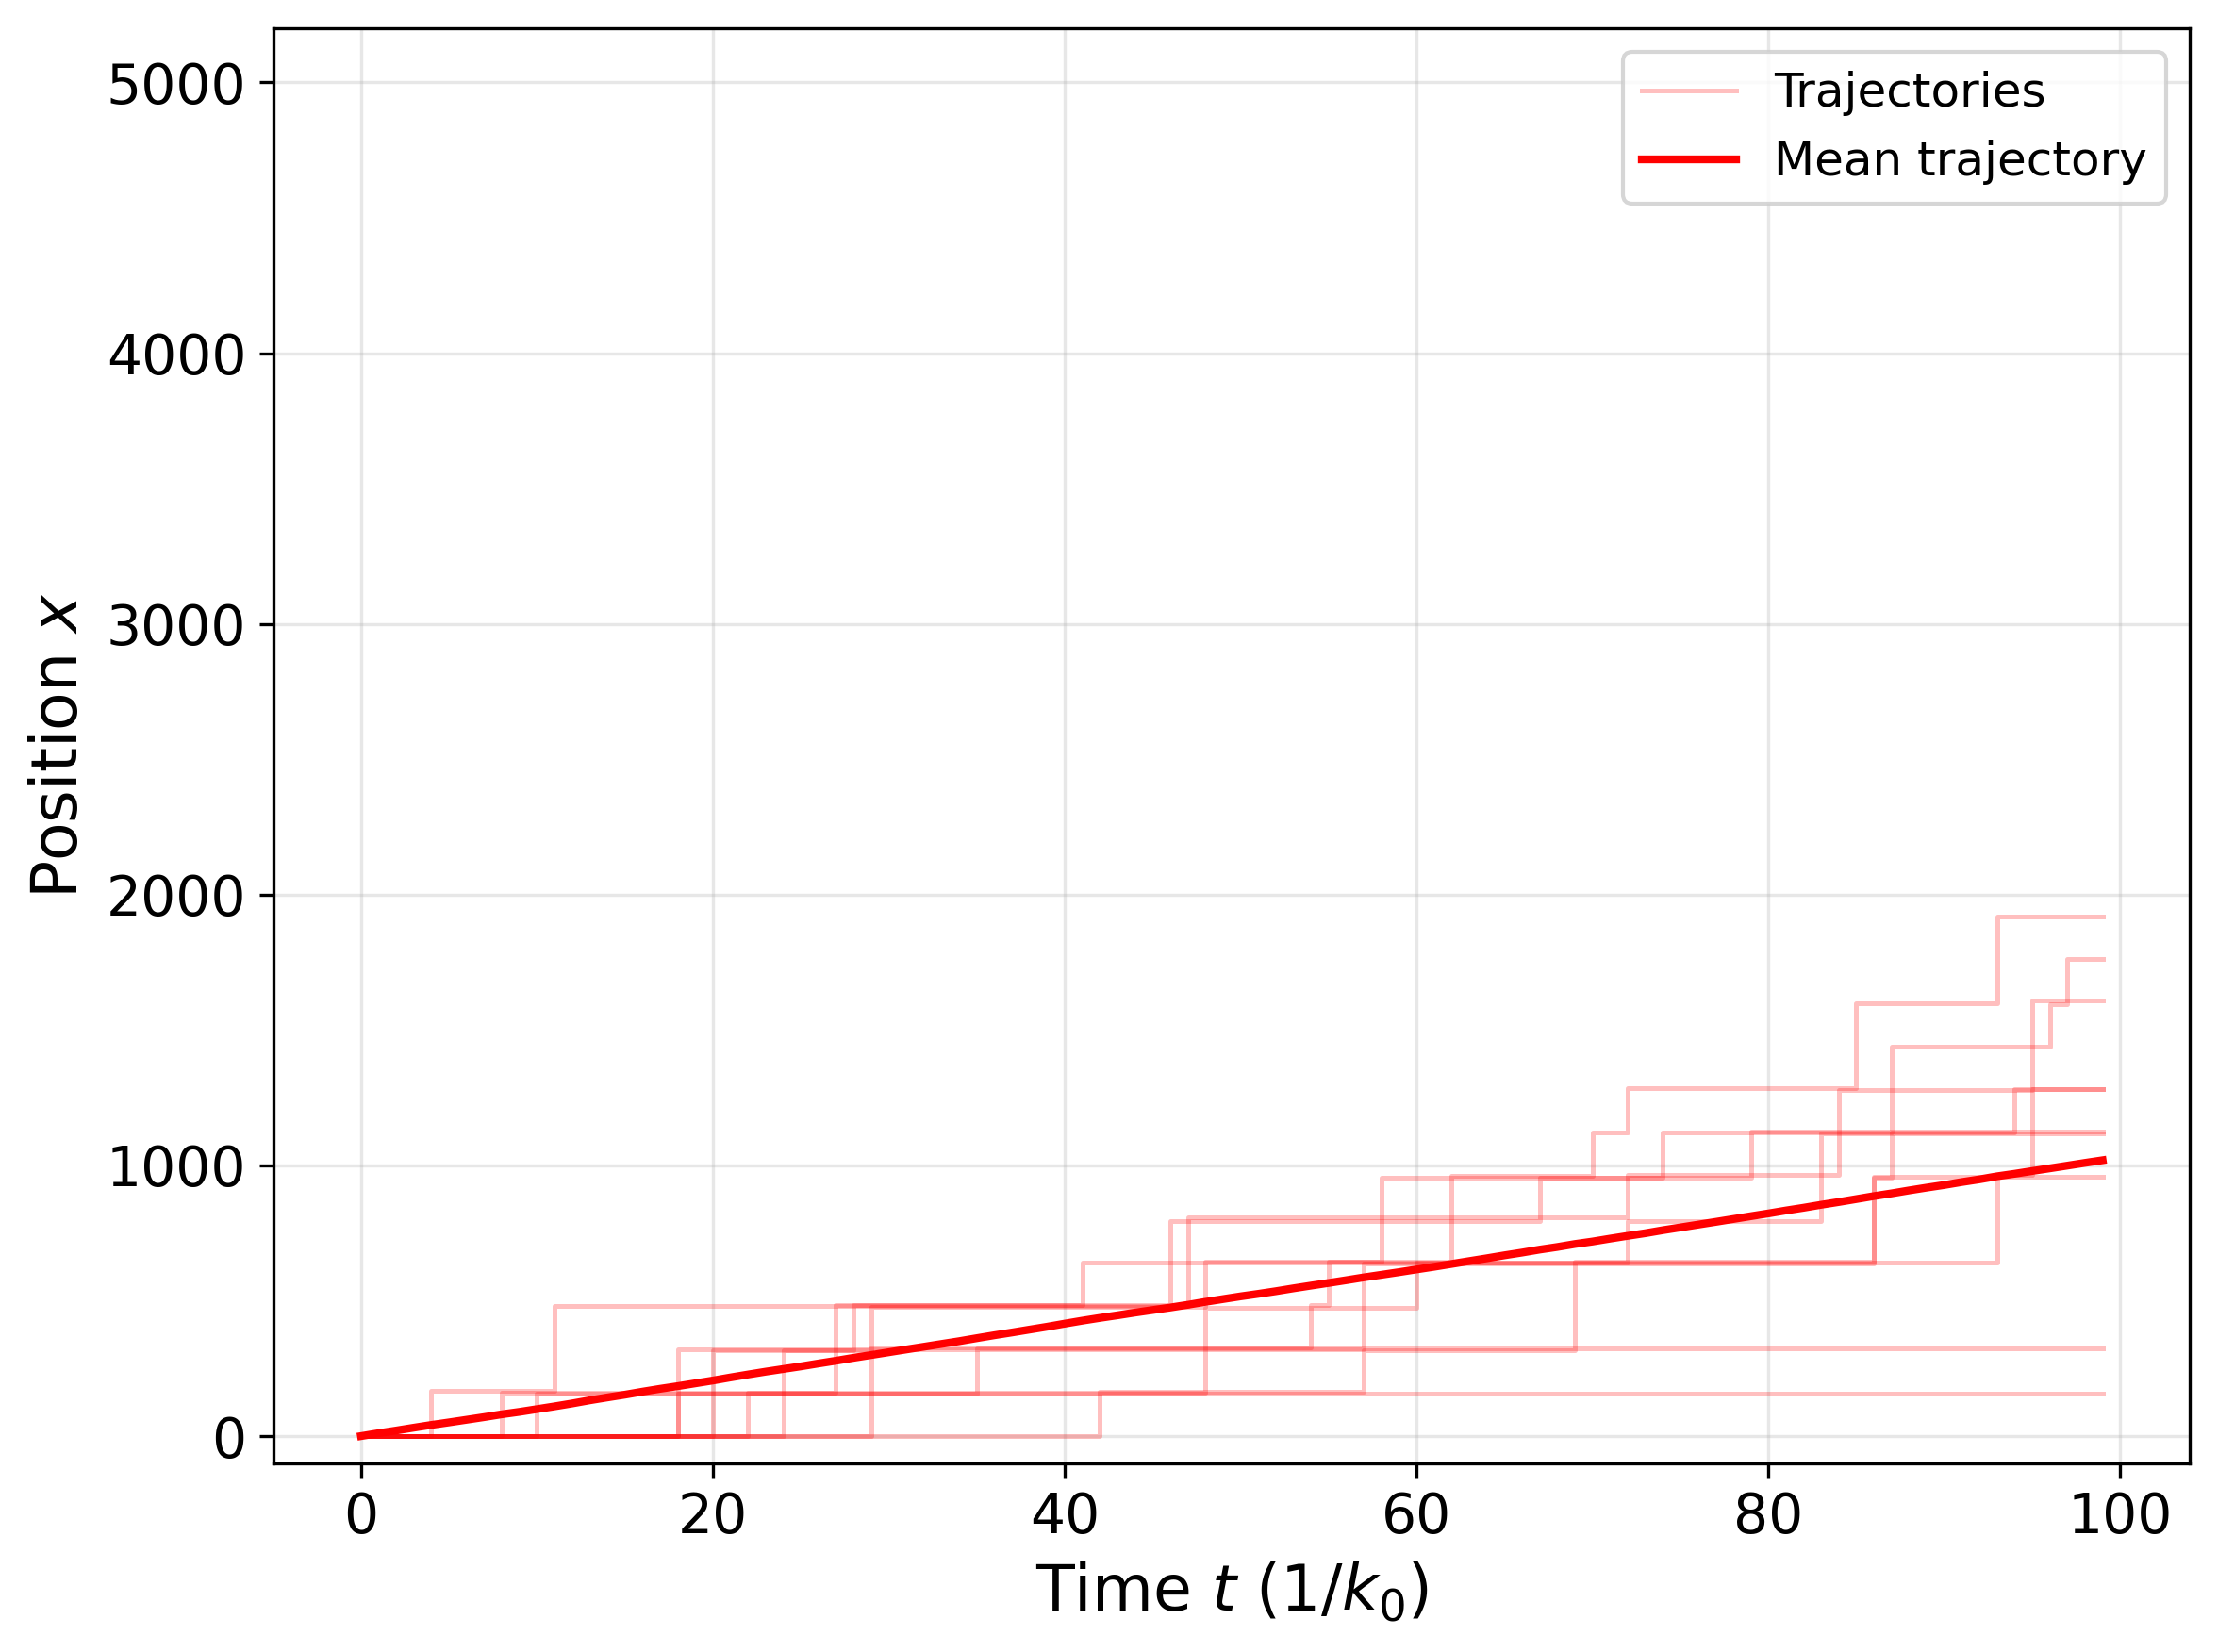

Loading subfiles:   1%|          | 2/192 [00:00<00:15, 12.23subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__6/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=240__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)
$\mu = 240$, $\theta = 100$


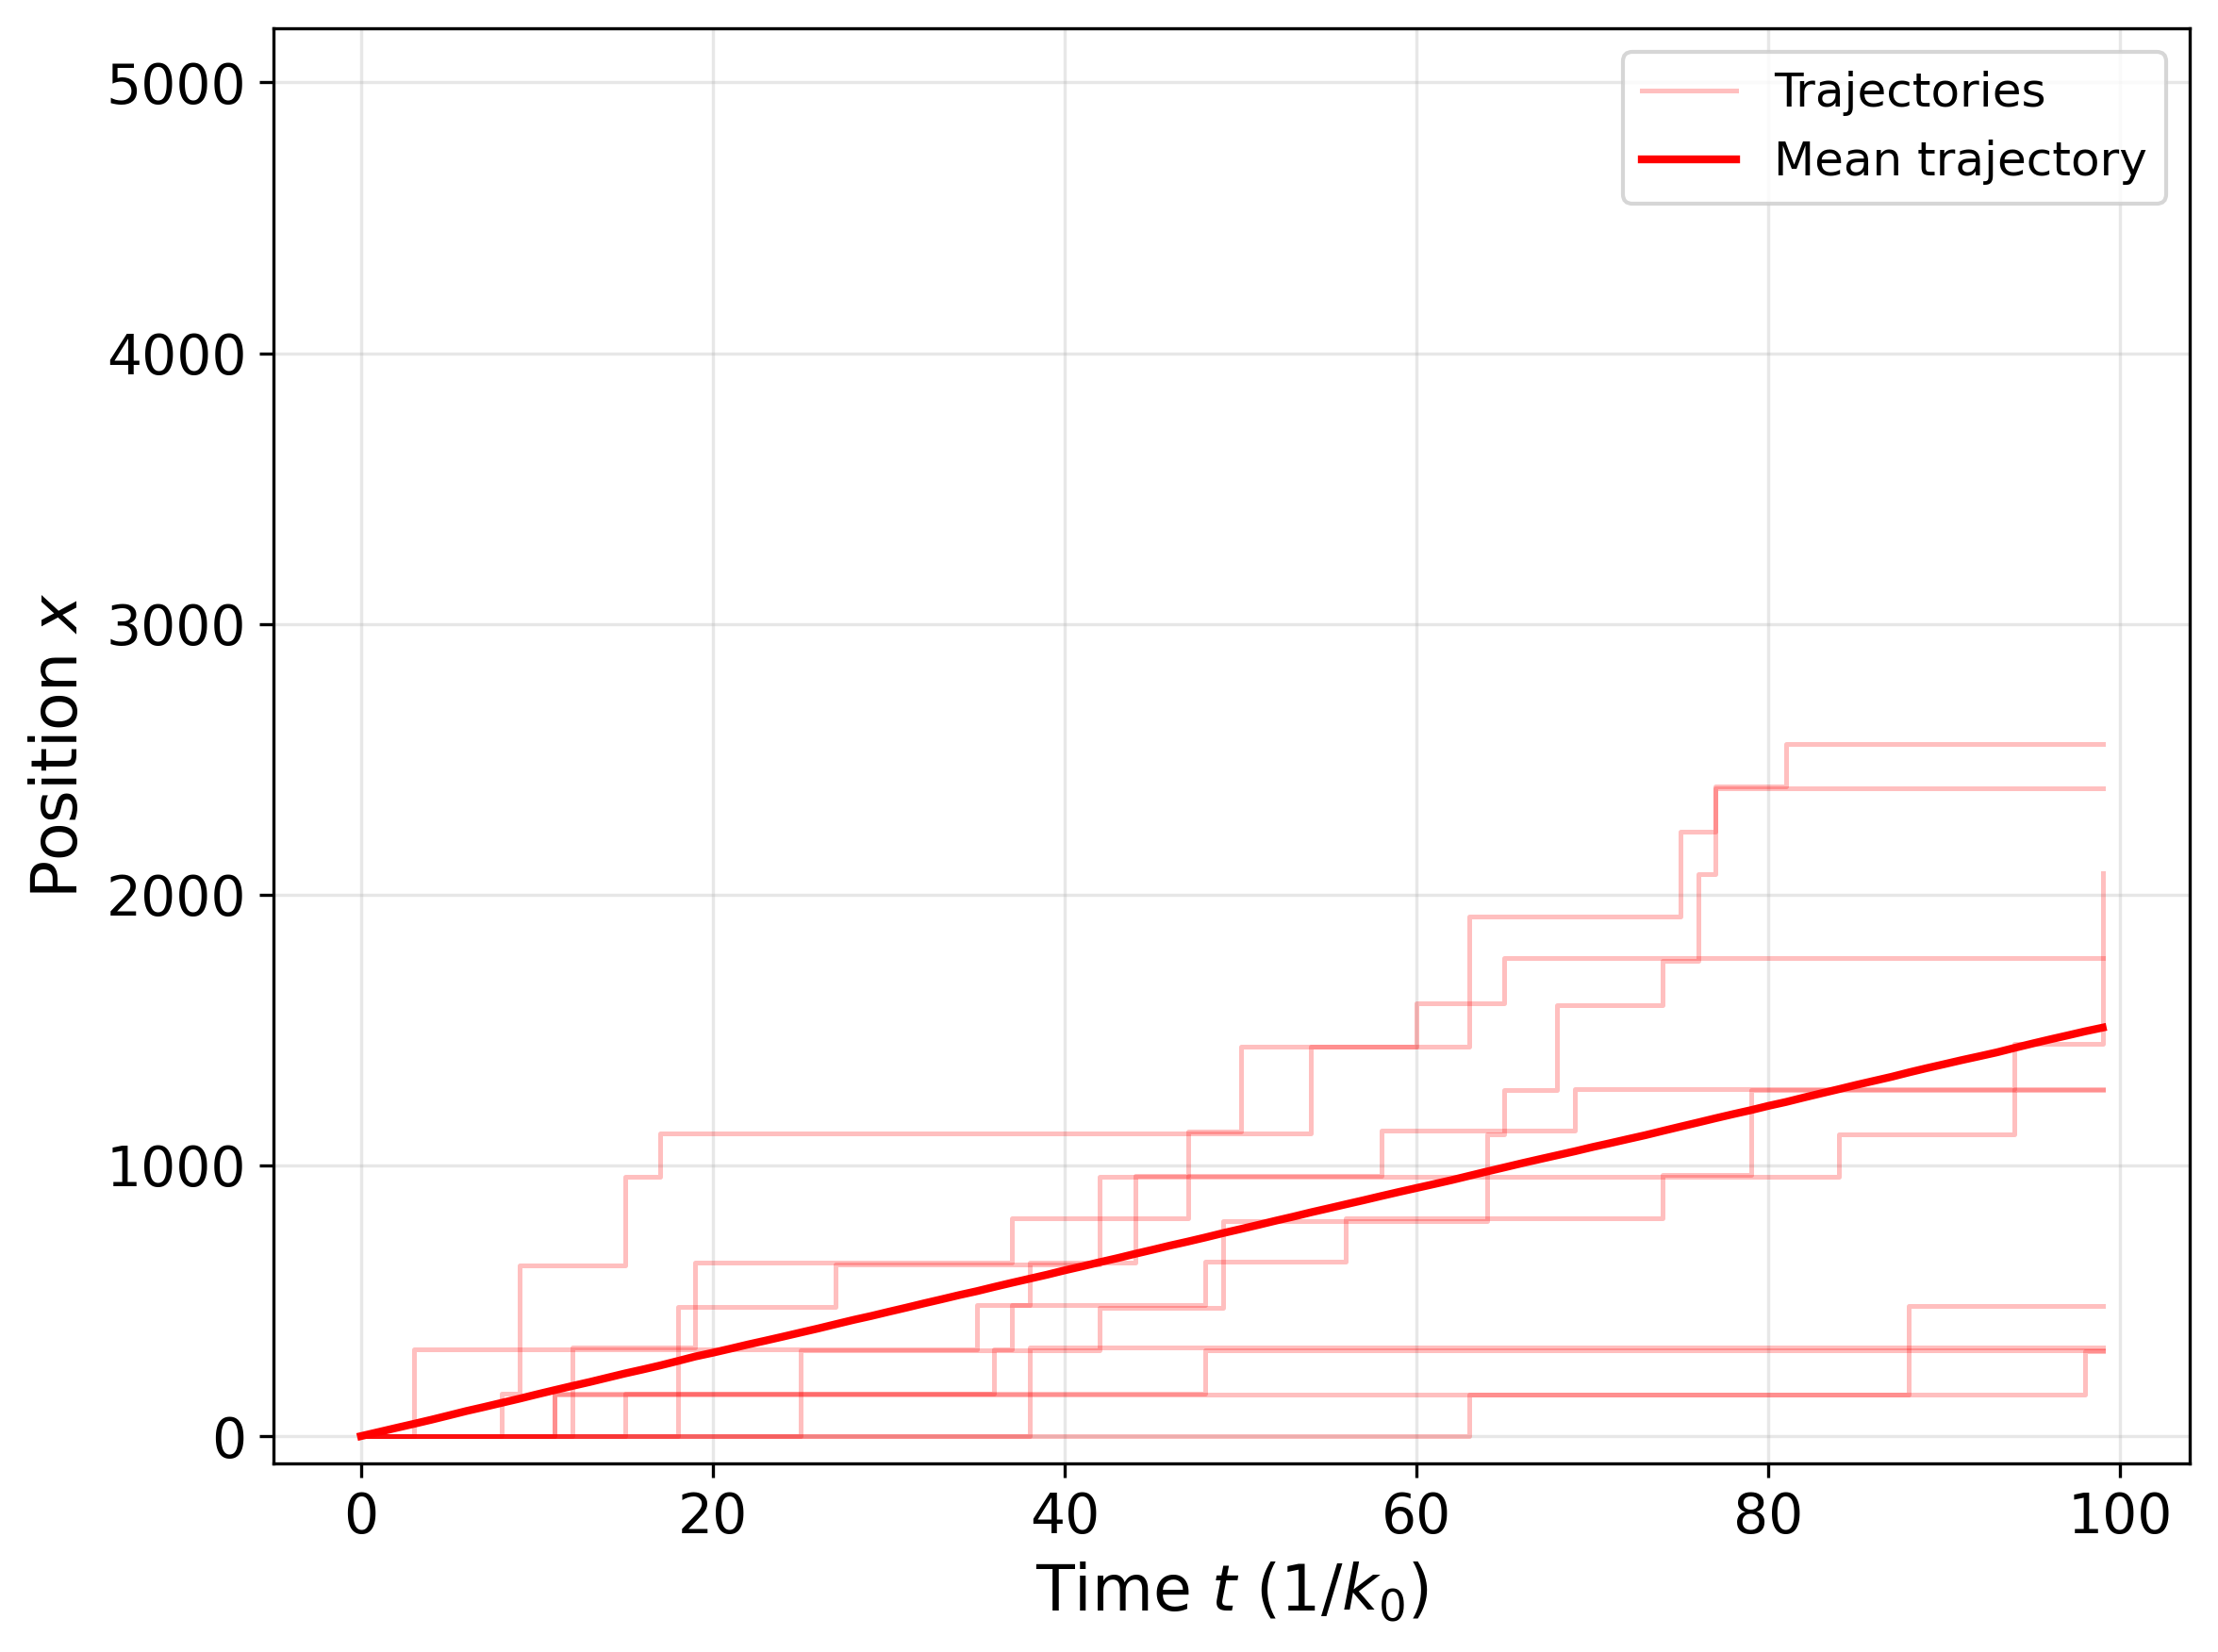

In [18]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Paramètres
# -------------------------------------------------------------------

mus = [160, 240]
thetas = [20, 50, 100]

base_params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "periodic",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "nt": 10_000,
}

# -------------------------------------------------------------------
# Tracé des 6 combinaisons
# -------------------------------------------------------------------

for mu in mus:
    for theta in thetas:

        params = {
            **base_params,
            "mu": mu,
            "theta": theta,
        }

        df = find_parquet_and_load(**params)

        results = df["results"][0].to_numpy()
        results_mean = df["results_mean"][0].to_numpy()
        times = df["times"][0].to_numpy()

        # --- Figure ---
        plt.figure(figsize=(8, 6), dpi=300)

        # Trajectoires
        for i in range(10):
            plt.step(
                times,
                results[i],
                where="post",
                alpha=0.25,
                linewidth=1.2,
                label="Trajectories" if i == 0 else None,
                color="red"
            )

        # Trajectoire moyenne
        plt.plot(
            times,
            results_mean,
            linewidth=2.0,
            label="Mean trajectory",
            color="red"
        )

        plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
        plt.ylabel(r"Position $x$", fontsize=16)

        plt.ylim(-100, 5200)

        plt.tick_params(labelsize=14)
        plt.grid(True, alpha=0.3)
        

        # plt.title(
        #     rf"$\mu = {mu}$, $\theta = {theta}$",
        #     fontsize=16,
        # )
        print(rf"$\mu = {mu}$, $\theta = {theta}$")

        plt.legend(fontsize=12)
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_138058/1865440365.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = cm.get_cmap("plasma")


theta = 20


Loading subfiles:  39%|███▊      | 74/192 [00:01<00:02, 46.81subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__29/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:  37%|███▋      | 71/192 [00:01<00:02, 45.26subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__36/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=20__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


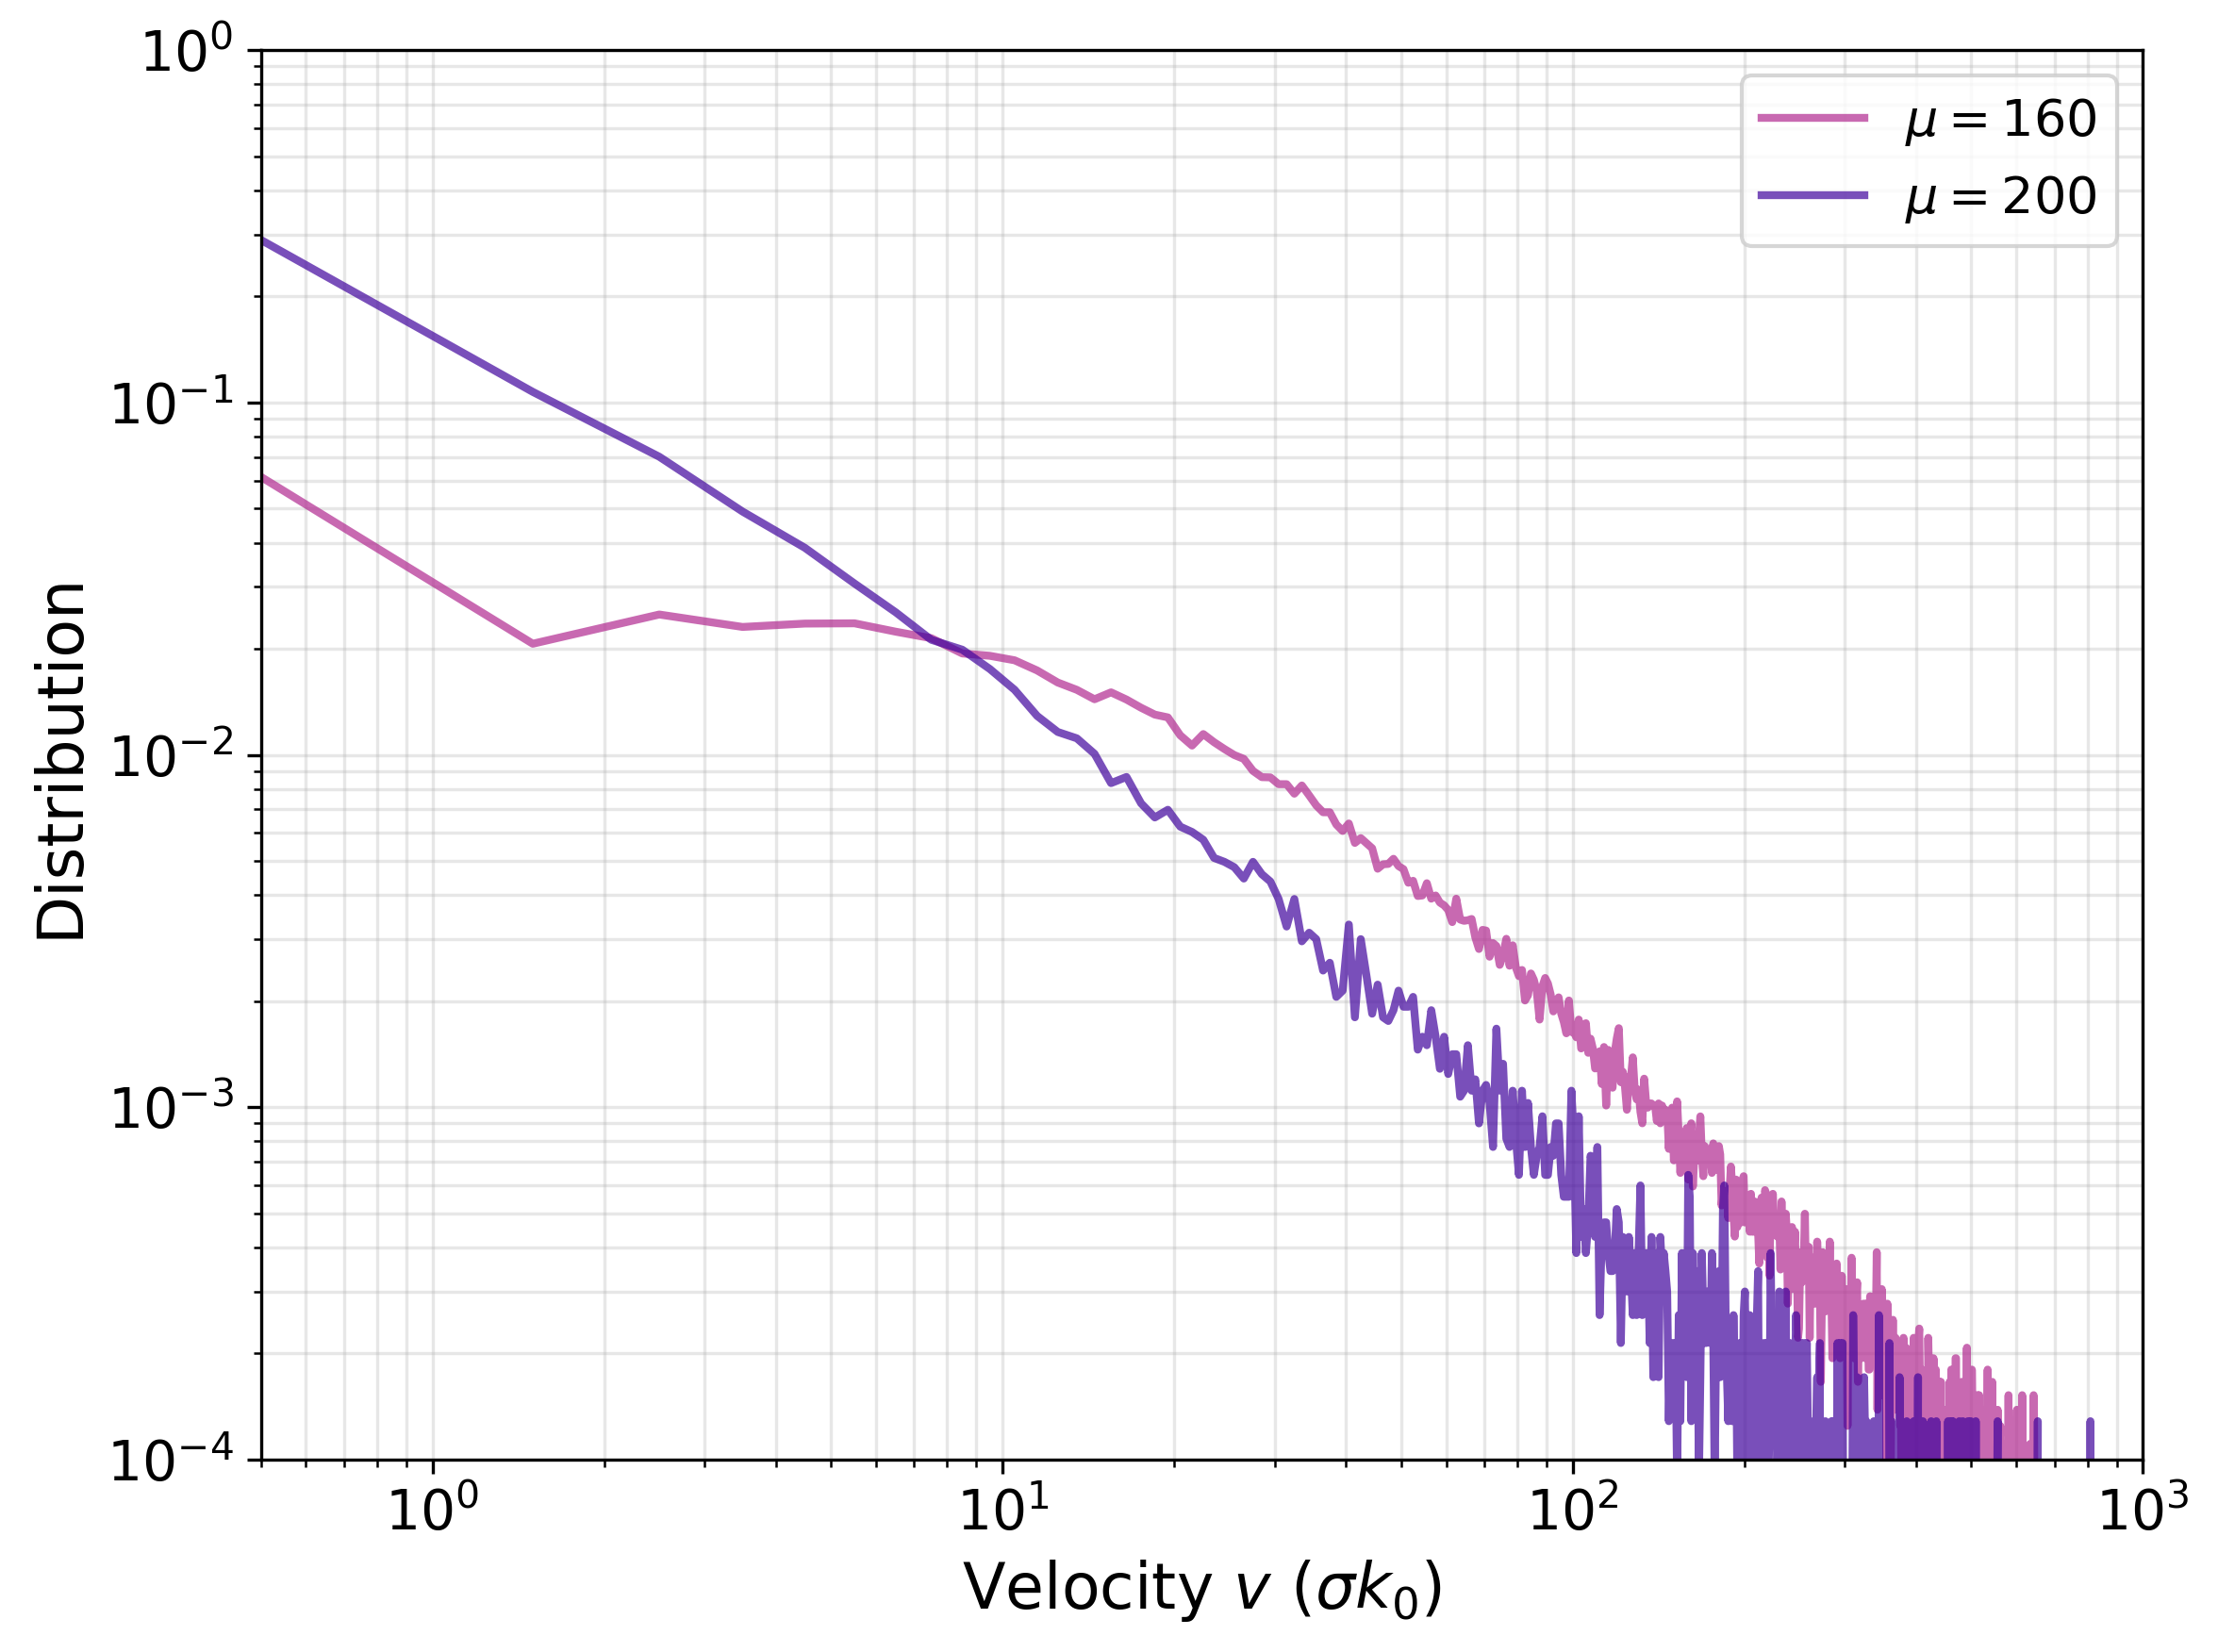

theta = 50


Loading subfiles:  39%|███▊      | 74/192 [00:01<00:02, 44.96subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__29/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)



Loading subfiles:  37%|███▋      | 71/192 [00:01<00:02, 45.23subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__36/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=50__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


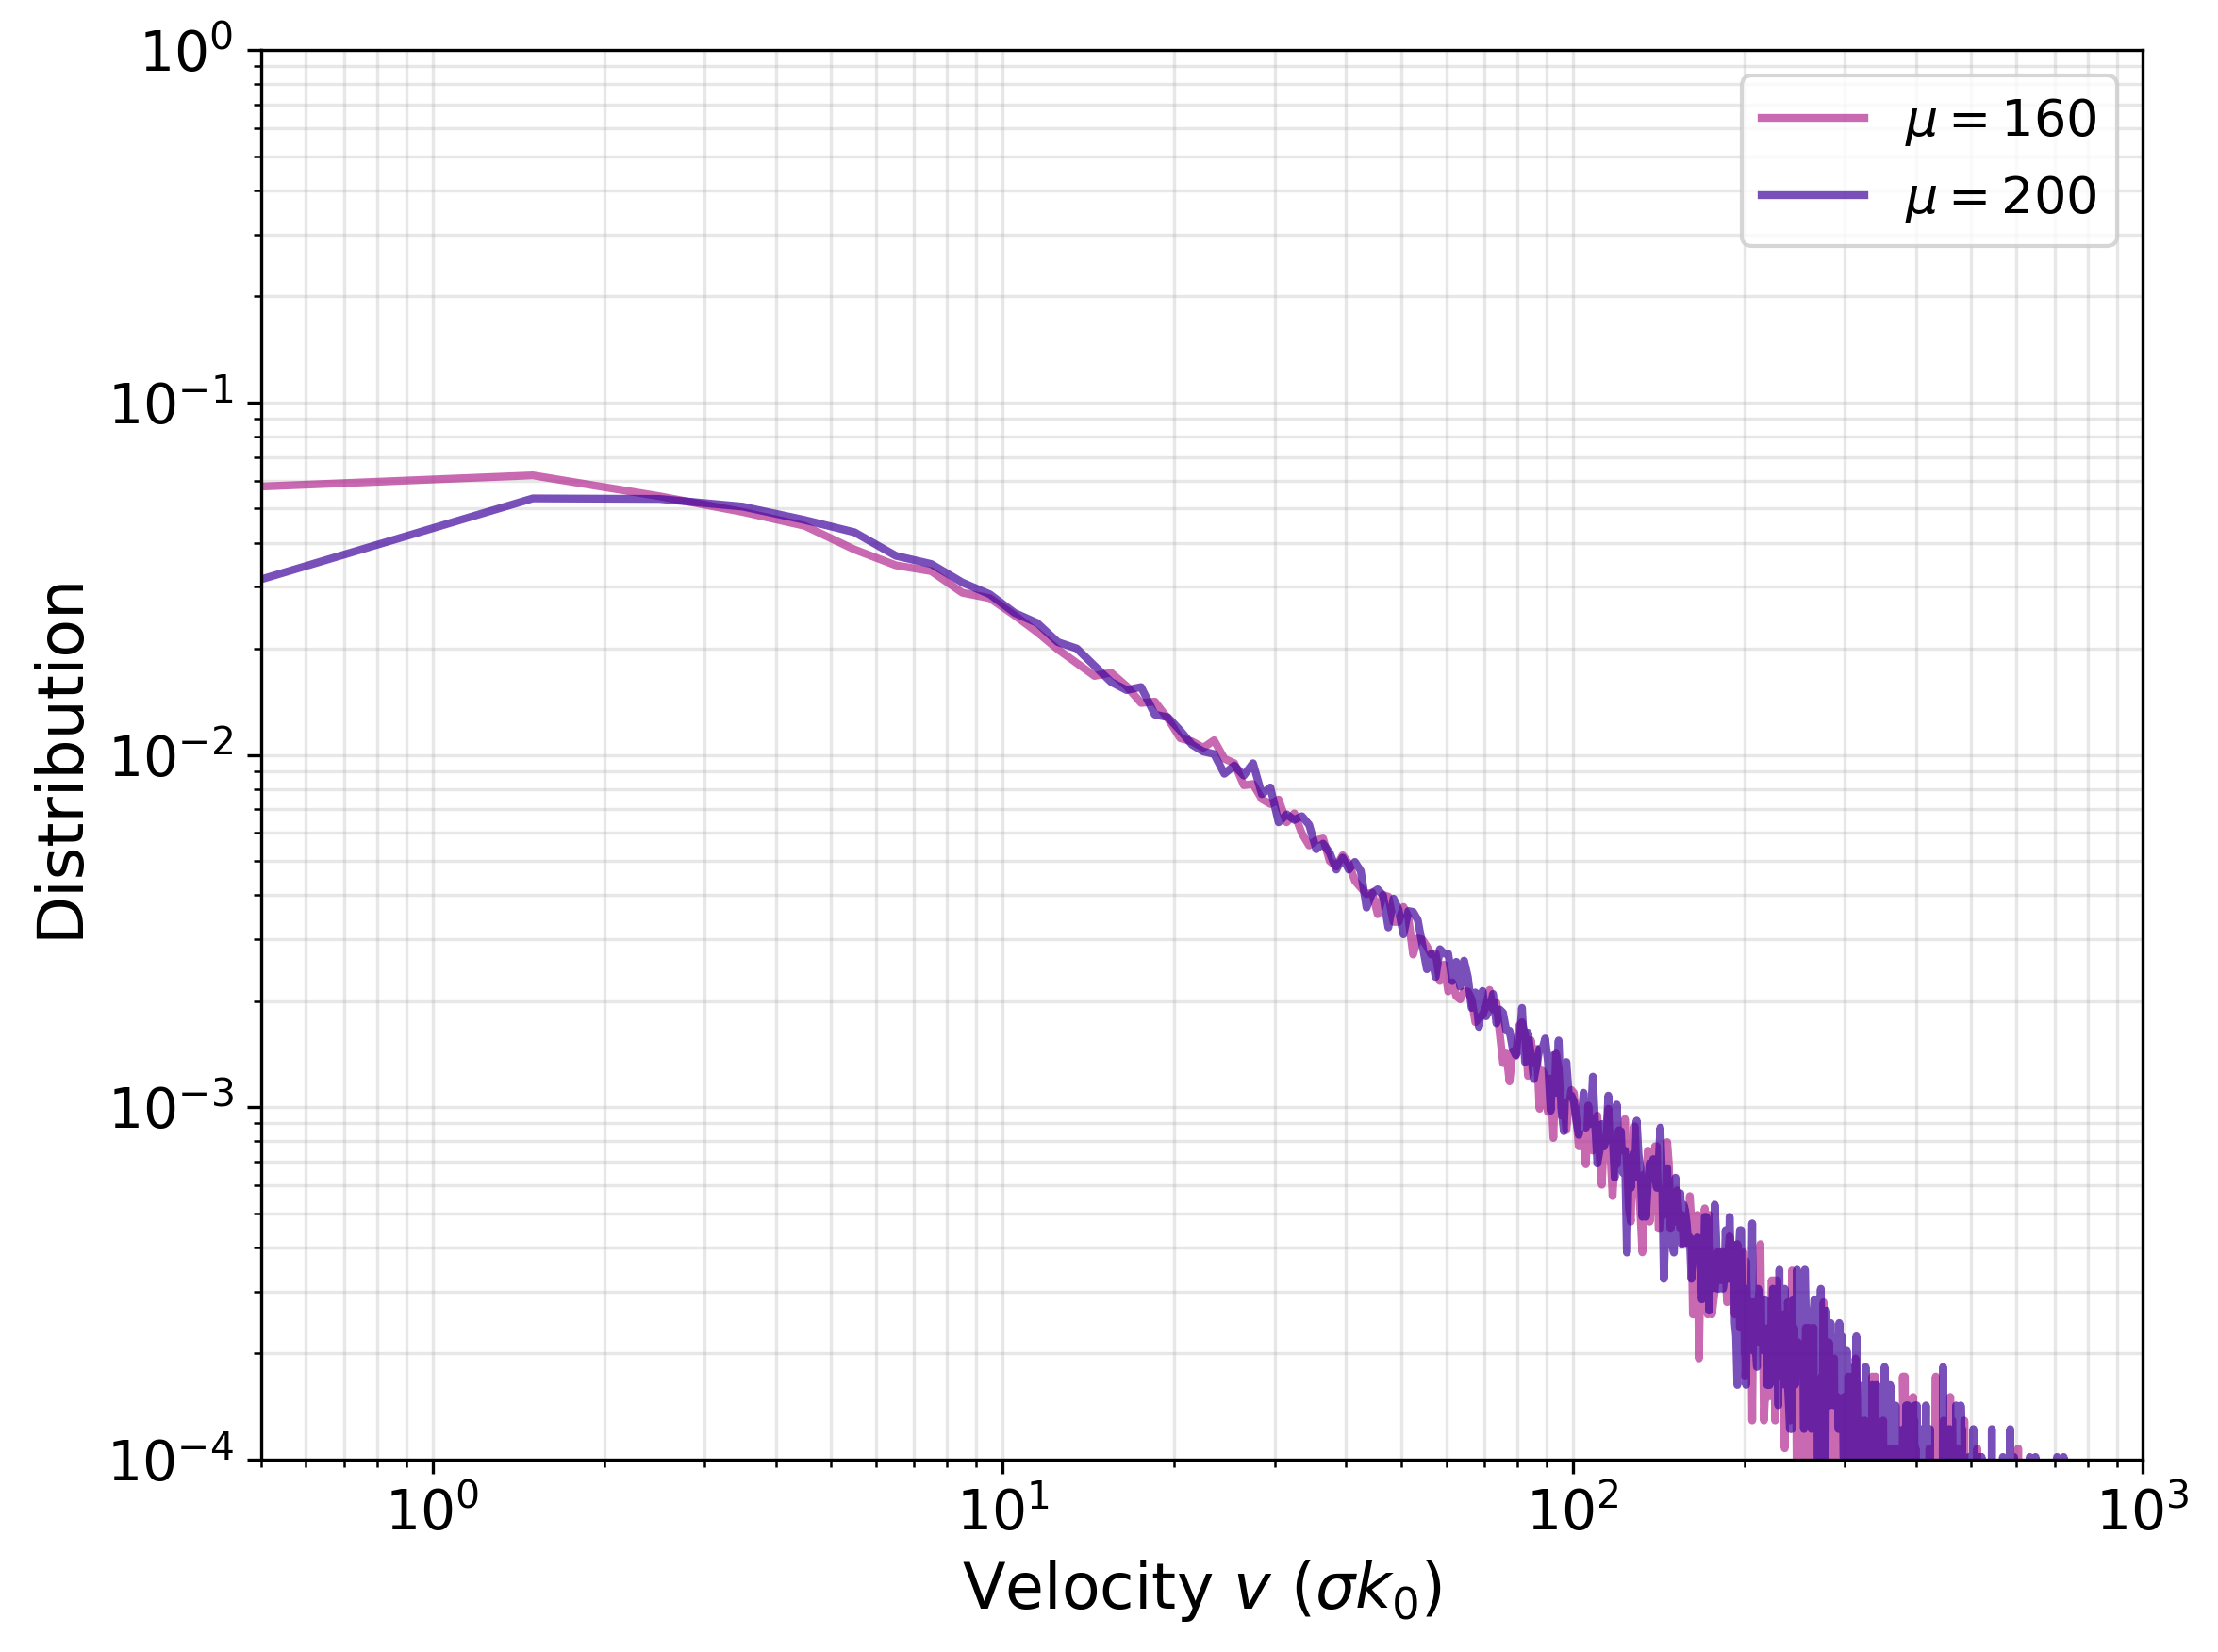

theta = 100


Loading subfiles:  39%|███▊      | 74/192 [00:01<00:02, 47.17subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__lslow__29/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=160__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:  37%|███▋      | 71/192 [00:01<00:02, 51.74subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__36/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=200__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


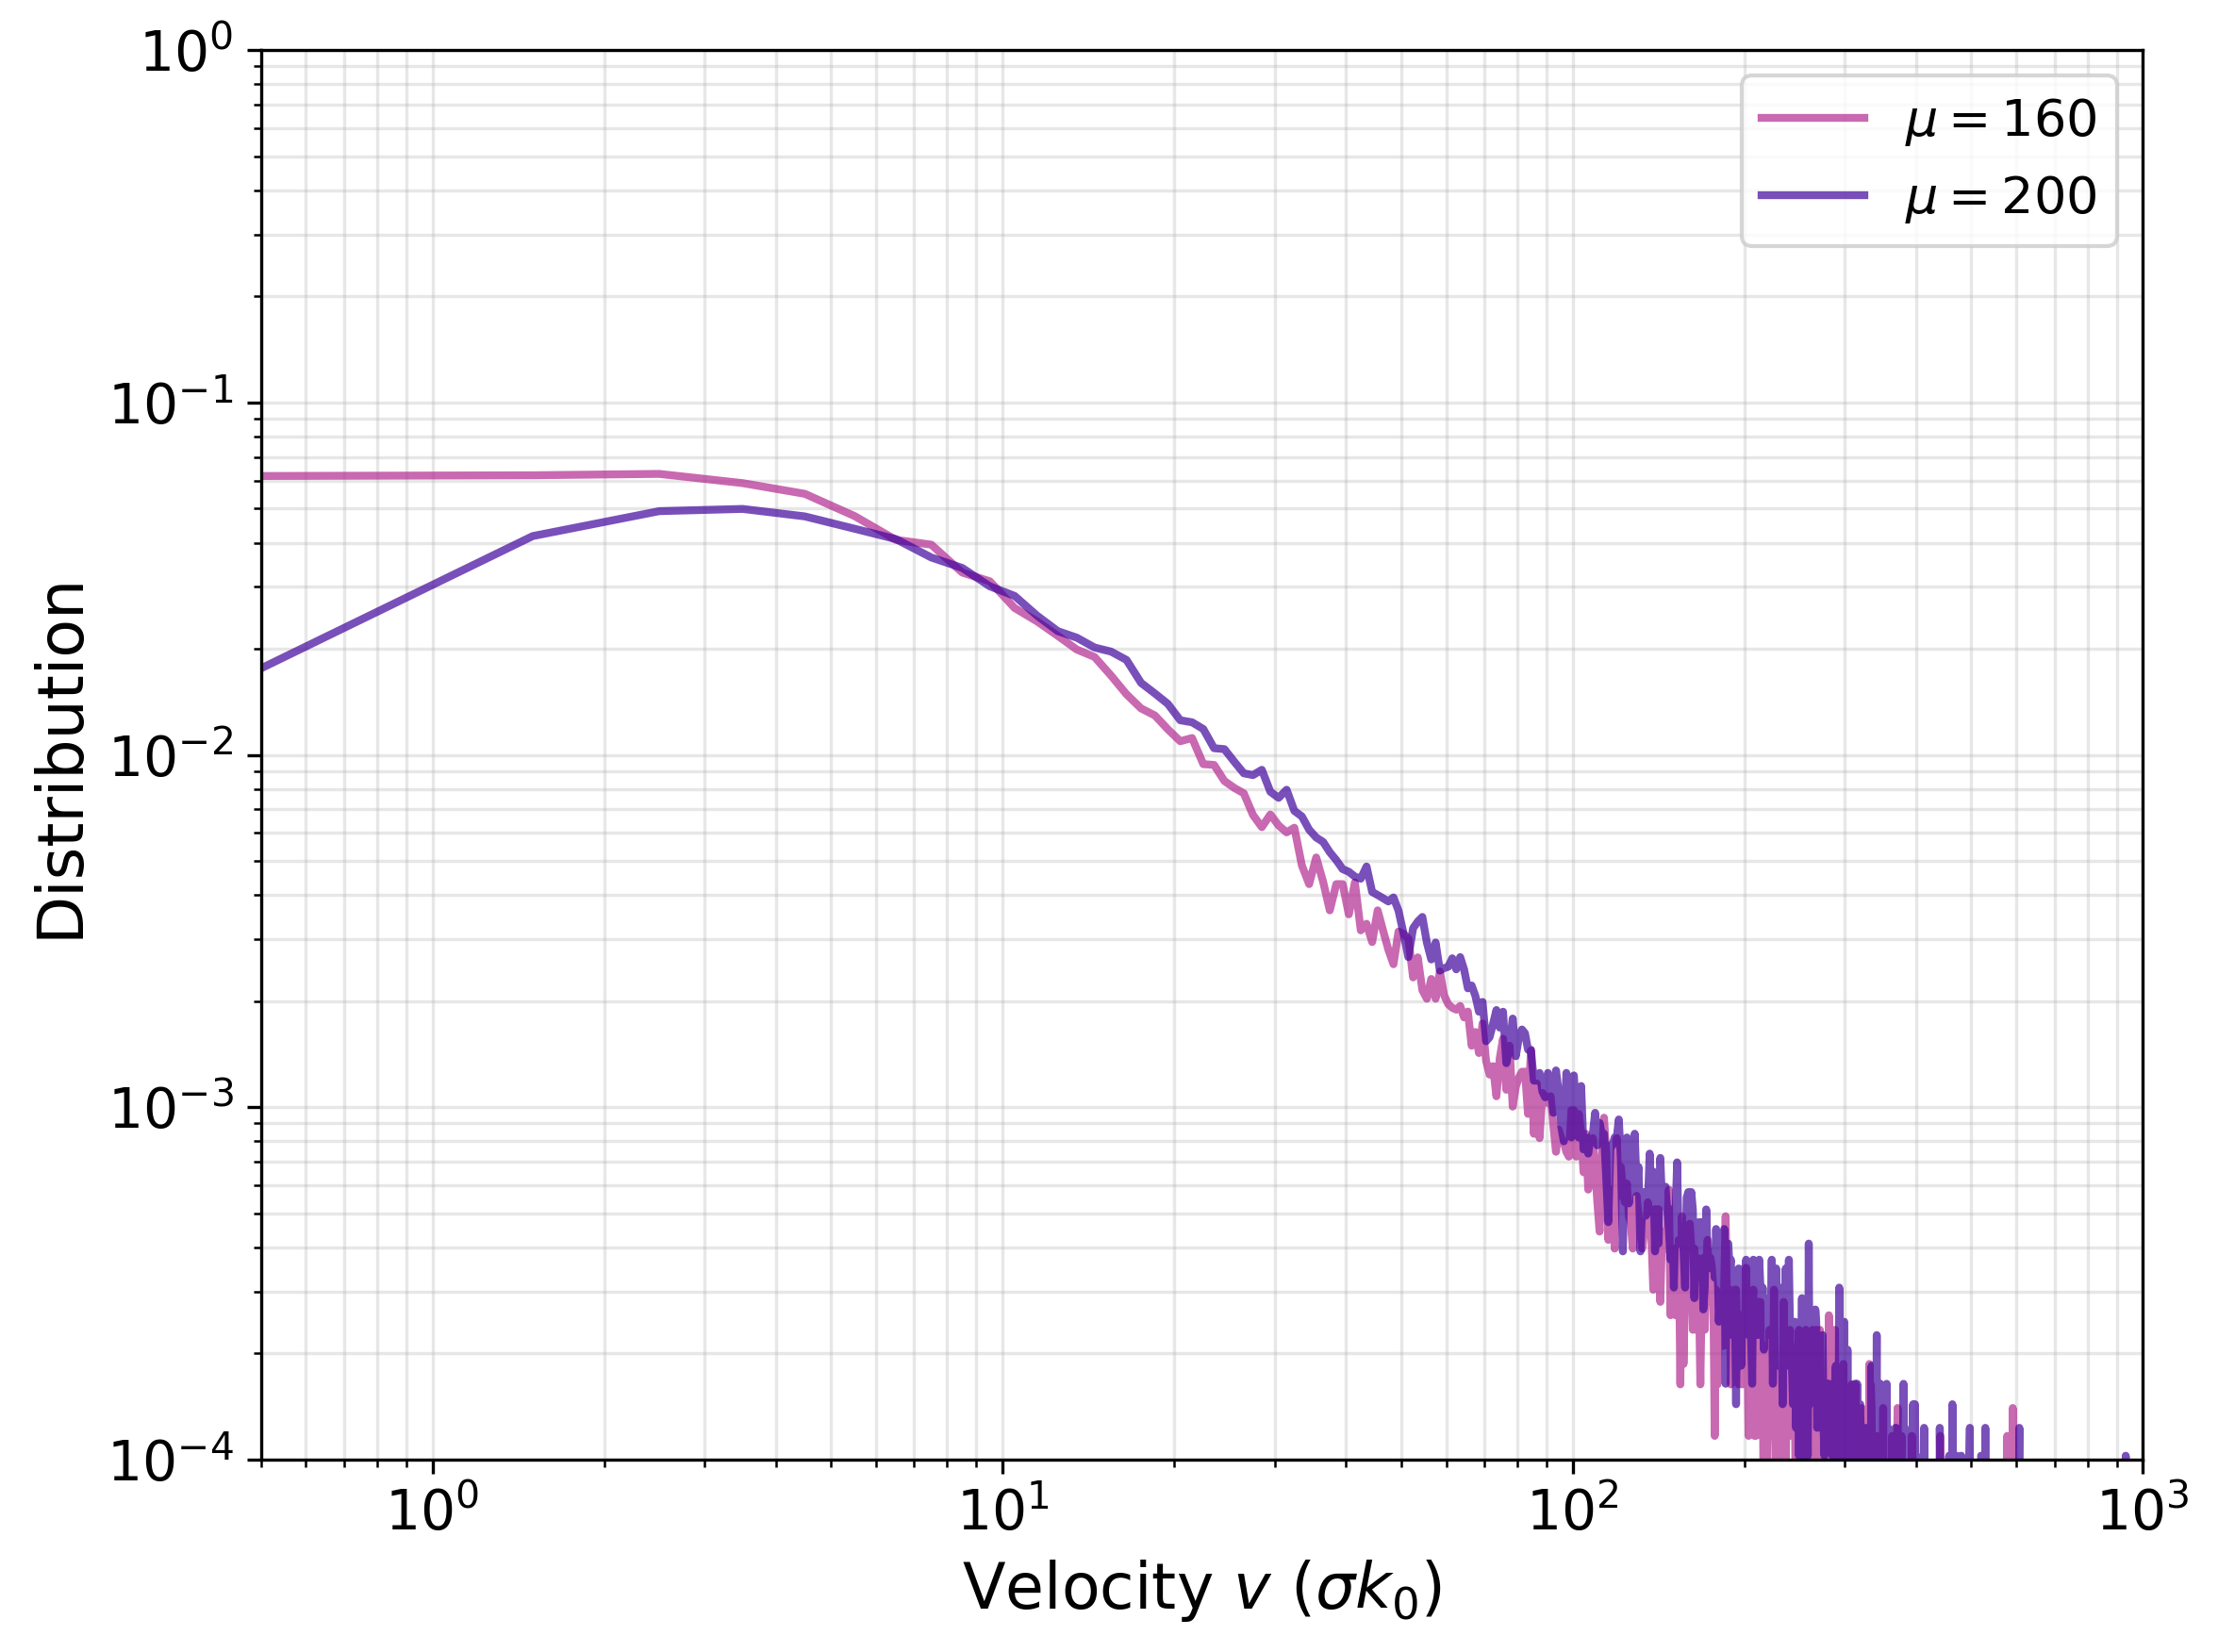

In [19]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# -------------------------------------------------------------------
# Paramètres
# -------------------------------------------------------------------

mus = [160, 200]
thetas = [20, 50, 100]

cmap_C = cm.get_cmap("plasma")
color_positions_C = np.linspace(0.1, 0.4, len(mus))
color_list_C = [cmap_C(pos) for pos in color_positions_C]
color_list_C.reverse()

base_params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "nt": 10_000,
}

# -------------------------------------------------------------------
# Une figure par valeur de theta
# -------------------------------------------------------------------

for theta in thetas:

    print(f"theta = {theta}")

    plt.figure(figsize=(8, 6), dpi=300)

    for i, mu in enumerate(mus):

        params = {
            **base_params,
            "mu": mu,
            "theta": theta,
        }

        df = find_parquet_and_load(**params)

        vi_points = df["vi_points"][0].to_numpy()
        vi_distrib = df["vi_distrib"][0].to_numpy()

        plt.plot(
            vi_points,
            vi_distrib,
            linewidth=2,
            alpha=0.70,
            color=color_list_C[i],
            label=rf"$\mu = {mu}$",
        )

    # ----------------------------------------------------------------
    # Mise en forme
    # ----------------------------------------------------------------

    plt.xlabel(r"Velocity $v$ ($\sigma k_0$)", fontsize=16)
    plt.ylabel("Distribution", fontsize=16)

    plt.xlim([5e-1, 1e3])
    plt.ylim([1e-4, 1e0])

    plt.tick_params(labelsize=14)
    plt.grid(True, alpha=0.3, which="both", linestyle="-")
    plt.legend(fontsize=13)

    plt.loglog()
    plt.tight_layout()
    plt.show()

# .